In [544]:
###IMPORT MODULES/LIBRARIES ###
import os
import warnings

import numpy as np
import math
import pickle

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline
import seaborn as sns
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import AgglomerativeClustering, SpectralClustering, KMeans
from sklearn.model_selection import GridSearchCV
from sklearn import linear_model


import scipy.stats as stats
from scipy.stats import f_oneway, tukey_hsd
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.signal import correlate
from scipy.signal import find_peaks

import scipy.io as sio
from scipy import interpolate
from sklearn.metrics import roc_auc_score as auROC

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
np.set_printoptions(suppress=True)
from tqdm import tqdm #progress bar

import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'notebook'

import tensortools as tt



In [2]:
### SAVE ALIGNED DATA TO DATA FOLDER? ###
### ONLY SAY yes BELOW IF YOU WANT TO OVERWRITE EXISTING FILES!!! ###
alphalevel = 0.05 ### set to preferred alpha for denoting significant responders
bh_correction = 'no' ### set to 'yes' or 'no' if you want to correct pvalues for multiple comparisons when plotting significant or notsignicant neurons

extractedsignalsonly = 'no' ###keep this as no for now, will update below if using the analyze single session function
mineventstoanalyze = 3 ### set to preferred minimum number of events required for data to be analyzed. Otherwise, FOV won't be analyzed

save_aligned_data = 'no' ###'yes' or 'no'
save_auc_array = 'no' ###'yes' or 'no'

delete_overlaps = 'yes'  ### if an event occurs within selected number ms (below) of a previous event, that event is deleted
separation_requirement = 1000 ### Set to 0 if delete_overlaps = 'no'. IN MILLISECONDS SO 1000 = 1 second

### SET THESE YOURSELF ###
frameaveraging = 4 ###cumulative frames averaged per second online and during post-precessing
framerate = 30 ###raw framerate (unaveraged)
timebetweenframes = 33.333333 ###time between each raw frame (unaveraged)
averagedframerate = framerate/frameaveraging 

### Z-score the data?
z_score_data = 'yes'

### PICK THE FRAMES THAT YOU WANT TO BE PLOTTED AND ANALYZED
pre_window_size = int(10*averagedframerate) #How many frames per trial before origin to be plotted?
window_size =  int((pre_window_size*2)+(1.6*averagedframerate)) #How many frames do you want to plot around the origin?
post_window_size = window_size - pre_window_size

baselinefirstframe = 0
baselinelastframe = int(3*averagedframerate)
infusionframe = int(pre_window_size+(1.6*averagedframerate))
aucfirstframe = int(pre_window_size-(3*averagedframerate))
auclastframe = int(pre_window_size+(0*averagedframerate))

### INDICATE EVENT OF INTEREST OUT OF POSSIBILITIES BELOW FOR ANALYSIS ###
### Possible events: activelever, inactivelever, activelevertimeout, inactivelevertimeout, activeleverall, inactiveleverall,
### licks, cues, infusions
eventofinterest = 'activeleverall'

### ASSIGN YOUR FOLDER FOR ANALYSIS
basedir = r'/Users/jmo204/Dropbox/2P Imaging Projects/Jim/PFC Self Admin Analysis July 2024'


In [3]:
### FUNCTIONS FOR EVENT ALIGNMENT. SKIP IF LOADING PAST DATA ###
### THIS IS THE BIGGEST FUNCTION IN THE CODE, WHICH ENABLES IMPORTING OF DATA AND SORTING FOR ANALYSIS IN SUBSEQUENT CELLS ###
def analyze_single_session(indir, window_size, pre_window_size):
    tempfiles = next(os.walk(indir))[2]
    npyfiles = [f for f in tempfiles if os.path.splitext(f)[1]=='.npy' and 'extractedsignals_raw' in f]
    matfiles = [f for f in tempfiles if os.path.splitext(f)[1]=='.mat']
    if len(npyfiles) > 1:
        npyfile = [f for f in tempfiles if os.path.splitext(f)[1]=='.npy' and 'extractedsignals_raw' in f and not 'part2' in f and not 'part3' in f and not 'part4' in f]
        npyfile = npyfile [0]
        matfile = [f for f in tempfiles if os.path.splitext(f)[1]=='.mat' and not 'results' in f and not 'part2' in f and not 'part3' in f and not 'part4' in f]
        matfile = matfile [0]
    else:
        npyfile = npyfiles[0]
        matfile = matfiles[0]

    signals = np.squeeze(np.load(os.path.join(indir, npyfile)))
    numrois = signals.shape[0] 

    behaviordata = sio.loadmat(os.path.join(indir, matfile))
    eventlog = np.squeeze(behaviordata['eventlog'])
    licks = np.squeeze(behaviordata['licks'])
    lastframe_timestamp_part1 = np.max(eventlog)

    ### THIS SECTION COMBINES FILES IF SESSIONS WERE SPLIT. TRY NOT TO LET THIS HAPPEN AND WE CAN GET RID OF THIS! ###
    if len(npyfiles) > 1:
        npyfiles2 = [f for f in tempfiles if os.path.splitext(f)[1]=='.npy' and 'extractedsignals_raw'and 'part2' in f]
        matfiles2 = [f for f in tempfiles if os.path.splitext(f)[1]=='.mat' and 'part2' in f and not 'results' in f]
        npyfile2 = npyfiles2[0]
        matfile2 = matfiles2[0]
        signals2 = np.squeeze(np.load(os.path.join(indir, npyfile2))) 
        signals = np.hstack((signals, signals2))
        behaviordata2 = sio.loadmat(os.path.join(indir, matfile2))
        eventlog2 = np.squeeze(behaviordata2['eventlog'])
        eventlog2[:,1] = eventlog2[:,1]+lastframe_timestamp_part1  #adding the last frame to the second column of data in eventlog
        eventlog = np.concatenate((eventlog,eventlog2))
        lastframe_timestamp_part2 = np.max(eventlog)
        licks2 = np.squeeze(behaviordata2['licks'])
        licks2 = licks2+lastframe_timestamp_part1
        licks = np.concatenate ([licks, licks2])
    if len(npyfiles) > 2:
        npyfiles3 = [f for f in tempfiles if os.path.splitext(f)[1]=='.npy' and 'extractedsignals_raw'and 'part3' in f]
        matfiles3 = [f for f in tempfiles if os.path.splitext(f)[1]=='.mat' and 'part3' in f and not 'results' in f]
        npyfile3 = npyfiles3[0]
        matfile3 = matfiles3[0]
        signals3 = np.squeeze(np.load(os.path.join(indir, npyfile3))) 
        signals = np.hstack((signals, signals3))
        behaviordata3 = sio.loadmat(os.path.join(indir, matfile3))
        eventlog3 = np.squeeze(behaviordata3['eventlog'])
        eventlog3[:,1] = eventlog3[:,1]+lastframe_timestamp_part2  #adding the last frame to the second column of data in eventlog
        eventlog = np.concatenate((eventlog,eventlog3))
        lastframe_timestamp_part3 = np.max(eventlog)
        licks3 = np.squeeze(behaviordata3['licks'])
        licks3 = licks3+lastframe_timestamp_part2
        licks = np.concatenate ([licks, licks3])
    if len(npyfiles) > 3:
        npyfiles4 = [f for f in tempfiles if os.path.splitext(f)[1]=='.npy' and 'extractedsignals_raw' and 'part4' in f]
        matfiles4 = [f for f in tempfiles if os.path.splitext(f)[1]=='.mat' and 'part4' in f and not 'results' in f]
        npyfile4 = npyfiles4[0]
        matfile4 = matfiles4[0]
        signals4 = np.squeeze(np.load(os.path.join(indir, npyfile4))) 
        signals = np.hstack((signals, signals4))
        behaviordata4 = sio.loadmat(os.path.join(indir, matfile4))
        eventlog4 = np.squeeze(behaviordata4['eventlog'])
        eventlog4[:,1] = eventlog4[:,1]+lastframe_timestamp_part3  #adding the last frame to the second column of data in eventlog
        eventlog = np.concatenate((eventlog,eventlog4))
        lastframe_timestamp_part4 = np.max(eventlog)
        licks4 = np.squeeze(behaviordata4['licks'])
        licks4 = licks4+lastframe_timestamp_part3
        licks = np.concatenate ([licks, licks4])
    
    if extractedsignalsonly == 'yes':
        return signals

    ### THIS SECTION DEFINES CERTAIN INPUTS IN MATLAB EVENTLOG AS BEHAVIORAL STIMULI (LEVER PRESS, CUE, ETC) ###
    activelever = eventlog[eventlog[:,0]==22,1]
    activelevertimeout = eventlog[eventlog[:,0]==222,1]
    inactivelever = eventlog[eventlog[:,0]==21,1]
    inactivelevertimeout = eventlog[eventlog[:,0]==212,1]
    cues = eventlog[eventlog[:,0]==7,1]
    infusions = eventlog[eventlog[:,0]==4,1]
    
    if isinstance(window_size, str): 
        return activelever, activelevertimeout
    
    ### THIS SECTION DELETES OVERLAPPING PRESSES (ACTIVE AND ACTIVE DURING TIMEOUT) IF THOSE PRESSES OCCURED WITH X 
    ### NUMBER OF MILLISECONDS FROM A PREVIOUSLY MONITORED EVENT (DEFINED IN PREVIOUS CELL)
    ### ADDITIONALLY, THIS SECTION COMBINES ACTIVE AND ACTIVE DURING TIMEOUT, REGARLESS OF WHETHER OVERLAPS ARE DELETED
    if delete_overlaps == 'yes':
        if 'active' in eventofinterest:
            newarray = np.array([])
            temp = np.sort(np.hstack((activelever, activelevertimeout)))
            temp = np.delete(temp, np.argwhere(np.ediff1d(temp)<separation_requirement)+1)
            if eventofinterest == 'activelever':
                for i in range(len(temp)):
                    if temp[i] in activelever:
                        newarray = np.append(newarray, temp[i])
                activelever = newarray    
            if eventofinterest == 'activelevertimeout':
                for i in range(len(temp)):
                    if temp[i] in activelevertimeout:
                        newarray = np.append(newarray, temp[i])
                activelevertimeout = newarray
            if eventofinterest == 'activeleverall':
                activeleverall = temp
        elif 'inactive' in eventofinterest:
            newarray = np.array([])
            temp = np.sort(np.hstack((inactivelever, inactivelevertimeout)))
            temp = np.delete(temp, np.argwhere(np.ediff1d(temp)<separation_requirement)+1)
            if eventofinterest == 'inactivelever':
                for i in range(len(temp)):
                    if temp[i] in inactivelever:
                        newarray = np.append(newarray, temp[i])
                inactivelever = newarray    
            if eventofinterest == 'inactivelevertimeout':
                for i in range(len(temp)):
                    if temp[i] in inactivelevertimeout:
                        newarray = np.append(newarray, temp[i])
                inactivelevertimeout = newarray
            if eventofinterest == 'inactiveleverall':
                inactiveleverall = temp 
    else:
        activeleverall = np.sort(np.hstack((activelever, activelevertimeout))) ### np.sort integrates them in array rather than keeping separated
        inactiveleverall = np.sort(np.hstack((inactivelever, inactivelevertimeout))) ### np.sort integrates them in array rather than keeping separated

    ### PICKS EVENT TO ANALYZE BASED ON CELL ABOVE ###
    if eventofinterest == 'activelever':
        events = activelever
    elif eventofinterest == 'activelevertimeout':
        events = activelevertimeout
    elif eventofinterest == 'inactivelever':
        events = inactivelever
    elif eventofinterest == 'inactivelevertimeout':
        events = inactivelevertimeout
    elif eventofinterest == 'cues':
        events = cues
    elif eventofinterest == 'infusions':
        events = infusions
    elif eventofinterest == 'activeleverall':
        events = activeleverall
    elif eventofinterest == 'inactiveleverall':
        events = inactiveleverall

    ### DOES NOT ANALYZE ANIMAL IF LESS THAN 2 EVENTS TO PREVENT ERROR IN BELOW CODE###
    if len(events) < 2:
        return np.nan*np.ones((2, window_size)), np.nan*np.ones((2, window_size)), np.nan*np.ones((2, window_size)), np.nan*np.ones((2, window_size))

    ### IF YOUR CODE LACKS FRAME INPUTS, WE CAN ATTEMPT TO PREDICT FRAME TIMING USING PREVIOUS FRAME TIMESTAMPS ###
    if animal == 'CTL1' or animal == 'ER-L1' or animal == 'ER-L2' or animal == 'IG-19' or animal == 'IG-28' or animal == 'PGa-T1' or animal == 'XYZ':
        frame_timestamps = np.array(assumed_frame_timestamps) ###Fixes issue for finding behavior IF YOU DON"T HAVE FRAME INFO
    else:
        frame_timestamps = fix_any_dropped_frames(eventlog[eventlog[:,0]==9,1]) ### Fixes dropped frames for data that has timestamps, using function below

    frame_timestamps = frame_timestamps[::frameaveraging] ###incorporates averaging into timestamp array

    ### DISCARDS PORTIONS OF FLUROESCENT SIGNALS THAT WERE WAS COVERED BY FRAMETIMESTAMPS, IF SIGNALS > TIMESTAMPS ###
    if signals.shape[1] > frame_timestamps.shape[0]:
        signals = signals[:,:frame_timestamps.shape[0]-1] ###cuts signals so it's not longer than the frame timestamps

    ### DISCARDS BEHAVIORAL EVENTS THAT WERE NOT FULLY MONITORED WITH IMAGING ###
    final_frame_timestamp = frame_timestamps[signals.shape[1]] #Timestamp of the final fluorescent signal measurement in ms
    seconds_monitored = int(signals.shape[1]/averagedframerate) ###seconds monitored by 2p imaging
    seconds_behavior = int(max(events/1000)) ###final seconds to be monitored for behavior

    signals /= np.nanmean(signals, axis=1)[:, None] ###averages signals around 1, rather than pixel intensity
    
    if z_score_data == 'yes':
        for neuron in range(signals.shape[0]):
            mean = np.nanmean(signals[neuron])
            std = np.nanstd(signals[neuron])
            signals[neuron] = (signals[neuron] - mean)/std
    
    signalsT = signals.T ###transposes signals so that the shape is easy to use with frame timestamps
    
    
    ### DOES NOT ANALYZE ANIMAL IF LESS THAN THE NUMBER OF EVENTS INDICATED BELOW ###
    if len(events) < mineventstoanalyze:
        return np.nan*np.ones((2, window_size)), np.nan*np.ones((2, window_size)), np.nan*np.ones((2, window_size)), np.nan*np.ones((2, window_size))

    ### THIS FUNCTION IS EMBEDDED WITHIN THE ANALYZE SINGLE SESSION FUNCTION ###
    ### IT USES THE FLUORESCENT SIGNALS ("signals2") AND FIRST FRAME TIMESTAMP AFTER EVENT TO ORGANIZE RESPONSES ACROSS EVENTS ###
    ### DATA IS EXPORTED AS 3D (ALL EVENTS) AND 2D (COLLAPSED ACROSS TRIALS)

    def calculate_aligneddata_forevent(signalsT2, events2):
        framenumberfor_eventofinterest = np.squeeze(framenumberforevent(events2, frame_timestamps)) ### Uses "framenumberforevent" function below

        numtrials = framenumberfor_eventofinterest.shape[0]
        alignedevents = np.NAN*np.zeros([numtrials,window_size,numrois])

        for i in np.flip(range(numtrials)):
            eventindex = framenumberfor_eventofinterest[i]

            if np.isfinite(eventindex) and eventindex > pre_window_size and eventindex < np.shape(signalsT2)[0]-post_window_size:
                eventindex = int(eventindex)
                alignedevents[i, :, :] = signalsT2[eventindex-pre_window_size:eventindex+post_window_size, :]
            else:
                alignedevents = np.delete(alignedevents, i, axis = 0)

        return alignedevents

    alignedevents = calculate_aligneddata_forevent(signalsT, events) 

    ### FINDS ROIS WITH NANS IN DATASET AND REPORTS TO USER TO FIX THAT ERROR ###
    for i in range(signals.shape[0]):
        if np.isnan(np.mean(signals[i,:])):
            print(animal, fov, 'IMAGE J ROI.ZIP CELL NUMBER %s HAS NaNs AND SHOULD BE CHANGED'%(i+1))
    
    alignedevents = np.swapaxes(alignedevents, 0,2)
        
    popevents = np.nanmean(alignedevents, axis=2)

    if save_aligned_data == 'yes':
        np.save(os.path.join(indir, 'popevents_%s_%s.npy'%(eventofinterest, separation_requirement)), popevents)
        np.save(os.path.join(indir, 'alignedevents_%s_%s.npy'%(eventofinterest, separation_requirement)), alignedevents)
    return popevents, alignedevents, events, events


### THIS FUNCTION IS ALSO USED BY ANALYZE SINGLE SESSION ###
def framenumberforevent(event, frame_timestamps):
    framenumber = np.nan*np.zeros(event.shape)
    for ie, e in enumerate(event):
        if np.isnan(e):
            framenumber[ie] = np.nan
        else:
            temp = np.nonzero(frame_timestamps<=e)[0]
            if temp.shape[0]>0:
                framenumber[ie] = np.nonzero(frame_timestamps<=e)[0][-1]
            else:
                framenumber[ie] = 0
    return framenumber


In [4]:
if save_aligned_data == 'yes':
    ### FUNCTIONS FOR FIXING FRAMES FOR EVENT ALIGNMENT. SKIP IF LOADING PAST DATA ###
    def fix_any_dropped_frames(frame_timestamps):
        first_frame = np.array([0])
        last_frame = np.array([int(np.max(frame_timestamps)+(500*timebetweenframes))])
        frame_index_temp = np.concatenate((first_frame,frame_timestamps, last_frame)) ###adds frame to timepoint '0' and an extra 500 frames at end
        frames_missed = [] ###creates empty list for us to add timestamps for missed frames
        for i in range(len(frame_index_temp)-1): ###iterates through each collected frame
                numframes_missed = int(np.round((frame_index_temp[i+1]-frame_index_temp[i])\
                    /timebetweenframes)-1) ### number of missed frames per frame interval
                if numframes_missed > 0: 
                    for j in range(numframes_missed):
                        frame_missed = np.array([frame_index_temp[i] + (int(timebetweenframes * (j+1)))])
                        frames_missed = np.concatenate((frames_missed, frame_missed))
        corrected_frame_index = np.array(sorted(np.concatenate((frame_index_temp, frames_missed))))
        return corrected_frame_index

    def fix_assumed_frames(frames):
        dropped_frames = []
        diff_frames = np.diff(frames)
        inter_frame_interval = 33
        frame_drop_idx = np.where(diff_frames>1.5*inter_frame_interval)[0]
        for idx in frame_drop_idx:
            numframesdropped = int(np.round((frames[idx+1]-frames[idx])/(inter_frame_interval+0.0))-1)
            temp = [frames[idx]+a*inter_frame_interval for a in range(1,numframesdropped+1)]
            dropped_frames.extend(temp)


        corrected_frames = np.sort(np.concatenate((frames, np.array(dropped_frames))))
        return corrected_frames

    ###Artifically inserts frames timestamps from prior datasets

    behaviordata_noframes = sio.loadmat\
        (r'/Users/jmo204/Dropbox/2P Imaging Projects/Jim/PFC Self Admin Analysis May 2024/Codes/matfile_noframes_3.mat')
    eventlog_noframes = np.squeeze(behaviordata_noframes['eventlog'])

    max_of_eventlog_noframes = max(eventlog_noframes[:,1])
    length_of_eventlog_noframes = len(eventlog_noframes[:,1])
    x = np.vstack((eventlog_noframes, eventlog_noframes, eventlog_noframes))
    x[length_of_eventlog_noframes:,1]= x[length_of_eventlog_noframes:,1]+max_of_eventlog_noframes
    x[length_of_eventlog_noframes*2:,1]= x[length_of_eventlog_noframes*2:,1]+(2*max_of_eventlog_noframes)

    eventlog_noframes = x

    ###Provides about 4.32 hours worth of frames if 4 frame averaging)
    assumed_frames = fix_any_dropped_frames(eventlog_noframes[eventlog_noframes[:,0]==9,1]) ###Fixes issue for finding behavior IF YOU DON"T HAVE FRAME INFO
    assumed_frame_timestamps = fix_assumed_frames(eventlog_noframes[eventlog_noframes[:,0]==9,1]) ###Fixes issue for finding behavior IF YOU DON"T HAVE FRAME INFO


In [5]:
###OTHER FUNCTIONS
def calculate_auROC(x,y,offset_to_zero=True):
    U, p = stats.mannwhitneyu(x,y)
    labels = np.concatenate((np.ones(x.shape), np.zeros(y.shape)))
    data = np.concatenate((x,y))
    A = auROC(labels, data)
    if offset_to_zero:
        return (2*(A-0.5), p)
    else:
        return (A, p)
    
def Benjamini_Hochberg_correction(vector_of_pvals,
                                  alpha = 0.05):
    # This function implements the BH FDR correction
    
    # Parameters:
    # Vector of p values from the different tests
    # alpha:significance level
    
    # Returns: Corrected p values. All the p values that are above the FDR threshold are set to 1. 
    #          Remaining p values are unchanged.
    
    sortedpvals = np.sort(vector_of_pvals)
    orderofpvals = np.argsort(vector_of_pvals)
    m = sortedpvals[np.isfinite(sortedpvals)].shape[0] #Total number of hypotheses
    for i in range(m):
        if sortedpvals[i] > (i+1)*alpha/m:
            k = i
            break
        elif i == m-1:
            k = m-1
        
    correctedpvals = np.copy(vector_of_pvals)
    correctedpvals[orderofpvals[k:]] = 1
    correctedpvals[np.isnan(vector_of_pvals)] = np.nan
    return correctedpvals

def iterate_dirs(basedir, days):
    for day in sorted(days):
        animals = next(os.walk(os.path.join(basedir, day)))[1]
        for animal in sorted(animals):
            FOVs = next(os.walk(os.path.join(basedir, day, animal)))[1]
            for fov in sorted(FOVs):
                yield basedir, day, animal, fov


In [6]:
### EVENT ALIGNMENT: SAVES AND/OR LOADS ALIGNED FLUORESCENT DATA (2D: ROIS BY TIME) SURROUNDING EVENT ###
### NOTE: NEW DATA WILL BE SAVED IN YOUR FILE FOLDERS IF save_aligned_data == 'yes'!!!

### SELECTS ALL DAYS WITHIN A DIRECTORY ###
tempdays = next(os.walk(os.path.join(basedir)))[1]
days = []
for t in tempdays:
    if t!= 'Cascade' and t!= 'CellTracking' and t!= 'Codes' and t != '.ipynb_checkpoints' and t != 'Other' and t!= 'Results':
        days = np.append(days, t)
numdays = len(days)

###DICTIONARIES FOR ALL DATA FOR ALL DAYS AND FOVS###
popevents_day = {} # Dictionary for all popevents data for all days
popevents_fov = {} # Dictionary for all popevents data for all fovs

for basedir, day, animal, fov in iterate_dirs(basedir, sorted(days)):
    if day not in popevents_fov:
        popevents_day[day] = np.nan*np.ones((1, window_size))
        popevents_fov[day] = {}
        print(day)   
    if save_aligned_data == 'yes':
        temp1, temp2, temp3, temp4 = analyze_single_session(os.path.join(basedir, day, animal, fov), window_size, pre_window_size)
    tempfiles = next(os.walk(os.path.join(basedir, day, animal, fov)))[2]
    if 'popevents_%s_%s.npy'%(eventofinterest, separation_requirement) in tempfiles: 
        if animal not in popevents_fov[day]:
            popevents_fov[day][animal] = {}
        temp1 = np.load(os.path.join(basedir, day, animal, fov, 'popevents_%s_%s.npy'%(eventofinterest, separation_requirement)))  
        if np.isfinite(np.nanmean(temp1)):
            popevents_day[day] = np.vstack((popevents_day[day], temp1))
            popevents_fov[day][animal][fov] = temp1
            baseline = np.mean(popevents_fov[day][animal][fov][:, baselinefirstframe:baselinelastframe], axis=1)
            popevents_fov[day][animal][fov] = popevents_fov[day][animal][fov] - baseline[:, None]
for day in sorted(days):
    popevents_day[day] = popevents_day[day][1:,:]  # Remove the first row of NaNs
    baseline = np.mean(popevents_day[day][:, baselinefirstframe:baselinelastframe], axis=1)
    popevents_day[day] = popevents_day[day] - baseline[:, None]
    if save_aligned_data == 'yes':
        np.save(os.path.join(basedir, day, 'popevents_%s_%s.npy'%(eventofinterest, separation_requirement)), popevents_day[day])
popevents_all = np.vstack([popevents_day[day] for day in sorted(days)])
if save_aligned_data == 'yes':
    np.save(os.path.join(basedir, 'Results', 'popevents_%s_%s.npy'%(eventofinterest, separation_requirement)), popevents_all)



0 EarlyAcq
1 MidAcq
2 LateAcq
3 EarlyExt
4 LastExt
5 CueRein
6 DrugRein
7 TMTRein


In [7]:
### TO FIND SIGNIFICANTLY RESPONDING NEURONS, FIRST CALCULATE OR LOAD EXISTING AUC SCORES AND ASSOCIATED PVALUES ###
### NOTE: NEW DATA WILL BE SAVED IN YOUR FILE FOLDERS IF save_auc_array == 'yes'!!!

###DICTIONARIES FOR ALL DATA FOR ALL DAYS AND FOVS###
aucpvals_day = {} # Dictionary for all popevents data for all days
aucpvals_fov = {} # Dictionary for all popevents data for all fovs

if save_auc_array == 'yes':
    for basedir, day, animal, fov in iterate_dirs(basedir, sorted(days)):
        tempfiles = next(os.walk(os.path.join(basedir, day, animal, fov)))[2]
        if 'alignedevents_%s_%s.npy'%(eventofinterest, separation_requirement) in tempfiles: 
            temp2 = np.load(os.path.join(basedir, day, animal, fov, 'alignedevents_%s_%s.npy'%(eventofinterest, separation_requirement)))
            if np.isfinite(np.nanmean(temp2)):
                aucpvals_fov_temp = np.nan*np.ones((temp2.shape[0], 2))
                baseline = np.mean(temp2[:,baselinefirstframe:baselinelastframe, :], axis=1)
                alignedevents = temp2 - baseline[:,None,:]
                newbaseline = np.mean(alignedevents[:,baselinefirstframe:baselinelastframe, :], axis=1)
                event = np.mean(alignedevents[:,aucfirstframe:auclastframe, :], axis=1)
                for neuron in range(np.shape(temp2)[0]):
                    auc, pval = calculate_auROC(event[neuron,:], newbaseline[neuron,:])
                    aucpvals_fov_temp[neuron,0] = auc
                    aucpvals_fov_temp[neuron,1] = pval
                np.save(os.path.join(basedir, day, animal, fov, 'aucpvals_%s_%s.npy'%(eventofinterest, separation_requirement)), aucpvals_fov_temp)

for basedir, day, animal, fov in iterate_dirs(basedir, sorted(days)):
    if day not in aucpvals_fov:
        aucpvals_day[day] = np.nan*np.ones((1, 2))
        aucpvals_fov[day] = {}
        print(day)
    tempfiles = next(os.walk(os.path.join(basedir, day, animal, fov)))[2]
    if 'alignedevents_%s_%s.npy'%(eventofinterest, separation_requirement) in tempfiles: 
        if animal not in aucpvals_fov[day]:
            aucpvals_fov[day][animal] = {}
        aucpvals_fov[day][animal][fov] = np.load(os.path.join(basedir, day, animal, fov, 'aucpvals_%s_%s.npy'%(eventofinterest, separation_requirement)))
        aucpvals_day[day] = np.vstack((aucpvals_day[day], aucpvals_fov[day][animal][fov]))

# for day in sorted(days):
#     aucpvals_day[day] = aucpvals_day[day][1:, :]  # Remove the first row of NaNs
#     if save_auc_array == 'yes':
#         np.save(os.path.join(basedir, day, 'aucpvals_%s_%s.npy'%(eventofinterest, separation_requirement)), aucpvals_day[day])

aucpvals_all = np.vstack([aucpvals_day[day] for day in sorted(days)])
# np.save(os.path.join(basedir, 'Results', 'aucpvals_%s_%s.npy'%(eventofinterest, separation_requirement)), aucpvals_all)

        

0 EarlyAcq
1 MidAcq
2 LateAcq
3 EarlyExt
4 LastExt
5 CueRein
6 DrugRein
7 TMTRein


In [8]:
### CREATE HEATMAP AND POLYLINE FOR EACH DAY ###
### PLOT ALL NEURONS, SIGNIFICANT NEURONS, OR NON SIGNIFICANT NEURONS USING LINES JUST BELOW ###

neuronstoplot = 'all' ### set to 'all', 'significant', or 'notsignificant'
plot_zscored_popevents = 'yes' ### Yes to z-score popevent responses for plotting

### FIGURE SETTINGS ###
if numdays > 1:
    fig, axs = plt.subplots(2, numdays, figsize=(15, 8))

else: 
    fig, axs = plt.subplots(2, 2, figsize=(5, 8))
    
sns.set_style('white')

cmax = 4
cmin = -cmax
ymax = 4
ymin = -ymax

### CREATE FIGURE ###
for d, day in enumerate(sorted(days)):
    if bh_correction == 'yes':
        aucpvals_day[day][:,1] = Benjamini_Hochberg_correction(aucpvals_day[day][:,1])
    if neuronstoplot == 'all':
        temp = np.array(popevents_day[day])
    elif neuronstoplot == 'significant':
        temp = popevents_day[day][np.where(aucpvals_day[day][:,1] <= alphalevel)[0],:] 
    elif neuronstoplot == 'notsignificant':
        temp = popevents_day[day][np.where(aucpvals_day[day][:,1] > alphalevel)[0],:]  
    if plot_zscored_popevents == 'yes':
        for neuron in range(temp.shape[0]):
            neuron_std = np.nanstd(temp[neuron, baselinefirstframe:baselinelastframe])
            temp[neuron, :] = temp[neuron, :]/neuron_std
        if d == 0:
            print('data z-scored')
            
    tempresponse = np.nanmean(temp, axis=1)
    sortresponse = np.argsort(tempresponse)[::-1]
    numneurons_temp = len(sortresponse)

    ax = axs[0, d]
    
#     sns.heatmap(temp[sortresponse,:], ax=ax, vmax = cmax, vmin = cmin, linewidth=0, cmap=plt.get_cmap('PRGn_r'),
#                cbar_kws={'label': '$\Delta$F/F'})
    im = ax.imshow(temp[sortresponse], cmap=plt.get_cmap('PRGn_r'), vmin=cmin, vmax=cmax, aspect='auto')
    
    ax.grid(False)
    ax.set_ylabel('%s neurons'%numneurons_temp)
    ax.set_yticks([])
    ax.set_xticks([])
    ax.plot([pre_window_size, pre_window_size], 
            [0, numneurons_temp], '--k', linewidth=1.5)
    ax.plot([infusionframe, infusionframe],
            [0, numneurons_temp], '--k', linewidth=1.5) 

    ax = axs[1, d]
    ax.set_xticks([])
    ax.plot(np.mean(temp, axis = 0))
    ax.plot([pre_window_size, pre_window_size],
             [-0.5,2.5],'--k', linewidth=1.5)
#     ax.plot([infusionframe, infusionframe],
#             [-0.5,0.5], '--k', linewidth=1.5) 
    ax.plot([0, window_size],
            [0,0], '--k', linewidth=0.5)

fig.tight_layout()

# if plot_zscored_popevents == 'no':
#     fig.savefig(os.path.join(basedir, 'Results', 'Population_HeatMaps_%s.PDF'%neuronstoplot), format='PDF') ### May be large. Comment out if testing code. Uncomment to save final Figure
#     fig.savefig(os.path.join(basedir, 'Results', 'Population_HeatMaps_%s.PNG'%neuronstoplot), format='PNG') ### Smaller File. Great for testing code.
# if plot_zscored_popevents == 'yes':
#     fig.savefig(os.path.join(basedir, 'Results', 'Population_HeatMaps_zscored_%s.PDF'%neuronstoplot), format='PDF') ### May be large. Comment out if testing code. Uncomment to save final Figure
#     fig.savefig(os.path.join(basedir, 'Results', 'Population_HeatMaps_zscored_%s.PNG'%neuronstoplot), format='PNG') ### Smaller File. Great for testing code.

plt.close() ### Prevents plot from showing up in Python (prevents slowing of code). Alternatively, use plt.show() to display figure

print('DONE')


data z-scored
DONE


In [9]:
### PLOT % OF SIGNIFICANT NEURONS ###
### CREATE HEATMAP AND POLYLINE FOR EACH DAY ###
### PLOT ALL NEURONS, SIGNIFICANT NEURONS, OR NON SIGNIFICANT NEURONS USING LINES JUST BELOW ###

### FIGURE SETTINGS ###
fig, axs = plt.subplots(numdays, figsize=(4, 15), sharex=True, sharey=False)

sns.set_style('white')
colors = ['purple', 'gray', 'green']

numneurons_day = {}

# ### CREATE FIGURE ###
for d, day in enumerate(sorted(days)):
    numneurons_day[day] = np.shape(aucpvals_day[day] )[0]
    if numneurons_day[day] > 0:
        activatedneurons = np.count_nonzero((aucpvals_day[day] [:,1]<=alphalevel) & (aucpvals_day[day] [:,0]>=0))/numneurons_day[day]
        inhibitedneurons = np.count_nonzero((aucpvals_day[day] [:,1]<=alphalevel) & (aucpvals_day[day] [:,0]<0))/numneurons_day[day]
        nonresponders = np.count_nonzero(aucpvals_day[day] [:,1]>alphalevel)/numneurons_day[day] 
    
        counts = np.array([activatedneurons, nonresponders, inhibitedneurons])
        labels = (int(activatedneurons*1000)/10, '', int(inhibitedneurons*1000)/10) #goofy calculations to plot % in each group
    else:
        counts = np.array([0, 1, 0])
        labels = ('no data','','')
        
    ax = axs[d]
    ax.pie(counts, colors=colors, labels=labels)
    ax.set_title(day)
    fig.tight_layout()

numneurons_all = sum(numneurons_day.values())

# fig.savefig(os.path.join(basedir, 'Results', 'Population_PieCharts.PNG'), format='PNG')
# fig.savefig(os.path.join(basedir, 'Results', 'Population_PieCharts.PDF'), format='PDF')

plt.close()

In [10]:
# This allows you to properly index later in the code
cell_mapping = {}
cellcounterall = 0  # Initialize cellcounterall

### Create cell_mapping dictionary
for basedir, day, animal, fov in iterate_dirs(basedir, days):  
    tempfiles = next(os.walk(os.path.join(basedir, day, animal, fov)))[2]
    if 'popevents_%s_%s.npy' % (eventofinterest, separation_requirement) in tempfiles: 
        temp1 = np.load(os.path.join(basedir, day, animal, fov, 'popevents_%s_%s.npy' % (eventofinterest, separation_requirement)))  
        numneurons_temp = temp1.shape[0]
        for neuron in range(numneurons_temp):
            cell_mapping[(day, animal, fov, neuron)] = cellcounterall + neuron
        cellcounterall += numneurons_temp  # Update cellcounterall

### Create keys_day and idxs_day dictionary enabling rapid extraction of data from any day
keys_day = {}
idxs_day = {}

for d, day in enumerate(sorted(days)):
    keys_day[day] = [key for key in cell_mapping.keys() if key[0] == day]
    idxs_day[day] = [value for key, value in cell_mapping.items() if key[0] == day]

# Count the number of unique values in cell_mapping
unique_values = len(set(cell_mapping.values()))
print(f"Number of neuron values in cell_mapping: {unique_values}")



Number of neuron values in cell_mapping: 16858


# CLUSTERING: ONLY USE THIS SECTION IF YOU WANT TO REDO CLUSTERING!

In [12]:
### This function enables you to apply defined operators (based on auROC and pvalue significance) to clustering analysis.
def create_condition(aucpvals_day, auROC_op, pval_op):
    if auROC_op == '>' and pval_op == 'significant':
        return np.logical_and(aucpvals_day[:,1] <= alphalevel, aucpvals_day[:,0] >= 0)
    elif auROC_op == '<' and pval_op == 'significant':
        return np.logical_and(aucpvals_day[:,1] <= alphalevel, aucpvals_day[:,0] < 0)
    elif auROC_op == 'all' and pval_op == 'significant':
        return aucpvals_day[:,1] <= alphalevel
    elif auROC_op == '>' and pval_op == 'notsignificant':
        return np.logical_and(aucpvals_day[:,1] > alphalevel, aucpvals_day[:,0] >= 0)
    elif auROC_op == '<' and pval_op == 'notsignificant':
        return np.logical_and(aucpvals_day[:,1] > alphalevel, aucpvals_day[:,0] < 0)
    elif auROC_op == 'all' and pval_op == 'notsignificant':
        return aucpvals_day[:,1] > alphalevel
    elif auROC_op == '>' and pval_op == 'all':
        return aucpvals_day[:,0] >= 0
    elif auROC_op == '<' and pval_op == 'all':
        return aucpvals_day[:,0] < 0
    elif auROC_op == 'all' and pval_op == 'all':
        return np.ones_like(aucpvals_day[:,0], dtype=bool)

### This array is set to all zeros, and then each clustering analysis will index cluster labels into the array. 
### Protected by 'globals' function to prevent overwriting when doing multiple clustering analyses (you don't have to run this cell more than once)
### If you need to overwrite the array, just add random letters to 'clusterids_all' and rerun cell. 
if 'clusterids_all' not in globals():
    clusterids_all = np.zeros((numneurons_all))


In [13]:
### WHAT DATA DO YOU WANT TO USE FOR CLUSTERING, BASED ON AUROC VALUE? + RESPONDERS, - RESPONDERS, OR ALL? ###
### WHAT DATA DO YOU WANT TO USE FOR CLUSTERING, BASED ON AUROC P-VALUE? SIGNIFICANT, NOT SIGNIFICANT, OR ALL? ###
auROC_operator = '>'  # 'all', ">", or "<"
pval_operator = 'significant' #'significant', 'notsignificant', or 'all'


In [14]:
### Select data for clustering based on operators above ###
condition = create_condition(aucpvals_all, auROC_operator, pval_operator)
popevents_forclustering = popevents_all[np.where(condition)]
numneurons_forclustering = np.shape(popevents_forclustechring)[0]
print(np.shape(popevents_forclustering), 'popevents_forclustering array size')


In [ ]:
### NORMALIZE RESPONSE AMPLITUDES ACROSS NEURONS TO 1?
# Calculate the maximum absolute value for each neuron
max_abs_values = np.max(np.abs(popevents_forclustering), axis=1, keepdims=True)

# Normalize each neuron's response
popevents_forclustering = popevents_forclustering / max_abs_values
print(popevents_forclustering.shape, 'popevents_forclustering array normalized')
    

In [ ]:
## CUT THE LENGTH OF IMAGING WINDOW (WINDOW SIZE) FOR CLUSTERING? ###
preseconds = 10 ###seconds before event to cluster
postseconds = 11.6 ###seconds after event to cluster
popevents_forclustering = popevents_forclustering[:, pre_window_size - int(averagedframerate*preseconds): pre_window_size + int(averagedframerate *postseconds)]
print (popevents_forclustering.shape, 'popevents_forclustering array size after cutting frames')


In [ ]:
### AVERAGE FRAMES FOR CLUSTERING? ###
cluster_frameaveraging = 1 ### MUST BE USABLE TO DIVIDE BY FRAME LENGTH DENOTED ABOVE FOR CLUSTERING. SET TO 1 AND RUN IF YOU DON'T WANT TO AVERAGE
temp = popevents_forclustering.reshape(popevents_forclustering.shape[0], popevents_forclustering.shape[1] // cluster_frameaveraging, cluster_frameaveraging) 
popevents_forclustering = temp.mean(axis = 2)
print(popevents_forclustering.shape, 'popevents_forclustering array size after frame averaging')

In [ ]:
### PLOT ARRAY FOR CLUSTERING
cmax = 0.5 # Maximum colormap value. 
trial_types = ['Active']

fig, axs = plt.subplots(2,2,figsize=(3*2,3*2), sharex='all', sharey='row')

for t in range(len(trial_types)):
    axs[0,t].set_title(trial_types[t])
    ax = axs[0,t]
    tempresponse = np.nanmean(popevents_forclustering, axis=1)
    sortresponse = np.argsort(tempresponse)[::-1]
    sns.heatmap(popevents_forclustering[sortresponse],
                ax=ax,
                cmap=plt.get_cmap('PRGn_r'),
                vmin=-cmax,
                vmax=cmax)

    ax.axvline(preseconds*averagedframerate/cluster_frameaveraging, linestyle='--', color='k', linewidth=0.5)    
    ax.set_xlabel('Time from Press (frames)')
    
    ax = axs[1,t]
    sns.lineplot(data=np.mean(popevents_forclustering[:, t*window_size:(t+1)*window_size], axis=0), dashes=False,
               ax=ax)
    ax.axvline(preseconds*averagedframerate/cluster_frameaveraging, linestyle='--', color='k', linewidth=0.5)    
    ax.set_xlabel('Time from Press (frames)')
    ax.set_xticks([])
    
axs[0,0].set_ylabel('Neurons')
axs[1,0].set_ylabel('Mean norm. fluor.')


fig.subplots_adjust(right=0.82)

fig.savefig(os.path.join(basedir, 'Results', '%s_%s_HeatmapForClustering, %s_%s.PNG'%(eventofinterest, separation_requirement, auROC_operator, pval_operator)), format='PNG')
fig.savefig(os.path.join(basedir, 'Results', '%s_%s_HeatmapForClustering, %s_%s.PDF'%(eventofinterest, separation_requirement, auROC_operator, pval_operator)), format='PDF')


In [ ]:
### Perform PCA on the data plotted above to reduce demensionality of the dataset before clustering
pca = PCA(n_components=popevents_forclustering.shape[1], whiten=True)
pca.fit(popevents_forclustering) 

with open(os.path.join(basedir, 'Results','pcaresults_%s_%s.pickle'%(auROC_operator, pval_operator)), 'wb') as f:
    pickle.dump(pca, f)
    
transformed_data = pca.transform(popevents_forclustering)

np.save(os.path.join(basedir, 'Results', 'transformed_data._%s_%s.npy'%(auROC_operator, pval_operator)), transformed_data)

pca_vectors = pca.components_
print ('Number of PCs = %d'%(pca_vectors.shape[0]))

x = 100*pca.explained_variance_ratio_
print('Variance Explained by PC\n', x)

### Define number of PCs here using one of the two methods below. Comment out 1 method ###
num_retained_pcs = np.count_nonzero(x>5) ### based on min variance explained. usually ~5 works well

# xprime = x - (x[0] + (x[-1]-x[0])/(x.size-1)*np.arange(x.size)) # or defined as the number at which the scree plot bends.
# num_retained_pcs = np.argmin(xprime) # or defined as the number at which the scree plot bends.

print ('Number of PCs to keep = %d'%(num_retained_pcs))

fig, ax = plt.subplots(figsize=(2,2))
ax.plot(np.arange(pca.explained_variance_ratio_.shape[0]).astype(int)+1, x, 'k')
ax.set_ylabel('Percentage of\nvariance explained')
ax.set_xlabel('PC number')
ax.axvline(num_retained_pcs, linestyle='--', color='k', linewidth=0.5)
ax.set_title('Scree plot')
ax.set_xlim([0,50])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

fig.subplots_adjust(left=0.3)
fig.subplots_adjust(right=0.98)
fig.subplots_adjust(bottom=0.25)
fig.subplots_adjust(top=0.9)

numcols = 3.0
fig, axs = plt.subplots(int(np.ceil(num_retained_pcs/numcols)), int(numcols), sharey='all',
                        figsize=(2*numcols, 2*int(np.ceil(num_retained_pcs/numcols))))
for pc in range(num_retained_pcs):
    ax = axs.flat[pc]
    for k, tempkey in enumerate(trial_types):
        ax.plot(pca_vectors[pc, k*window_size:(k+1)*window_size],
                label='PC %d: %s'%(pc+1, tempkey))
    ax.axvline(preseconds*averagedframerate/cluster_frameaveraging, linestyle='--', color='k', linewidth=0.5)    
    ax.axhline(0, linestyle='--', color='k', linewidth=0.5)

    if pc%numcols:
        ax.yaxis.set_ticks_position('none')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

fig.text(0.5, 0.05, 'Time from Press (s)', horizontalalignment='center', rotation='horizontal')
fig.text(0.02, 0.6, 'PCA weights', verticalalignment='center', rotation='vertical')
fig.tight_layout()
for ax in axs.flat[num_retained_pcs:]:
    ax.set_visible(False)

fig.subplots_adjust(wspace=0.08, hspace=0.08)
fig.subplots_adjust(bottom=0.13)
fig.tight_layout()

# fig.savefig(os.path.join(basedir, 'Results', '%s_%s_PCs_%s_%s.PDF'%(eventofinterest, separation_requirement, auROC_operator, pval_operator)), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', '%s_%s_PCs_%s_%s.PNG'%(eventofinterest, separation_requirement, auROC_operator, pval_operator)), format='PNG')

    

In [ ]:
### Perform clustering based on the maximum number of PCs expected
max_n_clusters = num_retained_pcs + 1 # Maximum number of clusters expected. Almost always ends up being the name number of PCs + 1

possible_n_clusters = np.arange(2, max_n_clusters+1) #This requires a minimum of 2 clusters.
### When the data contain no clusters at all, it will be quite visible when inspecting the two obtained clusters, as the responses of the clusters will be quite similar. 

possible_n_nearest_neighbors = np.arange(int(numneurons_forclustering/5), int((numneurons_forclustering/10)*9), int(numneurons_forclustering/4))
      
silhouette_scores = np.nan*np.ones((possible_n_clusters.size,
                                    possible_n_nearest_neighbors.size))

for n_clustersidx, n_clusters in enumerate(possible_n_clusters):
    for nnidx, nn in enumerate(possible_n_nearest_neighbors):
        model = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', n_neighbors=nn)
        model.fit(transformed_data[:,:num_retained_pcs])
        silhouette_scores[n_clustersidx, nnidx] = silhouette_score(transformed_data[:,:num_retained_pcs],
                                                                   model.labels_,
                                                                   metric='cosine')
        print ('Done with numclusters = %d, num nearest neighbors = %d: score = %.3f'%(n_clusters, nn, silhouette_scores[n_clustersidx, nnidx]))
print ('Done with model fitting')

temp = {}
temp['possible_n_clusters'] = possible_n_clusters
temp['possible_n_nearest_neighbors'] = possible_n_nearest_neighbors
temp['silhouette_scores'] = silhouette_scores
temp['shape'] = 'cluster_nn'

with open(os.path.join(basedir, 'Results', 'silhouette_scores_%s_%s.pickle'%(auROC_operator, pval_operator)), 'wb') as f:
        pickle.dump(temp, f)   
 
    

In [ ]:
### Use clustering results to plot silhouette scores. The higher the sillhouette the better the response "fits" with the cluster
with open(os.path.join(basedir, 'Results', 'silhouette_scores_%s_%s.pickle'%(auROC_operator, pval_operator)), 'rb') as f:
        silhouette_scores = pickle.load(f)
        
# Identify optimal parameters from the above parameter space
temp = np.where(silhouette_scores['silhouette_scores']==np.nanmax(silhouette_scores['silhouette_scores']))
n_clusters = silhouette_scores['possible_n_clusters'][temp[0][0]]
n_nearest_neighbors = silhouette_scores['possible_n_nearest_neighbors'][temp[1][0]]

print (n_clusters, n_nearest_neighbors)

# Redo clustering with these optimal parameters
model = SpectralClustering(n_clusters=n_clusters,
                           affinity='nearest_neighbors',
                           n_neighbors=n_nearest_neighbors)

model.fit(transformed_data[:,:num_retained_pcs])

clusterids_temp = model.labels_
uniqueclusterids_temp = list(set(clusterids_temp))
numclusters_temp = len(uniqueclusterids_temp)

temp = silhouette_score(transformed_data[:,:num_retained_pcs], model.labels_, metric='cosine')

print ('Number of clusters = %d, average silhouette = %.3f'%(numclusters_temp, temp))

# Save this optimal clustering model.
with open(os.path.join(basedir, 'Results', 'clusteringmodel_%s_%s.pickle'%(auROC_operator, pval_operator)), 'wb') as f:
    pickle.dump(model, f)


In [ ]:
def make_silhouette_plot(X, cluster_labels):
        
    fig, ax = plt.subplots(1, 1)
    fig.set_size_inches(4, 4)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1
    ax.set_xlim([-0.4, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax.set_ylim([0, len(X) + (n_clusters + 1) * 10])
    silhouette_avg = silhouette_score(X, cluster_labels, metric='cosine')

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels, metric='cosine')

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = \
            sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        ax.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values, alpha=0.9)

        # Label the silhouette plots with their cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i+1))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax.set_title("The silhouette plot for the various clusters.")
    ax.set_xlabel("The silhouette coefficient values")
    ax.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax.set_yticks([])  # Clear the yaxis labels / ticks
    ax.set_xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
    
#     fig.savefig(os.path.join(basedir, 'Results', 'Silhouettes_%s_%s.PDF'%(auROC_operator, pval_operator)), format='PDF')
#     fig.savefig(os.path.join(basedir, 'Results', 'Silhouettes_%s_%s.PNG'%(auROC_operator, pval_operator)), format='PNG')
      
make_silhouette_plot(transformed_data[:,:num_retained_pcs], clusterids_temp)    


In [ ]:
### this section inserts cluster ids into clusterids_all array, and then plots current clusters ### 
condition = create_condition(aucpvals_all, auROC_operator, pval_operator)

clusterids_all[np.where(condition)] = clusterids_temp + 1 + max(clusterids_all[np.where(~condition)])
numclusters = int(max(clusterids_all))+1

for c in range(numclusters):
    temp = popevents_all[np.where(clusterids_all == c)]
    cluster_ci = 1.96 * np.std(temp, axis=0) / np.sqrt(len(temp)) ### cluster confidence interval
    cluster_mean = np.mean(temp, axis = 0)
    plt.plot(cluster_mean,  label=f'Cluster {c}')
    plt.fill_between(range(len(cluster_mean)), cluster_mean - cluster_ci, cluster_mean + cluster_ci, alpha=0.3)

# Add legend
plt.legend()

# Add vertical dashed line at pre_window_size
plt.axvline(x=pre_window_size, color='k', linestyle='--')

# Add horizontal dashed line at y=0
plt.axhline(y=0, color='k', linestyle='--')

# Set x-axis and y-axis labels 
plt.ylabel(r'$\Delta F/F$', fontsize=12)  # Use LaTeX for delta symbol
plt.xlabel("Seconds")

# Set x-axis ticks to represent seconds from -10 to +11.6
xticks = [0, pre_window_size, window_size]
xlabels = [int(-pre_window_size/averagedframerate), 0, (window_size-pre_window_size)/averagedframerate]
plt.xticks(xticks, labels=xlabels)

plt.show()


# AFTER YOU RUN ALL DESIRED CLUSTERING ANALYSES, USE THE BELOW LINES TO REORDER CLUSTERIDS BASED ON THEIR PEAK RESPONSES, AND THEN SAVE THE CLUSTERING IDS TO YOUR DIRECTORY

In [14]:
### REORDER CLUSTER IDS BASED ON PEAK RESPONSES, AND THEN SAVE THE DATA
# Find the peak response for each cluster, excluding cluster 0 which represents neurons that were not clustered (e.g., not significant neurons)
peak_responses = np.nan*np.ones((numclusters))
for c in range(1, numclusters):
    cluster_mean = np.mean(popevents_all[np.where(clusterids_all == c)], axis=0)
    min_peak, max_peak = min(cluster_mean), max(cluster_mean)
    if max_peak > np.abs(min_peak):
        peak_responses[c] = max_peak
    else:
        peak_responses[c] = min_peak

# Determine the new cluster IDs based on the peak of the cluster mean
sorted_clusters = np.argsort(peak_responses)[::-1]
cluster_mapping = {old_cluster: new_cluster for new_cluster, old_cluster in enumerate(sorted_clusters)}

# Create clusterids_all_renumbered
clusterids_all_renumbered = np.array([cluster_mapping[old_cluster] for old_cluster in clusterids_all])

### save clusterids_all_renumbered
# np.save(os.path.join(basedir, 'Results', 'clusterids_all.npy'), clusterids_all_renumbered)


In [15]:
#replot the data to ensure renumbering worked correctly

for c in range(numclusters):
    temp = popevents_all[np.where(clusterids_all_renumbered == c)]
    cluster_ci = 1.96 * np.std(temp, axis=0) / np.sqrt(len(temp)) ### cluster confidence interval
    cluster_mean = np.mean(temp, axis = 0)
    label = f'Cluster {c}' if c > 0 else 'Unclustered'
    plt.plot(cluster_mean,  label=label)
    plt.fill_between(range(len(cluster_mean)), cluster_mean - cluster_ci, cluster_mean + cluster_ci, alpha=0.3)

# Add legend
plt.legend()

# Add vertical dashed line at pre_window_size
plt.axvline(x=pre_window_size, color='k', linestyle='--')

# Add horizontal dashed line at y=0
plt.axhline(y=0, color='k', linestyle='--')

# Set x-axis and y-axis labels 
plt.ylabel(r'$\Delta F/F$', fontsize=12)  # Use LaTeX for delta symbol
plt.xlabel("Seconds")

# Set x-axis ticks to represent seconds from -10 to +11.6
xticks = [0, pre_window_size, window_size]
xlabels = [int(-pre_window_size/averagedframerate), 0, (window_size-pre_window_size)/averagedframerate]
plt.xticks(xticks, labels=xlabels)

# plt.savefig(os.path.join(basedir, 'Results', 'ClusteringResults.PDF'), format='PDF')
# plt.savefig(os.path.join(basedir, 'Results', 'ClusteringResults.PNG'), format='PNG')

plt.show()


# TO PLOT PREVIOUSLY CLUSTERED DATA, CONTINUE HERE (DON'T RUN CLUSTERING ABOVE)

In [11]:
### LOAD REQUIRED DATA
popevents_all = np.load(os.path.join(basedir, 'Results', 'popevents_%s_%s.npy'%(eventofinterest, separation_requirement))) ### 2D array (neurons x window_size) of all neuronal responses across all days
aucpvals_all = np.load(os.path.join(basedir, 'Results', 'aucpvals_%s_%s.npy'%(eventofinterest, separation_requirement))) ### 2D array of auROC and associated pval (neurons x 2), neurons in same order as popevents
clusterids_all = np.load(os.path.join(basedir, 'Results', 'clusterids_all.npy')) ### 1D array of cluster ids, neurons in same order as popevents
numclusters = int(max(clusterids_all))+1

print('shape of popactive %s, aucpvals %s, and clusterids %s'%(popevents_all.shape, aucpvals_all.shape, clusterids_all.shape))

# Find peak response of each cluster for subsequent graphing
peak_responses = np.nan*np.ones((numclusters))
for c in range(1, numclusters):
    cluster_mean = np.mean(popevents_all[np.where(clusterids_all == c)], axis=0)
    min_peak, max_peak = min(cluster_mean), max(cluster_mean)
    if max_peak > np.abs(min_peak):
        peak_responses[c] = max_peak
    else:
        peak_responses[c] = min_peak

# Define response direction of each cluster for future separation
cluster_response_patterns = {
    0: ([0], 'unclustered'),
    1: (np.where(peak_responses > 0)[0], 'excited'),
    2: (np.where(peak_responses < 0)[0], 'inhibited')}

# Define colors for each cluster
cluster_colors = []
for c in range(1, numclusters):
    if c <= 4:
        color = mcolors.to_hex(plt.cm.Purples(1-(c-1)/6))
    else:
        color = mcolors.to_hex(plt.cm.Greens(0.5+(c-5)/6))
    cluster_colors.append(color)
cluster_colors.insert(0, 'black')

# Create a dictionary for each day that includes cluster ids
clusterids_day = {}
for d, day in enumerate(sorted(days)):
    clusterids_day[day] = []
    for neuron_key in keys_day[day]:
        cell_number = cell_mapping[(neuron_key)]
        clusterids_day[day] = np.append(clusterids_day[day], clusterids_all[cell_number])

# Create a dictionary for each fov that includes cluster ids
clusterids_fov = {}
for basedir, day, animal, fov in iterate_dirs(basedir, sorted(days)):
    tempfiles = next(os.walk(os.path.join(basedir, day, animal, fov)))[2]
    if 'popevents_%s_%s.npy'%(eventofinterest, separation_requirement) in tempfiles: 
        if day not in clusterids_fov:
            clusterids_fov[day] = {}
        if animal not in clusterids_fov[day]:
            clusterids_fov[day][animal] = {}
        if fov not in clusterids_fov[day][animal]:
            temp_numneurons = np.shape(popevents_fov[day][animal][fov])[0]
            clusterids_fov[day][animal][fov] = []
            for neuron in range(temp_numneurons):
                clusterids_fov[day][animal][fov] = np.append(clusterids_fov[day][animal][fov],\
                                                             clusterids_all[cell_mapping[(day, animal, fov, neuron)]])
        


shape of popactive (16858, 162), aucpvals (16858, 2), and clusterids (16858,)


data z-scored


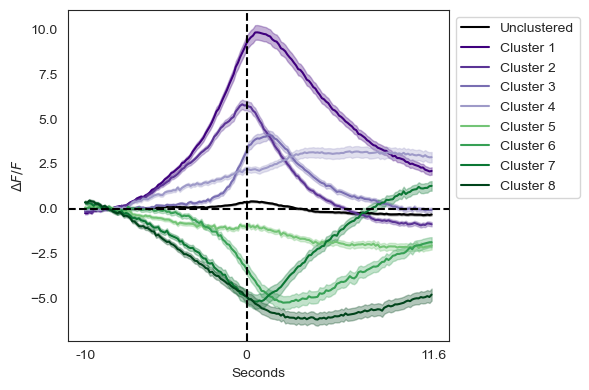

In [12]:
### CREATE LINEPLOT FOR EACH CLUSTER
# Create a figure and axis with the desired size
fig, ax = plt.subplots(figsize=(6, 4))  # Adjust the figsize as needed

# Variables used for data storage and plotting
heatmap_all = np.nan * np.ones((1, window_size))
heatmap_gap = 1  # gap inserted between clusters in heatmap as "empty neurons"

# Replot the data to ensure data was aligned, saved, and loaded correctly
for c in range(numclusters):
    temp = popevents_all[np.where(clusterids_all == c)]
    if plot_zscored_popevents == 'yes':
        for neuron in range(temp.shape[0]):
            neuron_std = np.nanstd(temp[neuron, baselinefirstframe:baselinelastframe])
            temp[neuron, :] = temp[neuron, :]/neuron_std
        if c == 0:
            print('data z-scored')
    cluster_ci = 1.96 * np.std(temp, axis=0) / np.sqrt(len(temp))  ### cluster confidence interval
    cluster_mean = np.mean(temp, axis=0)
    label = f'Cluster {c}' if c > 0 else 'Unclustered'
    ax.plot(cluster_mean, label=label, color=cluster_colors[c])
    ax.fill_between(range(len(cluster_mean)), cluster_mean - cluster_ci, cluster_mean + cluster_ci, alpha=0.3,
                    color=cluster_colors[c])

    # Fill heatmap array for next cell
    if c != 0:
        tempresponse = np.amax(temp, axis=1)
        if peak_responses[c] > 0:
            sortresponse = np.argsort(tempresponse)[::-1]
        else:
            sortresponse = np.argsort(tempresponse)
        heatmap_all = np.vstack((heatmap_all, temp[sortresponse]))
        heatmap_all = np.vstack((heatmap_all, np.nan * np.ones((heatmap_gap, window_size))))
heatmap_all = heatmap_all[1:-heatmap_gap, :]  ### delete extra rows from heatmap array

# Add legend outside the plot
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Add vertical dashed line at pre_window_size
ax.axvline(x=pre_window_size, color='k', linestyle='--')

# Add horizontal dashed line at y=0
ax.axhline(y=0, color='k', linestyle='--')

# Set x-axis and y-axis labels
ax.set_ylabel(r'$\Delta F/F$', fontsize=10)  # Use LaTeX for delta symbol
ax.set_xlabel("Seconds")

# Set x-axis ticks to represent seconds from -10 to +11.6
xticks = [0, pre_window_size, window_size]
xlabels = [int(-pre_window_size / averagedframerate), 0, (window_size - pre_window_size) / averagedframerate]
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)

# Adjust layout to prevent cutting off labels
plt.tight_layout()

# if plot_zscored_popevents == 'no':
    # plt.savefig(os.path.join(basedir, 'Results', 'Clustering_LinePlot.PDF'), format='PDF', bbox_inches='tight')
    # plt.savefig(os.path.join(basedir, 'Results', 'Clustering_LinePlot.PNG'), format='PNG', bbox_inches='tight')
# if plot_zscored_popevents == 'yes':
#     plt.savefig(os.path.join(basedir, 'Results', 'Clustering_LinePlot_zscored.PDF'), format='PDF', bbox_inches='tight')
#     plt.savefig(os.path.join(basedir, 'Results', 'Clustering_LinePlot_zscored.PNG'), format='PNG', bbox_inches='tight')
    
plt.show()

In [13]:
### CREATE HEATPLOT FOR EACH CLUSTER
# Create a figure with the desired size

fig, ax = plt.subplots(figsize=(4, 8))

# Plot the heatmap
im = ax.imshow(heatmap_all, cmap=plt.get_cmap('PRGn_r'), vmin=-cmax, vmax=cmax, aspect='auto')

# Add colorbar
fig.colorbar(im, ax=ax, shrink=0.5)

# Add cluster labels to the left of the heatmap
spacetilnow = 0
for c in range(1, numclusters):
    numneuronstemp = popevents_all[np.where(clusterids_all == c)].shape[0]
    
    # Update the position for the next cluster
    spacetilnow += numneuronstemp + heatmap_gap
    
    # Add cluster label
    ax.text(-50, spacetilnow - (0.5 * numneuronstemp), f'Cluster = {c}', fontsize=10, ha='center', va='center')

ax.axvline(x=pre_window_size, color='k', linestyle='--', linewidth = 1)

ax.set_xlabel("Seconds")
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_yticks([])
ax.set_title('All Days', fontsize=10)

fig.tight_layout()

# plt.savefig(os.path.join(basedir, 'Results', 'Clustering_HeatMap.PDF'), format='PDF')
# plt.savefig(os.path.join(basedir, 'Results', 'Clustering_HeatMap.PNG'), format='PNG')

plt.close()


In [14]:
### CREATE Lineplots FOR EACH CLUSTER on each Day

# Create a figure and axis with the desired size
fig, axs = plt.subplots(1, len(days), figsize=(10, 2), sharex=True, sharey=True)
scalebar_size = 0.3

# Replot the data to ensure data was aligned, saved, and loaded correctly
for d, day in enumerate(sorted(days)):
    ax = axs[d]
    for c in range(numclusters):
        temp = popevents_day[day][np.where(clusterids_day[day] == c)]
        if plot_zscored_popevents == 'yes':
            for neuron in range(temp.shape[0]):
                neuron_std = np.nanstd(temp[neuron, baselinefirstframe:baselinelastframe])
                temp[neuron, :] = temp[neuron, :]/neuron_std
            if d == 0 and c == 0:
                print('data z-scored')
            
        cluster_ci = 1.96 * np.std(temp, axis=0) / np.sqrt(len(temp))  ### cluster confidence interval
        cluster_mean = np.mean(temp, axis=0)
        label = f'Cluster {c}' if c > 0 else 'Unclustered'
        ax.plot(cluster_mean, label=label, color=cluster_colors[c], linewidth = 1.5)
#         ax.fill_between(range(len(cluster_mean)), cluster_mean - cluster_ci, cluster_mean + cluster_ci, alpha=0.3,
#                         color=cluster_colors[c])

    # Add vertical dashed line at pre_window_size
    ax.axvline(x=pre_window_size, color='k', linestyle='--')

    # Add horizontal dashed line at y=0
    ax.axhline(y=0, color='k', linestyle='--')

    # Set y-axis labels only for the far-left graph
    if d == 0:
        ax.set_ylabel(r'%s $\Delta F/F$'%scalebar_size, fontsize=10)  # Use LaTeX for delta symbol

    # Set x-axis and y-axis labels
    ax.set_xlabel(f"{window_size / averagedframerate:.1f} Seconds")
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    
    ax.plot([-6, -6], [0.3, 0.3+scalebar_size], 'k-', lw = 1) ### y-scale bar with a value that is the difference between the second two digits as df/f

    # Remove the border surrounding each graph
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

fig.tight_layout()

# plt.savefig(os.path.join(basedir, 'Results', 'Clustering_LinePlot_Days.PDF'), format='PDF')
# plt.savefig(os.path.join(basedir, 'Results', 'Clustering_LinePlot_Days.PNG'), format='PNG')

plt.close()


data z-scored


In [15]:
### CREATE HEATPLOT FOR EACH CLUSTER, ON EACH DAY
# Create a figure with the desired size
fig, axs = plt.subplots(1, len(days), figsize=(12, 5), sharex=True)

# Loop through each day
for d, day in enumerate(sorted(days)):
    heatmap_day = np.nan*np.ones((1, window_size))
    spacetilnow = 0
    
    for c in range(1, numclusters):
        temp = popevents_day[day][np.where(clusterids_day[day] == c)]
        if plot_zscored_popevents == 'yes':
            for neuron in range(temp.shape[0]):
                neuron_std = np.nanstd(temp[neuron, baselinefirstframe:baselinelastframe])
                temp[neuron, :] = temp[neuron, :]/neuron_std
            if d == 0 and c == 0:
                print('data z-scored')
        tempresponse = np.amax(temp, axis=1)
        if peak_responses[c] > 0:
            sortresponse = np.argsort(tempresponse)[::-1]
        else:
            sortresponse = np.argsort(tempresponse)
        heatmap_day = np.vstack((heatmap_day, temp[sortresponse]))
        heatmap_day = np.vstack((heatmap_day, np.nan * np.ones((heatmap_gap, window_size))))
        numneuronstemp = popevents_day[day][np.where(clusterids_day[day] == c)].shape[0]
        spacetilnow += numneuronstemp + heatmap_gap
    
    heatmap_day = heatmap_day[1:-heatmap_gap, :]  # delete extra rows from heatmap array
    ax = axs[d]
    
    # Plot the heatmap
    im = ax.imshow(heatmap_day, cmap=plt.get_cmap('PRGn_r'), vmin=-cmax, vmax=cmax, aspect='auto')
    
    ax.axvline(x=pre_window_size, color='k', linestyle='--', linewidth=1)
    ax.set_yticks([])

    # Add cluster labels to the left of the heatmap
    spacetilnow = 0
    for c in range(1, numclusters):
        numneuronstemp = popevents_day[day][np.where(clusterids_day[day] == c)].shape[0]
        spacetilnow += numneuronstemp + heatmap_gap
        ax.text(-20, spacetilnow - (0.5 * numneuronstemp), f'{c}', fontsize=10, ha='center', va='center')
    
    ax.set_xlabel("Seconds")
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)
    ax.set_title(f'Day {day},\nn = {np.count_nonzero(clusterids_day[day] != 0)} Neurons', fontsize=10)

# Adjust layout and save/show the plot
plt.tight_layout()
# plt.savefig(os.path.join(basedir, 'Results', 'Clustering_HeatMap_Days.PDF'), format='PDF')
# plt.savefig(os.path.join(basedir, 'Results', 'Clustering_HeatMap_Days.PNG'), format='PNG')
plt.close()


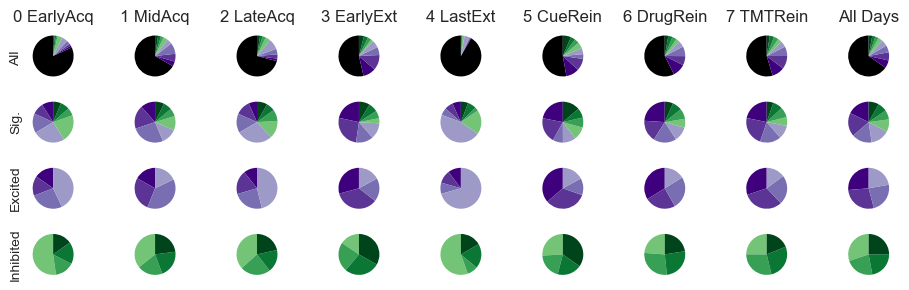

In [16]:
fig, axs = plt.subplots(4, numdays + 1, figsize=(numdays * 1.2, 3), sharex=True, sharey=False)

sns.set_style('white')

numneurons_cluster_day = {}
numneurons_cluster_days = np.nan*np.ones((numclusters, numdays))

for d, day in enumerate(sorted(days)):
    numneurons_cluster_day[day] = []
    for cluster in range(numclusters):
        numneuronstemp = int(np.count_nonzero(clusterids_day[day] == cluster))
        numneurons_cluster_day[day].append(numneuronstemp)
        numneurons_cluster_days[cluster, d] = numneuronstemp

    ax = axs[0, d]
    ax.pie(numneurons_cluster_day[day], colors=cluster_colors, wedgeprops={"edgecolor": "none"}, startangle=90)
    ax.set_title(day)
    if d == 0:
        ax.set_ylabel('All ')
        
    ax = axs[1, d]
    ax.pie(numneurons_cluster_day[day][1:], colors=cluster_colors[1:], wedgeprops={"edgecolor": "none"}, startangle=90)
    if d == 0:
        ax.set_ylabel('Sig.')
        
    ax = axs[2, d]
    ax.pie(numneurons_cluster_day[day][1:np.count_nonzero(peak_responses[1:] > 0) + 1], \
           colors=cluster_colors[1:np.count_nonzero(peak_responses[1:] > 0) + 1], wedgeprops={"edgecolor": "none"},
           startangle=90)
    if d == 0:
        ax.set_ylabel('Excited')
    
    ax = axs[3, d]
    ax.pie(numneurons_cluster_day[day][np.count_nonzero(peak_responses[1:] > 0) + 1:], \
           colors=cluster_colors[np.count_nonzero(peak_responses[1:] > 0) + 1:], wedgeprops={"edgecolor": "none"},
           startangle=90)
    if d == 0:
        ax.set_ylabel('Inhibited')

numneurons_cluster_all = []
for cluster in range(numclusters):
    numneuronstemp = int(np.count_nonzero(clusterids_all == cluster))
    numneurons_cluster_all.append(numneuronstemp)

ax = axs[0, -1]
ax.pie(numneurons_cluster_all, colors=cluster_colors, wedgeprops={"edgecolor": "none"}, startangle=90)
ax.set_title('All Days')

ax = axs[1, -1]
ax.pie(numneurons_cluster_all[1:], colors=cluster_colors[1:], wedgeprops={"edgecolor": "none"}, startangle=90)

ax = axs[2, -1]
ax.pie(numneurons_cluster_all[1:np.count_nonzero(peak_responses[1:] > 0) + 1], \
       colors=cluster_colors[1:np.count_nonzero(peak_responses[1:] > 0) + 1], wedgeprops={"edgecolor": "none"},
       startangle=90)

ax = axs[3, -1]
ax.pie(numneurons_cluster_all[np.count_nonzero(peak_responses[1:] > 0) + 1:], \
       colors=cluster_colors[np.count_nonzero(peak_responses[1:] > 0) + 1:], wedgeprops={"edgecolor": "none"},
       startangle=90)

fig.tight_layout()

# Save the figure
# fig.savefig(os.path.join(basedir, 'Results', 'Clustering_PieCharts.PDF'), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', 'Clustering_PieCharts.PNG'), format='PNG') ### Smaller File. Great for testing code.

plt.show()



In [17]:
### PLOT CHANGES IN THE PROPORTION OF CELLS PER CLUSTER ACROSS DAYS

fig, axs = plt.subplots(4, 2, figsize=(5, 9), sharex=True)

### ROW 1
#Make a copy of numneurons_cluster_days to avoid overwriting findings from above cell
numneurons_cluster_days_proportions = numneurons_cluster_days.copy()

### Line graph showing proportion of all neurons that fit into each cluster per day
ax = axs[0, 0]
ax.set_title('proportion of all neurons')
for c in range(1, numclusters):
    for d, day in enumerate(sorted(days)):
        numneurons_cluster_days_proportions[c, d] /= numneurons_day[day]
    ax.plot(numneurons_cluster_days_proportions[c,:], color = cluster_colors[c]) 

### Heatmap showing proportion of all neurons that fit into each cluster per day
ax = axs[0, 1]
ax.set_title('proportion of all neurons')
for c in range(5, numclusters):
    numneurons_cluster_days_proportions[c,:] = -numneurons_cluster_days_proportions[c,:]
# Plot the heatmap
im = ax.imshow(numneurons_cluster_days_proportions[1:], cmap=plt.get_cmap('PRGn_r'), vmin=-.1, vmax=.1, aspect='auto')
# Add colorbar
fig.colorbar(im, ax=ax)


### ROW 2
#Make another copy of numneurons_cluster_days to avoid overwriting findings from above cell
numneurons_cluster_days_proportions = numneurons_cluster_days.copy()

### Line graph showing proportion of sig. neurons that fit into each cluster per day
ax = axs[1, 0]
ax.set_title('proportion of sig neurons')
for c in range(1, numclusters):
    for d, day in enumerate(sorted(days)):
        temp_significantneurons = np.sum(numneurons_cluster_days[1:, d])
        numneurons_cluster_days_proportions[c, d] /= temp_significantneurons
    ax.plot(numneurons_cluster_days_proportions[c,:], color = cluster_colors[c]) 

### Heatmap showing proportion of sig. neurons that fit into each cluster per day
ax = axs[1, 1]
ax.set_title('proportion of sig neurons')
for c in range(5, numclusters):
    numneurons_cluster_days_proportions[c,:] = -numneurons_cluster_days_proportions[c,:]
# Plot the heatmap
im = ax.imshow(numneurons_cluster_days_proportions[1:], cmap=plt.get_cmap('PRGn_r'), vmin=-.25, vmax=.25, aspect='auto')
# Add colorbar
fig.colorbar(im, ax=ax)


### ROW 3
#Make another copy of numneurons_cluster_days to avoid overwriting findings from above cell
numneurons_cluster_days_proportions = numneurons_cluster_days.copy()

### Line graph showing change in proportion of sig. neurons that fit into each cluster per day vs. day 1
ax = axs[2, 0]
ax.set_title('Δ proportion of all')
for c in range(1, numclusters):
    for d, day in enumerate(sorted(days)):
        numneurons_cluster_days_proportions[c, d] /= numneurons_day[day]
    numneurons_cluster_days_proportions[c, :] /= numneurons_cluster_days_proportions[c, 0]
    ax.plot(numneurons_cluster_days_proportions[c,:], color = cluster_colors[c]) 

# ### CHI SQUARE TEST
# for c in range(1, numclusters):
#     expected_proportion = numneurons_cluster_days[c, 0]/sum(numneurons_cluster_days[1:, 0])
#     unexpected_proportion = 1 - expected_proportion
#     for d, day in enumerate(sorted(days)):
#         f_exp = [expected_proportion*sum(numneurons_cluster_days[1:, d]), unexpected_proportion*sum(numneurons_cluster_days[1:, d])]
#         f_obs = [numneurons_cluster_days[c, d], sum(numneurons_cluster_days[1:, d]) -  numneurons_cluster_days[c, d]]
#         chi, chi_pval = stats.chisquare(f_obs, f_exp)
#         if chi > 100:
#             if f_obs[0] > f_exp[0]:
#                 print(c, day, chi, chi_pval)

### Heatmap showing change in proportion of sig. neurons that fit into each cluster per day vs. day 1
ax = axs[2, 1]
ax.set_title('Δ proportion of all')
for c in range(5, numclusters):
    numneurons_cluster_days_proportions[c,:] = -numneurons_cluster_days_proportions[c,:]
# Plot the heatmap
im = ax.imshow(numneurons_cluster_days_proportions[1:], cmap=plt.get_cmap('PRGn_r'), vmin=-6.5, vmax=6.5, aspect='auto')
# Add colorbar
fig.colorbar(im, ax=ax)

### ROW 4
#Make another copy of numneurons_cluster_days to avoid overwriting findings from above cell
numneurons_cluster_days_proportions = numneurons_cluster_days.copy()

### Line graph showing change in proportion of sig. neurons that fit into each cluster per day vs. day 1
ax = axs[3, 0]
ax.set_title('Δ proportion of sig')
for c in range(1, numclusters):
    for d, day in enumerate(sorted(days)):
        temp_significantneurons = np.sum(numneurons_cluster_days[1:, d])
        numneurons_cluster_days_proportions[c, d] /= temp_significantneurons
    numneurons_cluster_days_proportions[c, :] /= numneurons_cluster_days_proportions[c, 0]
    ax.plot(numneurons_cluster_days_proportions[c,:], color = cluster_colors[c]) 

### Heatmap showing change in proportion of sig. neurons that fit into each cluster per day vs. day 1
ax = axs[3, 1]
ax.set_title('Δ proportion of sig')
for c in range(5, numclusters):
    numneurons_cluster_days_proportions[c,:] = -numneurons_cluster_days_proportions[c,:]
# Plot the heatmap
im = ax.imshow(numneurons_cluster_days_proportions[1:], cmap=plt.get_cmap('PRGn_r'), vmin=-2.5, vmax=2.5, aspect='auto')
# Add colorbar
fig.colorbar(im, ax=ax)

plt.close()


# plt.savefig(os.path.join(basedir, 'Results', 'Cluster Proportion Change Days.PDF'), format='PDF')
# plt.savefig(os.path.join(basedir, 'Results', 'Cluster Proportion Change Days.png'), format='PNG')


# WITHIN SESSION RESPONSE STABILITY

In [30]:
### THIS SECTION ANALYZES WITHIN SESSION TRIAL STABILITY. ADJUST PARAMETERS BELOW TO YOUR LIKING

# Calculate by 'mean' or 'auROC'
measurement = 'auROC'
event = 'activeleverall' ### 'activeleverall' or 'cueresponse'

proportion_of_trials = 0.33 ### proportion of trials at beggining and end of session to compare. Low numbers may not work if there are very few trials

if measurement == 'mean':
    xlim=([-5,5])
    ylim=([-5,5])
else:
    xlim=([-1.1,1.1])
    ylim=([-1.1,1.1])
    
if event == 'cueresponse':
    epoch_baseline = [pre_window_size-int(1.6*averagedframerate), pre_window_size] ### For Cue
    epoch_event = [pre_window_size, pre_window_size+int(1.6*averagedframerate)] ### For Cue
    

In [31]:
### CREATE ARRAYS FOR COMPARISON OF TRIAL STABILITY

cellcounter = 0
within_stability_all = np.nan*np.ones((numneurons_all, 2))

if event == 'activeleverall':
    print(event)
    for basedir, day, animal, fov in iterate_dirs(basedir, days):
        tempfiles = next(os.walk(os.path.join(basedir, day, animal, fov)))[2]
        if 'alignedevents_%s_%s.npy'%(eventofinterest, separation_requirement) in tempfiles:
            alignedevents_fov = np.load(os.path.join(basedir, day, animal, fov, 'alignedevents_%s_%s.npy'%(eventofinterest, separation_requirement)))
            numtrials = alignedevents_fov.shape[2]
            numtrialsforstability = int(np.floor(numtrials*proportion_of_trials))
            numneurons = (np.shape(alignedevents_fov)[0])
            for neuron in range(numneurons):
                if numtrialsforstability < 2:
                    within_stability_all[cellcounter+neuron,0] = np.nan
                    within_stability_all[cellcounter+neuron,1] = np.nan
                elif measurement == 'mean':
                    within_stability_all[cellcounter+neuron,0] = np.nanmean(alignedevents_fov[neuron,aucfirstframe:auclastframe,:numtrialsforstability])- \
                                                     np.nanmean(alignedevents_fov[neuron,baselinefirstframe:baselinelastframe,:numtrialsforstability])
                    within_stability_all[cellcounter+neuron,1] = np.nanmean(alignedevents_fov[neuron,aucfirstframe:auclastframe,-numtrialsforstability:])- \
                                                     np.nanmean(alignedevents_fov[neuron,baselinefirstframe:baselinelastframe,-numtrialsforstability:])
                elif measurement == 'auROC':
                    within_stability_all[cellcounter+neuron,0] = calculate_auROC(np.nanmean(alignedevents_fov[neuron,aucfirstframe:auclastframe,-numtrialsforstability:], axis = 1), \
                                                     np.nanmean(alignedevents_fov[neuron,baselinefirstframe:baselinelastframe,-numtrialsforstability:], axis = 1))[0]
                    within_stability_all[cellcounter+neuron,1] = calculate_auROC(np.nanmean(alignedevents_fov[neuron,aucfirstframe:auclastframe,:numtrialsforstability], axis = 1), \
                                                     np.nanmean(alignedevents_fov[neuron,baselinefirstframe:baselinelastframe,:numtrialsforstability], axis = 1))[0]
            cellcounter+=numneurons

if event == 'cueresponse':
    for basedir, day, animal, fov in iterate_dirs(basedir, days):
        tempfiles = next(os.walk(os.path.join(basedir, day, animal, fov)))[2]
        if 'alignedevents_%s_%s.npy'%('activeleverall', separation_requirement) in tempfiles:
            alignedevents_fov = np.load(os.path.join(basedir, day, animal, fov, 'alignedevents_%s_%s.npy'%('activeleverall', separation_requirement)))
            numneurons = (np.shape(alignedevents_fov)[0])
            if 'alignedevents_%s_%s.npy'%('activelevertimeout', separation_requirement) not in tempfiles:
                for neuron in range(numneurons):
                    within_stability_all[cellcounter+neuron,0] = np.nan
                    within_stability_all[cellcounter+neuron,1] = np.nan
            else:
                alignedevents1_fov = np.load(os.path.join(basedir, day, animal, fov, 'alignedevents_%s_%s.npy'%('activelever', separation_requirement)))
                alignedevents2_fov = np.load(os.path.join(basedir, day, animal, fov, 'alignedevents_%s_%s.npy'%('activelevertimeout', separation_requirement)))
                numtrials1 = alignedevents1_fov.shape[2]
                numtrialsforstability1 = int(np.floor(numtrials1*proportion_of_trials))
                numtrials2 = alignedevents2_fov.shape[2]
                numtrialsforstability2 = int(np.floor(numtrials2*proportion_of_trials))
                for neuron in range(numneurons):
                    alignedevents1_neuron = alignedevents1_fov[neuron, :, :]
                    alignedevents2_neuron = alignedevents2_fov[neuron, :, :]
                    alignedevents1_neuron_baseline = np.mean(alignedevents1_neuron[epoch_baseline[0]:epoch_baseline[1],:], axis = 0)
                    alignedevents2_neuron_baseline = np.mean(alignedevents2_neuron[epoch_baseline[0]:epoch_baseline[1],:], axis = 0)
                    alignedevents1_neuron = alignedevents1_neuron - alignedevents1_neuron_baseline[None, :]
                    alignedevents2_neuron = alignedevents2_neuron = alignedevents2_neuron_baseline[None, :]
                    cueresponse = alignedevents1_neuron - np.mean(alignedevents2_neuron, axis = 1)[:, None]                     
                    if numtrialsforstability1 < 2 or numtrialsforstability2 < 2:
                        within_stability_all[cellcounter+neuron,0] = np.nan
                        within_stability_all[cellcounter+neuron,1] = np.nan
                    elif measurement == 'mean':
                        within_stability_all[cellcounter+neuron,0] = np.nanmean(cueresponse[epoch_event[0]:epoch_event[1],:numtrialsforstability1])- \
                                                         np.nanmean(cueresponse[epoch_baseline[0]:epoch_baseline[1],:numtrialsforstability1])
                        within_stability_all[cellcounter+neuron,1] = np.nanmean(cueresponse[epoch_event[0]:epoch_event[1],-numtrialsforstability1:])- \
                                                         np.nanmean(cueresponse[epoch_baseline[0]:epoch_baseline[1],-numtrialsforstability1:])
                    elif measurement == 'auROC':
                        within_stability_all[cellcounter+neuron,0] = calculate_auROC(np.nanmean(cueresponse[epoch_event[0]:epoch_event[1],-numtrialsforstability1:], axis = 1), \
                                                         np.nanmean(cueresponse[epoch_baseline[0]:epoch_baseline[1],-numtrialsforstability1:], axis = 1))[0]
                        within_stability_all[cellcounter+neuron,1] = calculate_auROC(np.nanmean(cueresponse[epoch_event[0]:epoch_event[1],:numtrialsforstability1], axis = 1), \
                                                         np.nanmean(cueresponse[epoch_baseline[0]:epoch_baseline[1],:numtrialsforstability1], axis = 1))[0]
            cellcounter+=numneurons


activeleverall


r = 0.30921, p =  0.00000
t = 0.04808, p =  0.96165


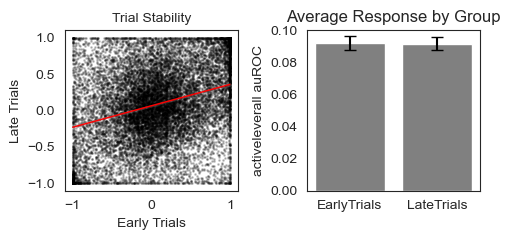

In [32]:
# ALL DAYS CORRELATION

# Calculate Pearson correlation
valid_indices = ~np.isnan(within_stability_all[:, 0])
rval, rpval = stats.pearsonr(within_stability_all[:, 0][valid_indices], within_stability_all[:, 1][valid_indices])
tval, tpval = stats.ttest_rel(within_stability_all[:, 0][valid_indices], within_stability_all[:, 1][valid_indices])

# Create a DataFrame from within_stability_all
df = pd.DataFrame(within_stability_all, columns=['EarlyTrials', 'LateTrials'])

# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(5, 2.5))

# Subplot 1: Correlation plot
axs[0].scatter(x='EarlyTrials', y='LateTrials', data=df, 
                color='black', alpha=.2, s=1)
sns.regplot(x='EarlyTrials', y='LateTrials', data=df, ax=axs[0],
            line_kws={'color': 'red', 'linewidth': 1}, scatter=False)

axs[0].set_xlabel('Early Trials')  # Set the x-axis label
axs[0].set_ylabel('Late Trials')  # Set the y-axis label
axs[0].set_title('Trial Stability', fontsize=10)  # Set the title of the plot
print(f'r = {rval:.5f}, p = {rpval: .5f}')  # Display correlation information
print(f't = {tval:.5f}, p = {tpval: .5f}')  # Display ttest information

axs[0].set_xlim(xlim[0], xlim[1])  # Set equal aspect ratio
axs[0].set_ylim(ylim[0], ylim[1])  # Set equal aspect ratio

if measurement == 'mean':
    axs[0].set_xscale('symlog')
    axs[0].set_yscale('symlog')

# Calculate means and SEM
mean_early = np.nanmean(within_stability_all[:, 0])
mean_late = np.nanmean(within_stability_all[:, 1])
sem_early = stats.sem(within_stability_all[:, 0],  nan_policy='omit')
sem_late = stats.sem(within_stability_all[:, 1], nan_policy='omit')

# Subplot 2: Bar graph with error bars representing SEM
sns.barplot(x=['EarlyTrials', 'LateTrials'], y=[mean_early, mean_late], ax=axs[1], color = 'gray')
axs[1].errorbar(x=['EarlyTrials', 'LateTrials'], y=[mean_early, mean_late], yerr=[sem_early, sem_late], fmt='none', color='black', capsize=4)

axs[1].set_ylabel('%s %s'%(event, measurement))
axs[1].set_ylim(0, .1)

axs[1].set_title('Average Response by Group')


plt.tight_layout()

# plt.savefig(os.path.join(basedir, 'Results', 'Trial Stability, All %s %s.PDF' % (event, measurement)), format='PDF')
# plt.savefig(os.path.join(basedir, 'Results', 'Trial Stability, All %s %s.png' % (event, measurement)), format='PNG')

plt.show()

# r = 0.35404, p =  0.00000
# t = -1.92697, p =  0.05400

clustered r = 0.58374, p =  0.00000
clustered t = 5.78754, p =  0.00000
not clustered r = -0.02547, p =  0.01187
not clustered t = -3.85370, p =  0.00012


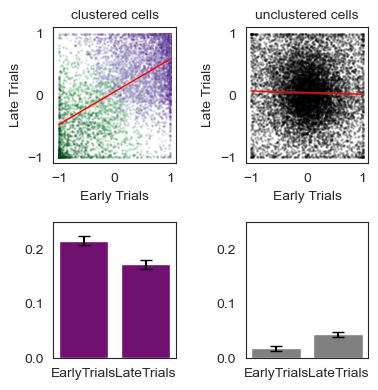

In [33]:
### ALL CLUSTERS CORRELATION
### CDF PLOTS FOR SPLIT BY CLUSTER ###
fig, axs = plt.subplots(2, 2, figsize=(4, 4))
sns.set_style('white')

# Create a scatter plot with a regression line for clustered neurons
for c in range(1,numclusters):
    temp_clustered = within_stability_all[np.where(clusterids_all == c)]
    
    ax = axs[0,0]
    ax.scatter(x=temp_clustered[:, 0], y=temp_clustered[:, 1], s = 1,
        color = cluster_colors[c], alpha = .2)

ax.set_ylabel('Late Trials')  # Set the y-axis label

ax.set_xlabel('Early Trials')  # Set the x-axis label
ax.set_title('clustered cells', fontsize=10)  # Set the title of the plot

temp_clustered = within_stability_all[np.where(clusterids_all > 0)]
sns.regplot(x=temp_clustered[:, 0], y=temp_clustered[:, 1], ax = ax, scatter = False,
           line_kws={'color': 'red', 'linewidth': 1})

# Create a scatter plot with a regression line for not clustered neurons
ax = axs[0,1]
temp_notclustered = within_stability_all[np.where(clusterids_all == 0)]
ax.scatter(x=temp_notclustered[:, 0], y=temp_notclustered[:, 1], s = 1,
    color = 'k', alpha = .2)
sns.regplot(x=temp_notclustered[:, 0], y=temp_notclustered[:, 1], ax = ax, scatter = False,
           line_kws={'color': 'red', 'linewidth': 1})

ax.set_ylabel('Late Trials')  # Set the y-axis label
ax.set_xlabel('Early Trials')  # Set the x-axis label
ax.set_title('unclustered cells', fontsize=10)  # Set the title of the plot

# Calculate means and SEM
mean_early = np.nanmean(within_stability_all[:, 0][np.where(clusterids_all > 0)])
mean_late = np.nanmean(within_stability_all[:, 1][np.where(clusterids_all > 0)])
sem_early = stats.sem(within_stability_all[:, 0][np.where(clusterids_all > 0)],  nan_policy='omit')
sem_late = stats.sem(within_stability_all[:, 1][np.where(clusterids_all > 0)], nan_policy='omit')

# Subplot 2: Bar graph with error bars representing SEM
ax = axs[1, 0]
sns.barplot(x=['EarlyTrials', 'LateTrials'], y=[mean_early, mean_late], ax=ax, color = 'purple')
ax.errorbar(x=['EarlyTrials', 'LateTrials'], y=[mean_early, mean_late], yerr=[sem_early, sem_late], fmt='none', color='black', capsize=4)

# Calculate means and SEM
mean_early = np.nanmean(within_stability_all[:, 0][np.where(clusterids_all == 0)])
mean_late = np.nanmean(within_stability_all[:, 1][np.where(clusterids_all == 0)])
sem_early = stats.sem(within_stability_all[:, 0][np.where(clusterids_all == 0)],  nan_policy='omit')
sem_late = stats.sem(within_stability_all[:, 1][np.where(clusterids_all == 0)], nan_policy='omit')

# Subplot 2: Bar graph with error bars representing SEM
ax = axs[1, 1]
sns.barplot(x=['EarlyTrials', 'LateTrials'], y=[mean_early, mean_late], ax=ax, color = 'gray')
ax.errorbar(x=['EarlyTrials', 'LateTrials'], y=[mean_early, mean_late], yerr=[sem_early, sem_late], fmt='none', color='black', capsize=4)

# Calculate Pearson correlations and T-tests
valid_indices = ~np.isnan(temp_clustered[:, 0]) & ~np.isnan(temp_clustered[:, 1])
rval, rpval = stats.pearsonr(temp_clustered[:, 0][valid_indices], temp_clustered[:, 1][valid_indices])
tval, tpval = stats.ttest_rel(temp_clustered[:, 0][valid_indices],temp_clustered[:, 1][valid_indices])
print(f'clustered r = {rval:.5f}, p = {rpval: .5f}')  # Display correlation information
print(f'clustered t = {tval:.5f}, p = {tpval: .5f}')  # Display ttest information

valid_indices = ~np.isnan(temp_notclustered[:, 0]) & ~np.isnan(temp_notclustered[:, 1])
rval, rpval = stats.pearsonr(temp_notclustered[:, 0][valid_indices],temp_notclustered[:, 1][valid_indices])
tval, tpval = stats.ttest_rel(temp_notclustered[:, 0][valid_indices],temp_notclustered[:, 1][valid_indices])
print(f'not clustered r = {rval:.5f}, p = {rpval: .5f}')  # Display correlation information
print(f'not clustered t = {tval:.5f}, p = {tpval: .5f}')  # Display ttest information

for column in range(2):
    ax = axs[0, column]
    ax.set_xlim(xlim[0], xlim[1])  
    ax.set_ylim(ylim[0], ylim[1]) 
    if measurement == 'mean':
        ax.set_xscale('symlog')
        ax.set_yscale('symlog')
    ax = axs[1, column]
    ax.set_ylim(0, 0.25)  
    
plt.tight_layout()  

# plt.savefig(os.path.join(basedir, 'Results', 'Trial Stability, Clusters %s %s.PDF'%(event, measurement)), format='PDF')
# plt.savefig(os.path.join(basedir, 'Results', 'Trial Stability, Clusters %s %s.png'%(event, measurement)), format='PNG')

plt.show()
# clustered r = 0.65997, p =  0.00000
# clustered t = 3.56785, p =  0.00036
# not clustered r = -0.06798, p =  0.00000
# not clustered t = -4.55460, p =  0.00001


In [34]:
### ALL CLUSTERS BY DAY CORRELATION
### CDF PLOTS FOR SPLIT BY CLUSTER ###
fig, axs = plt.subplots(2, numdays, figsize=(1.8*numdays, 3.5))
sns.set_style('white')

heatmap_array = np.nan*np.ones((2, numdays))

for d, day in enumerate(sorted(days)):
    # Create a scatter plot with a regression line for clustered neurons on each day
    for c in range(1,numclusters):
        temp_clustered = within_stability_all[idxs_day[day]][np.where(clusterids_all[idxs_day[day]] == c )]
        ax = axs[0, d]
        ax.scatter(x=temp_clustered[:, 0], y=temp_clustered[:, 1], s = 3,
            color = cluster_colors[c], alpha = .2)
    if d != 0:
        ax.get_yaxis().set_visible(False)
    ax.get_xaxis().set_visible(False)

    ax.set_title(day, fontsize=10)  # Set the title of the plot

    temp_clustered = within_stability_all[idxs_day[day]][np.where(clusterids_all[idxs_day[day]] > 0 )]
    sns.regplot(x=temp_clustered[:, 0], y=temp_clustered[:, 1], ax = ax, scatter = False,
               line_kws={'color': 'red', 'linewidth': 1})
    
    # Create a scatter plot with a regression line for not clustered neurons
    ax = axs[1, d]
    temp_notclustered = within_stability_all[idxs_day[day]][np.where(clusterids_all[idxs_day[day]] == 0)]
    ax.scatter(x=temp_notclustered[:, 0], y=temp_notclustered[:, 1], s = 3,
        color = 'k', alpha = .2)
    sns.regplot(x=temp_notclustered[:, 0], y=temp_notclustered[:, 1], ax = ax, scatter = False,
               line_kws={'color': 'red', 'linewidth': 1})
    
    if d != 0:
        ax.get_yaxis().set_visible(False)
    ax.get_xaxis().set_visible(False)
    
    for row in axs:
        for ax in row:
            ax.set_xlim(xlim[0], xlim[1])  
            ax.set_ylim(ylim[0], ylim[1]) 
            if measurement == 'mean':
                ax.set_xscale('symlog')
                ax.set_yscale('symlog')
    
    # Calculate Pearson correlations
    if np.count_nonzero(~np.isnan(temp_clustered[:,0])) > 2:
        valid_indices = ~np.isnan(temp_clustered[:, 0]) & ~np.isnan(temp_clustered[:, 1])
        rval, pval = stats.pearsonr(temp_clustered[:, 0][valid_indices], temp_clustered[:, 1][valid_indices])
#         print(day, 'clustered, r = %s, p = %s'%(rval, pval))
    heatmap_array[0, d] = rval

    if np.count_nonzero(~np.isnan(temp_notclustered[:,0])) > 2:
        valid_indices = ~np.isnan(temp_notclustered[:, 0]) & ~np.isnan(temp_notclustered[:, 1])
        rval, pval = stats.pearsonr(temp_notclustered[:, 0][valid_indices],temp_notclustered[:, 1][valid_indices])
#         print(day, 'notclustered, r = %s, p = %s'%(rval, pval))
    heatmap_array[1, d] = rval

plt.tight_layout()  

# plt.savefig(os.path.join(basedir, 'Results', 'Trial Stability Correlation, Day %s %s.PDF'%(event, measurement)), format='PDF')
# plt.savefig(os.path.join(basedir, 'Results', 'Trial Stability Correlation, Day %s %s.png'%(event, measurement)), format='PNG')

plt.close()


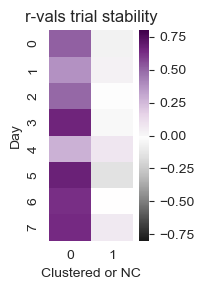

In [35]:
### CREATE RESPONSE STABILITY HEATMAP FOR EACH DAY
# Extract the purple and grey segments from the respective colormaps
prgn_r = plt.get_cmap('PRGn_r')
rdgy_r = plt.get_cmap('RdGy_r')

# Define the number of colors you want from each colormap segment
n_colors = 256
n_half_colors = n_colors // 2

# Create a new colormap by combining the two segments
colors = np.vstack((
    rdgy_r(np.linspace(0, 0.5, n_half_colors)),
    prgn_r(np.linspace(0.5, 1, n_half_colors))
))

# Create the custom colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors)

# Now plot using the custom colormap
fig, axs = plt.subplots(1, figsize=(2, 3), sharex=True)

# First heatmap
ax = axs
sns.heatmap(heatmap_array.T, cmap=custom_cmap, vmin=-0.8, vmax=0.8, ax=ax, cbar=True, square=False)
ax.set_title('r-vals trial stability')
ax.set_xlabel('Clustered or NC')
ax.set_ylabel('Day')


# Adjust layout and save figures
plt.tight_layout()
# plt.savefig(os.path.join(basedir, 'Results', 'Trial Stability Heatmap Rvals, Day %s %s.PDF' % (event, measurement)), format='PDF')
# plt.savefig(os.path.join(basedir, 'Results', 'Trial Stability Heatmap Rvals, Day %s %s.png' % (event, measurement)), format='PNG')
plt.show()



# DECODING, START HERE IF YOU WANT A NEW DECODING ANALYSIS

In [36]:
def binaryclassifier(y, X):
    hyperparameters = {'kernel': ['rbf'], 'gamma': [1e-2, 1e-1, 1e0, 1e1, 1e2],
                     'C': [1e-2, 1e-1, 1e0, 1e1, 1e2]}
    clf = GridSearchCV(SVC(), hyperparameters, cv=10)
    if np.any(np.isnan(X)):
        accuracy=np.nan
        print ('nan detected in single neuron! within ', fov)
    if y.shape[0] < 20:
        accuracy=np.nan
    else:
        clf.fit(X, y)
        accuracy = clf.best_score_
    return accuracy

def svmregression(y, X):
    hyperparameters = {'kernel': ['rbf'], 'C': np.logspace(-3, 3, 5),
                      'epsilon': np.logspace(-3, 3, 5),
                      'gamma': np.logspace(-5, 5, 10)}
    clf = GridSearchCV(SVR(), hyperparameters, cv=10)
    if np.all(np.isnan(X)):
        R2=np.nan
    else:
        clf.fit(X, y)
        """y_pred = clf.predict(X)
        plt.plot(y,y_pred,'ko')"""
        R2 = clf.best_score_
    #reference for 10-fold cross-validation http://web.cs.iastate.edu/~jtian/cs573/Papers/Kohavi-IJCAI-95.pdf
    return R2

# DECODING - NO NEED TO RUN IF YOU'VE ALREADY SAVED DECODING RESULTS

In [38]:
### SAVE NEW DECODING OR LOAD PREVIOUS? 
save_decoding_array = 'no' ###'yes' or 'no'

### SAVE/LOAD CUE OR INFUSION DECODING?
decoding_stimulus = 'Lever' ### 'Cue' or 'Infusion'

### INCREASE OR DECREASE NUMBER OF TRIALS TO EVEN TRIAL NUMBERS? 'NONE' AND 'UPSAMPLE' MAY GIVE INCORRECT RESULTS DUE TO TRIAL BIAS,
trial_sampling = 'none' ###'upsample', 'downsample', or 'none'

### HOW MANY TIMES DO YOU WANT TO REPEAT SHUFFLING ANALYSIS FOR EACH NEURON? THIS WILL TAKE TIME FOR EACH SHUFFLE BUT MAY PREVENT ARBITRARY DECODING IN SHUFFLED DATASETS
numshuffles = 1


In [39]:
### THIS DECODING ALGORITHM HAS BEEN VALIDATED (CORRELATIONS WITH T-TESTS, AUROC, MEAN ADAPTATIONS. IT COMPARES THE FLUORESCENCE AVERAGE OF A BASELINE EPOCH TO CUE EPOCH###
###DECODING. Note: this takes time (e.g., ~45 minutes for 3500 neurons).

if decoding_stimulus == 'Lever':
    epoch_baseline = [0, int(3*averagedframerate)] ### For Lever baseline
    epoch_event = [pre_window_size-int(3*averagedframerate), pre_window_size] ### For Cue
    numframes = epoch_baseline[1]-epoch_baseline[0]


### Save data for all decoded neurons and save to an array that is organized using cell_mapping function
if save_decoding_array == 'yes':
    decoding_all = np.nan*np.ones((numneurons_all))
    decoding_shuffled_all = np.nan*np.ones((numneurons_all))
    for basedir, day, animal, fov in iterate_dirs(basedir, days):
        tempfiles = next(os.walk(os.path.join(basedir, day, animal, fov)))[2]
        if 'alignedevents_%s_%s.npy'%('activeleverall', separation_requirement) in tempfiles: 
        
            temp1 = np.load(os.path.join(basedir, day, animal, fov, 'alignedevents_%s_%s.npy'%('activeleverall', separation_requirement)))  
            
            numtrials = np.shape(temp1)[2]           
            numneurons = np.shape(temp1)[0]
            
            temp_unshuffled = []
            temp_shuffled = []
            
            responses = temp1[:, epoch_event[0]:epoch_event[1], :]
            baselines = temp1[:, epoch_baseline[0]:epoch_baseline[1], :]

            labels = np.hstack((np.zeros(numframes), np.ones(numframes)))

            ###Extract time series data for the current neuron from alignedevents1 and alignedevents2
            for neuron in tqdm(range(numneurons), desc=f"Processing {day} - {animal} - {fov}"):

                ###Stack time series data for the current neuron from both samples
                features_neuron = np.vstack((responses[neuron, :, :], baselines[neuron, :, :]))
                features_neuron = np.nanmean(features_neuron, axis = 1)
                features_neuron = features_neuron.reshape(-1, 1)

                ###Apply binary classifier function
                decoding_neuron = binaryclassifier(labels, features_neuron)                    

                ###Shuffle labels and perform shuffled binary classifier function as a control
                temp_shuffled_neuron = np.nan*np.ones((numshuffles)) ### Shuffled analysis will be repeated based on "numshuffles" defined above

                for i in range(numshuffles):
                    labels_shuffled = np.random.permutation(labels)
                    temp_shuffled_neuron[i] = binaryclassifier(labels_shuffled, features_neuron)

                decoding_shuffled_neuron = np.mean(temp_shuffled_neuron)

                temp_unshuffled = np.append(decoding_neuron, temp_unshuffled)
                temp_shuffled = np.append(decoding_shuffled_neuron, temp_shuffled)

                ###Use cell_mapping dictionary to infer the position of the neuron
                position = cell_mapping[(day, animal, fov, neuron)]
                decoding_all[position] = decoding_neuron
                decoding_shuffled_all[position] = decoding_shuffled_neuron

            print(day, animal, stats.ttest_rel(temp_unshuffled, temp_shuffled))
   
    if decoding_stimulus == 'Lever':                   
        np.save(os.path.join(basedir, 'Results', 'decoding_lever.npy'), decoding_all)  
        np.save(os.path.join(basedir, 'Results', 'decoding_lever_shuffled.npy'), decoding_shuffled_all) 

    
###Load Data and Create Arrays for Each Day
if decoding_stimulus == 'Lever':
    decoding_all = np.load(os.path.join(basedir, 'Results', 'decoding_lever.npy'))
    decoding_shuffled_all = np.load(os.path.join(basedir, 'Results', 'decoding_lever_shuffled.npy'))

decoding_all -= np.nanmean(decoding_shuffled_all)
decoding_shuffled_all -= np.nanmean(decoding_shuffled_all)

decoding_day = {}
decoding_shuffled_day = {}
keys_day = {}

for d, day in enumerate(sorted(days)):
    decoding_day[day] = []
    decoding_shuffled_day[day] = []
    keys_day[day] = [key for key in cell_mapping.keys() if key[0] == day]
    for neuron_key in keys_day[day]:
        cell_number = cell_mapping[(neuron_key)]
        decoding_day[day] = np.append(decoding_day[day], decoding_all[cell_number])
        decoding_shuffled_day[day] = np.append(decoding_shuffled_day[day], decoding_shuffled_all[cell_number])
#     print(day, stats.ttest_rel(decoding_day[day], decoding_shuffled_day[day], nan_policy = 'omit'))


    

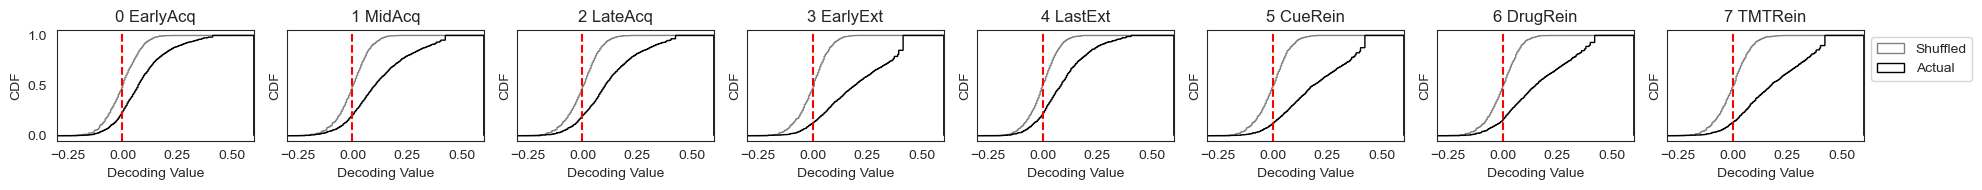

In [44]:
### CDF PLOTS FOR ALL NEURONS ###
### FIGURE SETTINGS ###
fig, axs = plt.subplots(1, len(days), figsize=(2.5*len(days), 2), sharex=True, sharey=False)

sns.set_style('white')
colors = ['black', 'gray']
bins = np.arange(-0.3,0.6,0.001) ###insert <min and >max of decoding values as left two nummbers, right number is binsize

for d, day in enumerate(sorted(days)):
    ax=axs[d]
    ax.hist(([decoding_day[day]-np.nanmean(decoding_shuffled_day[day]), decoding_shuffled_day[day]-np.nanmean(decoding_shuffled_day[day])]),  density=True, cumulative=True,\
       label = ['Actual','Shuffled'], histtype='step',\
        linestyle = ('-'), color = colors, linewidth=1, bins=bins)
    ax.axvline(0, linestyle='--', color='r', linewidth=1.5)
    ax.set_xlim(-0.3,0.6)
    ax.set_ylim(-0.05,1.05)
    
    ax.set_title(day)
    ax.set_xlabel('Decoding Value')
    ax.set_ylabel('CDF')
    if d != 0:
        ax.set_yticks([])
    if d == len(days)-1:
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

fig.tight_layout()

# fig.savefig(os.path.join(basedir, 'Results', '%s Decoding All.PDF'%decoding_stimulus), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', '%s Decoding All.png'%decoding_stimulus), format='PNG')


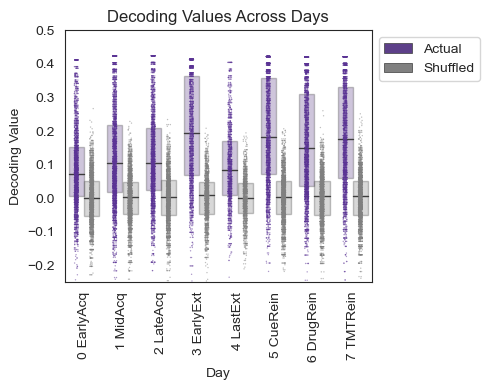

In [45]:
### BOX AND STRIP PLOTS FOR ALL NEURONS ###
### FIGURE SETTINGS ###
fig, ax = plt.subplots(figsize=(5, 4))  # Adjust the figure size as needed

sns.set_style('white')
colors = [cluster_colors[2], 'gray']

# Prepare data for the box plot
data = []
labels = []
group_labels = []

for day in sorted(days):
    actual_values = decoding_day[day] - np.nanmean(decoding_shuffled_day[day])
    shuffled_values = decoding_shuffled_day[day] - np.nanmean(decoding_shuffled_day[day])
    data.extend(actual_values)
    labels.extend(['Actual'] * len(actual_values))
    group_labels.extend([day] * len(actual_values))
    data.extend(shuffled_values)
    labels.extend(['Shuffled'] * len(shuffled_values))
    group_labels.extend([day] * len(shuffled_values))

# Create a DataFrame for the box plot
df = pd.DataFrame({'Decoding Value': data, 'Type': labels, 'Day': group_labels})

# Plot the box plot
sns.boxplot(x='Day', y='Decoding Value', hue='Type', data=df, palette=colors, dodge=1, ax=ax, linewidth=1, fliersize=0, width=0.8, boxprops=dict(alpha=0.3), whiskerprops=dict(alpha=0), capprops=dict(alpha=0), medianprops=dict(alpha=1))

# Plot the strip plot
sns.stripplot(x='Day', y='Decoding Value', hue='Type', size=1, alpha=0.5, data=df, palette=colors, dodge=0.1, jitter=0.1, ax=ax)

# Reduce legend duplication
handles, labels = ax.get_legend_handles_labels()
unique_labels = list(set(labels))
unique_handles = [handles[labels.index(label)] for label in unique_labels]
ax.legend(unique_handles, unique_labels, loc='upper left', bbox_to_anchor=(1, 1))

ax.set_xlim(-0.5, len(days) - 0.5)
ax.set_ylim(-0.25, 0.5)
ax.set_title('Decoding Values Across Days')
ax.set_xlabel('Day')
ax.set_ylabel('Decoding Value')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

fig.tight_layout()

# Save the figure
# fig.savefig(os.path.join(basedir, 'Results', '%s Decoding StripPlot.PDF'%decoding_stimulus), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', '%s Decoding StripPlot.png'%decoding_stimulus), format='PNG')
plt.show()


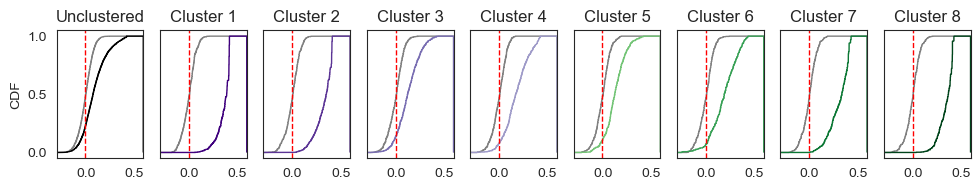

In [46]:
### CDF PLOTS FOR SPLIT BY CLUSTER ###
fig, axs = plt.subplots(1, numclusters, figsize=(10, 2), sharex=True, sharey=False)
sns.set_style('white')

for c in range(numclusters):
    decoding_cluster = []
    decoding_shuffled_cluster = []
    for d, day in enumerate(sorted(days)):   
        decoding_temp = decoding_day[day][np.where(clusterids_day[day] == c)] 
        decoding_shuffled_temp = decoding_shuffled_day[day][np.where(clusterids_day[day] == c)] 
        
        decoding_temp = decoding_temp - np.nanmean(decoding_shuffled_temp)
        decoding_shuffled_temp = decoding_shuffled_temp - np.nanmean(decoding_shuffled_temp)
        
        decoding_cluster = np.hstack((decoding_cluster, decoding_temp))
        decoding_shuffled_cluster = np.hstack((decoding_shuffled_cluster, decoding_shuffled_temp))
        
    ax = axs[c]
    ax.hist(([decoding_cluster, decoding_shuffled_cluster]),  density=True, cumulative=True,\
        label = ['Actual','Shuffled'], histtype='step',\
        linestyle = ('-'), color = [cluster_colors[c], 'grey'], linewidth=1, bins=bins)
    ax.axvline(np.nanmean(decoding_shuffled_day[day]), linestyle='--', color='r', linewidth=1)
    ax.set_xlim(-0.3,0.6)
    ax.set_ylim(-0.05,1.05)
    ax.set_title(f'Cluster {c}' if c > 0 else 'Unclustered')
    
    if c == 0:
        ax.set_ylabel('CDF')
    else:
        ax.set_yticks([])
fig.tight_layout()
    

# fig.savefig(os.path.join(basedir, 'Results', 'Decoding_CDF_Clusters.PDF'), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', 'Decoding_CDF_Clusters.png'), format='PNG')

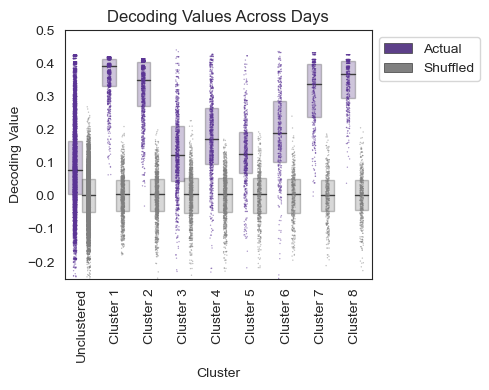

In [47]:
### BOX AND STRIP PLOTS FOR ALL NEURONS ###
### FIGURE SETTINGS ###
fig, ax = plt.subplots(figsize=(5, 4))  # Adjust the figure size as needed

sns.set_style('white')
colors = [cluster_colors[2], 'gray']

# Prepare data for the box plot
data = []
labels = []
group_labels = []

for c in range(numclusters):
    decoding_cluster = []
    decoding_shuffled_cluster = []
    for day in sorted(days):
        decoding_temp = decoding_day[day][np.where(clusterids_day[day] == c)]
        decoding_shuffled_temp = decoding_shuffled_day[day][np.where(clusterids_day[day] == c)]

        decoding_temp = decoding_temp - np.nanmean(decoding_shuffled_temp)
        decoding_shuffled_temp = decoding_shuffled_temp - np.nanmean(decoding_shuffled_temp)

        decoding_cluster.extend(decoding_temp)
        decoding_shuffled_cluster.extend(decoding_shuffled_temp)

    # Add data for the current cluster
    data.extend(decoding_cluster)
    labels.extend(['Actual'] * len(decoding_cluster))
    group_labels.extend([f'Cluster {c}' if c > 0 else 'Unclustered'] * len(decoding_cluster))
    data.extend(decoding_shuffled_cluster)
    labels.extend(['Shuffled'] * len(decoding_shuffled_cluster))
    group_labels.extend([f'Cluster {c}' if c > 0 else 'Unclustered'] * len(decoding_shuffled_cluster))

# Create a DataFrame for the box plot
df = pd.DataFrame({'Decoding Value': data, 'Type': labels, 'Cluster': group_labels})

# Plot the box plot
sns.boxplot(x='Cluster', y='Decoding Value', hue='Type', data=df, palette=colors, dodge=1, ax=ax, linewidth=1, fliersize=0, width=0.8, boxprops=dict(alpha=0.3), whiskerprops=dict(alpha=0), capprops=dict(alpha=0), medianprops=dict(alpha=1))

# Plot the strip plot
sns.stripplot(x='Cluster', y='Decoding Value', hue='Type', size=1, alpha=0.5, data=df, palette=colors, dodge=0.1, jitter=0.1, ax=ax)

# Reduce legend duplication
handles, labels = ax.get_legend_handles_labels()
unique_labels = list(set(labels))
unique_handles = [handles[labels.index(label)] for label in unique_labels]
ax.legend(unique_handles, unique_labels, loc='upper left', bbox_to_anchor=(1, 1))

ax.set_xlim(-0.5, numclusters - 0.5)
ax.set_ylim(-0.25, 0.5)
ax.set_title('Decoding Values Across Days')
ax.set_xlabel('Cluster')
ax.set_ylabel('Decoding Value')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

fig.tight_layout()

# Save the figure
# fig.savefig(os.path.join(basedir, 'Results', 'Decoding_Box_Strip_Plots_Clusters.PDF'), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', 'Decoding_Box_Strip_Plots_Clusters.png'), format='PNG')
plt.show()


0 EarlyAcq TtestResult(statistic=31.253079876429954, pvalue=4.337773046453933e-180, df=2391)
1 MidAcq TtestResult(statistic=39.0913213837196, pvalue=3.7715626421117576e-263, df=2591)
2 LateAcq TtestResult(statistic=37.72005615144562, pvalue=2.1302791335406496e-241, df=2236)
3 EarlyExt TtestResult(statistic=45.99293317940691, pvalue=3.468753620217982e-295, df=1603)
4 LastExt TtestResult(statistic=24.17653146292373, pvalue=4.684787076250955e-106, df=1236)
5 CueRein TtestResult(statistic=55.240196281263145, pvalue=0.0, df=2191)
6 DrugRein TtestResult(statistic=47.94572748041739, pvalue=0.0, df=2380)
7 TMTRein TtestResult(statistic=51.61975987627096, pvalue=0.0, df=2222)


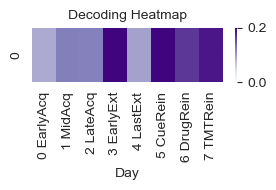

In [48]:
# ### HEATMAP FOR THE DATA PLOTTED ABOVE ###
# ### FIGURE SETTINGS ###

data_for_heatmap = 'mean' ### 'mean' or 'zscore' or 'ttest'

if data_for_heatmap == 'mean':
    heatcmin = 0.0
    heatcmax = 0.2

elif data_for_heatmap == 'zscore':
    heatcmin = 0.6
    heatcmax = 1.2
    
elif data_for_heatmap == 'ttest':
    heatcmin = -0.01
    heatcmax = 6

sns.set_style('white')

heatmap_array = np.nan*np.ones((len(days)))

for d, day in enumerate(sorted(days)):
    decoding_temp = decoding_day[day] - np.nanmean(decoding_shuffled_day[day])
    decoding_shuffled_temp = decoding_shuffled_day[day] - np.nanmean(decoding_shuffled_day[day])

    ttest = stats.ttest_rel(decoding_temp, decoding_shuffled_temp, nan_policy = 'omit')
    print(day, ttest)
    
    if data_for_heatmap == 'mean':
        heatmap_array[d] = np.nanmean(decoding_temp)

    elif data_for_heatmap == 'zscore':
        mean_shuffled_cluster = np.nanmean(decoding_shuffled_temp)
        std_shuffled_cluster = np.nanstd(decoding_temp)
        heatmap_array[d] = (np.nanmean(decoding_temp) - mean_shuffled_cluster) / std_shuffled_cluster

    elif data_for_heatmap == 'ttest':
        tvalue, pvalue = stats.ttest_ind(decoding_temp, decoding_shuffled_temp, nan_policy='omit')
        heatmap_array[d] = tvalue
        
heatmap_array = heatmap_array.reshape(1,len(days))
# Create the heatmap
plt.figure(figsize=(3, 2))
ax = sns.heatmap(heatmap_array, vmin=heatcmin, vmax=heatcmax, cmap='Purples')

xtick_labels = [day for day in sorted(days)]
ax.set_xticklabels(xtick_labels, rotation=90)

ax.set_xlabel('Day')
plt.title('Decoding Heatmap', fontsize=10)

# Adjust margins to prevent axis labels from being cut off
plt.tight_layout()

# fig.savefig(os.path.join(basedir, 'Results', 'Decoding_HeatMap_Days.PDF'), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', 'Decoding_HeatMap_Days.png'), format='PNG')

plt.show()


In [49]:
### CDF PLOTS FOR SPLIT BY RESPONSE TYPE (e.g., excited vs inhibited) ###
# Define response direction of each cluster for future separation
clusters_unclustered = [0]
clusters_excited = np.where(peak_responses > 0)[0]
clusters_inhibited = np.where(peak_responses < 0)[0]

response_types = 3

### CDF PLOTS FOR SPLIT BY CLUSTER ###
fig, axs = plt.subplots(response_types, len(days), figsize=(2.5*len(days), 1.5*response_types), sharex=True, sharey=False)
sns.set_style('white')

response_type_colors = [cluster_colors[0], cluster_colors[1], cluster_colors[-1]]

for d, day in enumerate(sorted(days)):   
    for response_type in range(response_types):
        if response_type == 0:
            decoding_temp = decoding_day[day][np.where(np.isin(clusterids_day[day], clusters_unclustered))] 
            decoding_shuffled_temp = decoding_shuffled_day[day][np.where(np.isin(clusterids_day[day], clusters_unclustered))]
        elif response_type == 1:
            decoding_temp = decoding_day[day][np.where(np.isin(clusterids_day[day], clusters_excited))] 
            decoding_shuffled_temp = decoding_shuffled_day[day][np.where(np.isin(clusterids_day[day], clusters_excited))]       
        elif response_type == 2:
            decoding_temp = decoding_day[day][np.where(np.isin(clusterids_day[day], clusters_inhibited))] 
            decoding_shuffled_temp = decoding_shuffled_day[day][np.where(np.isin(clusterids_day[day], clusters_inhibited))] 
        
        decoding_temp = decoding_temp - np.nanmean(decoding_shuffled_temp)
        decoding_shuffled_temp = decoding_shuffled_temp - np.nanmean(decoding_shuffled_temp)

        ax = axs[response_type, d]
        ax.hist(([decoding_temp, decoding_shuffled_temp]),  density=True, cumulative=True,\
            label = ['Actual','Shuffled'], histtype='step',\
            linestyle = ('-'), color = [response_type_colors[response_type], 'grey'], linewidth=1, bins=bins)
        ax.axvline(np.nanmean(decoding_shuffled_day[day]), linestyle='--', color='r', linewidth=1)
        ax.set_xlim(-0.3,0.6)
        ax.set_ylim(-0.05,1.05)
        if response_type == 0:
            ax.set_title(day)
    
        if response_type == 0 and d == 0:
            ax.set_ylabel('unclustered')
        elif response_type == 1 and d == 0:
            ax.set_ylabel('excited')
        elif response_type == 2 and d == 0:
            ax.set_ylabel('inhibited')

# fig.savefig(os.path.join(basedir, 'Results', 'Decoding_CDF_ResponseTypes.PDF'), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', 'Decoding_CDF_ResponseTypes.png'), format='PNG')

plt.close()



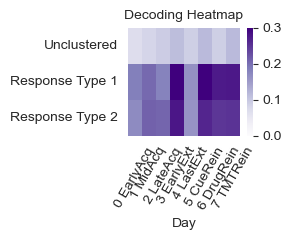

In [50]:
# ### HEATMAP FOR THE DATA PLOTTED ABOVE ###
# ### FIGURE SETTINGS ###

sns.set_style('white')

if data_for_heatmap == 'mean':
    heatcmin = 0
    heatcmax = 0.3

elif data_for_heatmap == 'zscore':
    heatcmin = 0.6
    heatcmax = 3
    
elif data_for_heatmap == 'ttest':
    heatcmin = -0.01
    heatcmax = 6
    
heatmap_array = np.nan*np.ones((response_types, len(days)))

for d, day in enumerate(sorted(days)):
    for rt in range(response_types):
        if rt == 0:
            decoding_temp = decoding_day[day][np.where(np.isin(clusterids_day[day], clusters_unclustered))] 
            decoding_shuffled_temp = decoding_shuffled_day[day][np.where(np.isin(clusterids_day[day], clusters_unclustered))]
        elif rt == 1:
            decoding_temp = decoding_day[day][np.where(np.isin(clusterids_day[day], clusters_excited))] 
            decoding_shuffled_temp = decoding_shuffled_day[day][np.where(np.isin(clusterids_day[day], clusters_excited))]       
        elif rt == 2:
            decoding_temp = decoding_day[day][np.where(np.isin(clusterids_day[day], clusters_inhibited))] 
            decoding_shuffled_temp = decoding_shuffled_day[day][np.where(np.isin(clusterids_day[day], clusters_inhibited))] 
        
        decoding_temp = decoding_temp - np.nanmean(decoding_shuffled_temp)
        decoding_shuffled_temp = decoding_shuffled_temp - np.nanmean(decoding_shuffled_temp)
        
        ttest = stats.ttest_rel(decoding_temp, decoding_shuffled_temp, nan_policy = 'omit')
#         print(day, rt, ttest)

        if data_for_heatmap == 'mean':
            heatmap_array[rt, d] = np.nanmean(decoding_temp)

        elif data_for_heatmap == 'zscore':
            mean_shuffled_cluster = np.nanmean(decoding_shuffled_temp)
            std_shuffled_cluster = np.nanstd(decoding_temp)
            heatmap_array[rt, d] = (np.nanmean(decoding_temp) - mean_shuffled_cluster) / std_shuffled_cluster

        elif data_for_heatmap == 'ttest':
            tvalue, pvalue = stats.ttest_ind(decoding_temp, decoding_shuffled_temp, nan_policy='omit')
            heatmap_array[rt, d] = tvalue

# Create the heatmap
plt.figure(figsize=(3, 2.5))
ax = sns.heatmap(heatmap_array, vmin=heatcmin, vmax=heatcmax, cmap='Purples')
xtick_labels = [day for day in sorted(days)]
ax.set_xticklabels(xtick_labels, rotation=60)
ytick_labels = ['Response Type {}'.format(rt) if rt > 0 else 'Unclustered' for rt in range(response_types)]
ax.set_yticklabels(ytick_labels, rotation=0)

ax.set_xlabel('Day')
plt.title('Decoding Heatmap', fontsize=10)

# Adjust margins to prevent axis labels from being cut off
plt.tight_layout()

# fig.savefig(os.path.join(basedir, 'Results', 'Decoding_HeatMap_ResponseTypes.PDF'), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', 'Decoding_HeatMap_ResponseTypes.png'), format='PNG')

plt.show()


In [51]:
### CDF PLOTS FOR SPLIT BY CLUSTER ###
fig, axs = plt.subplots(numclusters, len(days), figsize=(1.5*len(days), 1*numclusters), sharex=True, sharey=False)
sns.set_style('white')

for d, day in enumerate(sorted(days)):   
    for c in range(numclusters):
        decoding_temp = decoding_day[day][np.where(clusterids_day[day] == c)] 
        decoding_shuffled_temp = decoding_shuffled_day[day][np.where(clusterids_day[day] == c)] 
        
        decoding_temp = decoding_temp - np.nanmean(decoding_shuffled_temp)
        decoding_shuffled_temp = decoding_shuffled_temp - np.nanmean(decoding_shuffled_temp)
        
        ax = axs[c, d]
        ax.hist(([decoding_temp, decoding_shuffled_temp]),  density=True, cumulative=True,\
            label = ['Actual','Shuffled'], histtype='step',\
            linestyle = ('-'), color = [cluster_colors[c], 'grey'], linewidth=1, bins=bins)
        ax.axvline(np.nanmean(decoding_shuffled_day[day]), linestyle='--', color='r', linewidth=1)
        ax.set_xlim(-0.3,0.6)
        ax.set_ylim(-0.05,1.05)
        if c == 0:
            ax.set_title(day)
        if d == 0:
            ax.set_ylabel(f'Cluster {c}' if c > 0 else 'Unclustered')
        else:
            ax.set_yticks([])

# fig.savefig(os.path.join(basedir, 'Results', 'Decoding_CDF_Clusters.PDF'), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', 'Decoding_CDF_Clusters.png'), format='PNG')

plt.close()



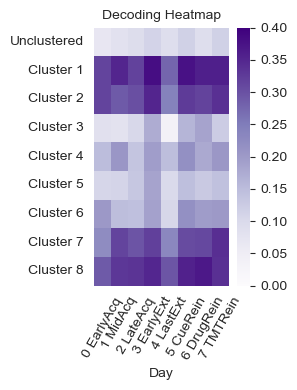

In [52]:
# ### HEATMAP SUMMARY, ANOVA, AND TUKEYS POSTHOCS FOR THE DATA PLOTTED ABOVE ###
# ### FIGURE SETTINGS ###

sns.set_style('white')

heatmap_array = np.nan*np.ones((numclusters, len(days)))

for d, day in enumerate(sorted(days)):
    for c in range(numclusters):
        decoding_temp = decoding_day[day][np.where(clusterids_day[day] == c)]
        decoding_shuffled_temp = decoding_shuffled_day[day][np.where(clusterids_day[day] == c)]
        
        decoding_temp = decoding_temp - np.nanmean(decoding_shuffled_temp)
        decoding_shuffled_temp = decoding_shuffled_temp - np.nanmean(decoding_shuffled_temp)
        
#         print(day, 'cluster = %s'%c, stats.ttest_rel(decoding_temp, decoding_shuffled_temp, nan_policy = 'omit'))

        if data_for_heatmap == 'mean':
            if np.count_nonzero(decoding_temp > -1) >= 2:
                heatmap_array[c, d] = np.nanmean(decoding_temp)

        elif data_for_heatmap == 'zscore':
            mean_shuffled_cluster = np.nanmean(decoding_shuffled_temp)
            std_shuffled_cluster = np.nanstd(decoding_temp)
            heatmap_array[c, d] = (np.nanmean(decoding_temp) - mean_shuffled_cluster) / std_shuffled_cluster

        elif data_for_heatmap == 'ttest':
            tvalue, pvalue = stats.ttest_ind(decoding_temp, decoding_shuffled_temp, nan_policy='omit')
            heatmap_array[c, d] = tvalue

# Create the heatmap
plt.figure(figsize=(3, 4))
ax = sns.heatmap(heatmap_array, vmin=0, vmax=0.4, cmap='Purples')
xtick_labels = [day for day in sorted(days)]
ax.set_xticklabels(xtick_labels, rotation=60)
ytick_labels = ['Cluster {}'.format(c) if c > 0 else 'Unclustered' for c in range(numclusters)]
ax.set_yticklabels(ytick_labels, rotation=0)

ax.set_xlabel('Day')
plt.title('Decoding Heatmap', fontsize=10)

# Adjust margins to prevent axis labels from being cut off
plt.tight_layout()

# fig.savefig(os.path.join(basedir, 'Results', 'Decoding_HeatMap_Clusters.PDF'), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', 'Decoding_HeatMap_Clusters.png'), format='PNG')

plt.show()



# SPIKE INFERENCE (FIRST USE CASCADE CO-LAB CODE TO CREATE SPIKE PREDICTIONS)

In [437]:
### DEFINE THESE VARIABLES FOR CREATING SPIKE PREDICTION MEASUREMENTS

save_cascade_measures = 'yes' #'yes' to save new cascade measures. 'no' to load saved data for each FOV

dataset = 'baseline' #'baseline' or 'behavior' sessions?

# Define the start and end times to analyze (in minutes)
if dataset == 'baseline':
    startmin = 0 #start time in minutes
    endmin = 5 #end time in minutes
elif dataset == 'behavior':
    startmin = 0 #start time in minutes
    endmin = 120 #end time in minutes

window_predictions = [int(startmin*averagedframerate*60), int(endmin*averagedframerate*60)]
window_frames = window_predictions[1]-window_predictions[0]

### SELECTS ALL DAYS WITHIN A DIRECTORY. HAVE TO REDO THIS BECAUSE OF LIMITED DAY SAMPLING IN DECODING ABOVE###
tempdays = next(os.walk(os.path.join(basedir)))[1]
days = []
for t in tempdays:
    if t!= 'Cascade' and t!= 'CellTracking' and t!= 'Codes' and t != '.ipynb_checkpoints' and t != 'Other' and t!= 'Results':
        days = np.append(days, t)
numdays = len(days)




In [438]:
### IF SAVING CASCADE MEASURES, FIRST LOAD YOUR SPIKE PREDICTIONS DATA SO THAT YOU CAN QUANTIFY EACH MEASURE 
if save_cascade_measures == 'yes':
    predictions_fov = {}
    for basedir, day, animal, fov in iterate_dirs(basedir, sorted(days)):
        tempfiles = next(os.walk(os.path.join(basedir, day, animal, fov)))[2]
        if day not in predictions_fov:
            predictions_fov[day] = {}
        if animal not in predictions_fov[day]:
            predictions_fov[day][animal] = {}
        if dataset == 'baseline':
            try:
                predictions_fov[day][animal][fov] = \
                                np.load(os.path.join(basedir, day, animal, fov, 'baseline_predictions.npy'))[:, window_predictions[0]:window_predictions[1]]
            except FileNotFoundError:
                print('No baseline data for: ', basedir, day, animal, fov)
                continue
        if dataset == 'behavior':
            try:
                predictions_fov[day][animal][fov] = \
                                np.load(os.path.join(basedir, day, animal, fov, 'behavior_predictions.npy'))[:, window_predictions[0]:window_predictions[1]]
            except FileNotFoundError:
                print('No behavior data for: ', day, animal, fov)
                continue
# No baseline data for:  0 EarlyAcq PGa-T1 FOV1
# No baseline data for:  1 MidAcq ER-L2 FOV2
# No baseline data for:  2 LateAcq ER-L1 FOV2
# 3 EarlyExt CTL1 FOV1
# (121, 2250)
# No baseline data for:  3 EarlyExt ER-L1 FOV1
# 3 EarlyExt ER-L2 FOV1
# (106, 2250)
# 3 EarlyExt IG-19 FOV2
# (56, 2250)
# 3 EarlyExt LCDD-PGa-T1 FOV1
# (118, 2250)
# 3 EarlyExt LCDD-PGa-T2 FOV1
# (135, 2250)
# 3 EarlyExt LCDD-PGa-T3 FOV1
# (103, 2250)
# 3 EarlyExt LCDD-PGa-T4 FOV1
# (123, 2250)
# 3 EarlyExt LCDD-PGa-T5 FOV1
# (203, 2250)
# 3 EarlyExt LCDD-PGa1 FOV1
# (19, 2250)
# 3 EarlyExt LCDD-PGa3 FOV1
# (230, 2250)
# 3 EarlyExt LCDD-PGa4 FOV1
# (70, 2250)
# 3 EarlyExt LCDD-PGa5 FOV1
# (259, 2250)
# 3 EarlyExt LCDD-PGa6 FOV1
# (112, 2250)
# 3 EarlyExt PGa-T1 FOV1
# (153, 2250)
# 3 EarlyExt PGa-T2 FOV1
# (109, 2250)
# 3 EarlyExt PGa-T3 FOV1
# (110, 2250)
# No baseline data for:  4 LastExt IG-19 FOV1
# No baseline data for:  6 DrugRein LCDD-PGa4 FOV1_tracked

No baseline data for:  /Users/jmo204/Dropbox/2P Imaging Projects/Jim/PFC Self Admin Analysis July 2024 0 EarlyAcq PGa-T1 FOV1
No baseline data for:  /Users/jmo204/Dropbox/2P Imaging Projects/Jim/PFC Self Admin Analysis July 2024 1 MidAcq ER-L2 FOV2
No baseline data for:  /Users/jmo204/Dropbox/2P Imaging Projects/Jim/PFC Self Admin Analysis July 2024 2 LateAcq ER-L1 FOV2
No baseline data for:  /Users/jmo204/Dropbox/2P Imaging Projects/Jim/PFC Self Admin Analysis July 2024 3 EarlyExt ER-L1 FOV1
No baseline data for:  /Users/jmo204/Dropbox/2P Imaging Projects/Jim/PFC Self Admin Analysis July 2024 6 DrugRein LCDD-PGa4 FOV1_tracked


In [439]:
for key1 in predictions_fov.keys():
    for key2 in predictions_fov[key1].keys():
        for key3 in predictions_fov[key1][key2].keys():
            print({key1},{key2},{key3})

{'0 EarlyAcq'} {'CTL1'} {'FOV1'}
{'0 EarlyAcq'} {'ER-L1'} {'FOV1'}
{'0 EarlyAcq'} {'ER-L2'} {'FOV1'}
{'0 EarlyAcq'} {'IG-19'} {'FOV2'}
{'0 EarlyAcq'} {'LCDD-PGa-T1'} {'FOV1'}
{'0 EarlyAcq'} {'LCDD-PGa-T2'} {'FOV1'}
{'0 EarlyAcq'} {'LCDD-PGa-T3'} {'FOV1'}
{'0 EarlyAcq'} {'LCDD-PGa-T4'} {'FOV1'}
{'0 EarlyAcq'} {'LCDD-PGa-T5'} {'FOV1'}
{'0 EarlyAcq'} {'LCDD-PGa1'} {'FOV1'}
{'0 EarlyAcq'} {'LCDD-PGa3'} {'FOV1'}
{'0 EarlyAcq'} {'LCDD-PGa4'} {'FOV1'}
{'0 EarlyAcq'} {'LCDD-PGa5'} {'FOV1'}
{'0 EarlyAcq'} {'LCDD-PGa6'} {'FOV1'}
{'0 EarlyAcq'} {'PGa-T2'} {'FOV1'}
{'0 EarlyAcq'} {'PGa-T3'} {'FOV1'}
{'1 MidAcq'} {'CTL1'} {'FOV1'}
{'1 MidAcq'} {'ER-L1'} {'FOV1'}
{'1 MidAcq'} {'IG-19'} {'FOV2'}
{'1 MidAcq'} {'LCDD-PGa-T1'} {'FOV1'}
{'1 MidAcq'} {'LCDD-PGa-T2'} {'FOV1'}
{'1 MidAcq'} {'LCDD-PGa-T3'} {'FOV1'}
{'1 MidAcq'} {'LCDD-PGa-T4'} {'FOV1'}
{'1 MidAcq'} {'LCDD-PGa-T5'} {'FOV1'}
{'1 MidAcq'} {'LCDD-PGa1'} {'FOV1'}
{'1 MidAcq'} {'LCDD-PGa3'} {'FOV1'}
{'1 MidAcq'} {'LCDD-PGa4'} {'FOV1'}
{'1 MidAcq'}

In [440]:
### IF SAVING CASCADE MEASURES, DEFINE YOUR FUNCTION FOR CALCULATING AND EXTRACTING EACH MEASURE FROM EACH DATASET (E.G., EACH FOV)
def calculate_cascade_measures(data):
    numneurons = data.shape[0]
    cascade_measures = np.nan*np.ones((numneurons, 9))
    for neuron in range(numneurons):
        predictions_neuron = data[neuron, :] 
        
        if np.all(np.isnan(predictions_neuron)) == False:
            
            # Calculate basal firing properties for each neuron (basal firing rate, mean firing rate, maximum spike rate)
            basalfiring_neuron = np.nanquantile(predictions_neuron, 0.25)
            meanfiring_neuron = np.nanmean(predictions_neuron)
            maxfiring_neuron = np.nanmax(predictions_neuron)
            
            # Find spike bursts for each neuron
            predictions_subtracted = predictions_neuron-basalfiring_neuron
            burst_frames, burst_dict = find_peaks(predictions_subtracted,\
                    distance = averagedframerate, width = (3.5, 3*averagedframerate), height = (1.75))  # Find frame number for bursts
            
            # Calculate burst firing properties for each neuron (basal firing rate, mean firing rate, maximum spike rate)
            burstfreq_neuron = np.nanmean(len(burst_frames)/np.count_nonzero(predictions_neuron >= 0)*averagedframerate) # Get the frequency of bursts
            burstisi_neuron = np.nanmean(np.diff(burst_frames))/averagedframerate # Get the average inter-burst-intervals between bursts
            burstamp_neuron = np.nanmean(predictions_neuron[burst_frames])  # Get the average peak amplitude of bursts
            burstampchange_neuron = np.nanmean(burst_dict['width_heights'])
            burstwidth_neuron = np.nanmean(burst_dict['widths']/averagedframerate)
            signalnoise_neuron = ((burstamp_neuron*burstfreq_neuron)/(basalfiring_neuron))
            
            # Insert each calculation into "cascade_measures" array
            cascade_measures_neuron = [basalfiring_neuron, meanfiring_neuron, maxfiring_neuron, \
                                       burstfreq_neuron, burstisi_neuron, burstamp_neuron, burstampchange_neuron, \
                                       burstwidth_neuron, signalnoise_neuron]
            cascade_measures[neuron, :] = cascade_measures_neuron
        
        else:
            continue
            
    return cascade_measures
    

In [441]:
### SAVE OR LOAD CASCADE MEASURES FOR ALL CELLS. CREATE DICTIONARY ARRAYS FOR EACH FOV AND EACH DAY.
cascade_measures_fov = {}
cascade_measures_day = {}

for basedir, day, animal, fov in iterate_dirs(basedir, sorted(days)):
    tempfiles = next(os.walk(os.path.join(basedir, day, animal, fov)))[2]
    
    if day not in cascade_measures_fov:
        cascade_measures_day[day] = np.nan*np.ones((1, 9))
        cascade_measures_fov[day] = {}

    if animal not in cascade_measures_fov[day]:
        cascade_measures_fov[day][animal] = {}
        cascade_measures_fov[day][animal] = {}
        
    if fov not in cascade_measures_fov[day][animal]:
        
        ### SAVE CASCADE MEASURES FOR EACH FOV
        if save_cascade_measures == 'yes':
            try:
                cascade_measures_fov[day][animal][fov] = calculate_cascade_measures(predictions_fov[day][animal][fov])
                np.save(os.path.join(basedir, day, animal, fov, 'cascade_measures_%s.npy'%dataset), cascade_measures_fov[day][animal][fov])
            except KeyError:
                continue
        
        ### LOAD CASCADE MEASURES FOR EACH FOV
        try:
            cascade_measures_fov[day][animal][fov] = np.load(os.path.join(basedir, day, animal, fov, 'cascade_measures_%s.npy'%dataset))

        except FileNotFoundError:
            continue
                
        # Stack Cascade Measures From Each FOV For Each Day
        cascade_measures_day[day] = np.vstack((cascade_measures_day[day], cascade_measures_fov[day][animal][fov]))
            

for day in sorted(days):
    cascade_measures_day[day] = cascade_measures_day[day][1:, :]
               


In [442]:
### NOW THAT WE'VE SAVED/LOADED DATA, WE ARE READY TO PLOT
plot_by_subtraction = 'yes' #Plot data as a change from day 1 ('yes')?
daysforbaselines = sorted(days)[:6]


0 EarlyAcq (2106,)
1 MidAcq (2493,)
2 LateAcq (2000,)
3 EarlyExt (2027,)
4 LastExt (2198,)
5 CueRein (2192,)


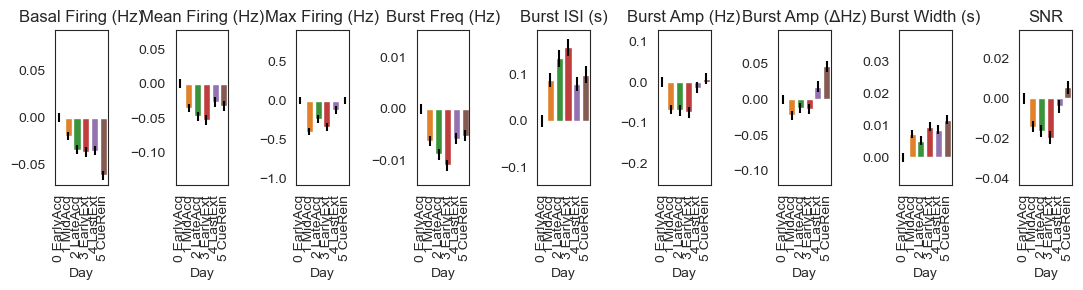

In [542]:
### PLOT CASCADE MEASURES AS BAR GRAPHS FOR EACH DAY ###
measurements = ['Basal Firing (Hz)', 'Mean Firing (Hz)', 'Max Firing (Hz)', 'Burst Freq (Hz)', \
                'Burst ISI (s)', 'Burst Amp (Hz)', 'Burst Amp (ΔHz)', 'Burst Width (s)', 'SNR']

fig, axs = plt.subplots(1, len(measurements), figsize=(11, 3))

for m, measurement in enumerate(measurements):
    # Calculate means and SEMs for each day
    means = []
    sems = []
    all_values = []
    
    for day in sorted(daysforbaselines):
        if plot_by_subtraction == 'yes':
            values = cascade_measures_day[day][:, m]-np.nanmean(cascade_measures_day['0 EarlyAcq'][:, m])
            if m == 0:
                print(day, np.shape(values))
        else:
            values = cascade_measures_day[day][:, m]
            
        means.append(np.nanmean(values))
        sems.append(stats.sem(values))
        all_values = np.append(all_values, values)

    # Create DataFrame for plotting
    plot_df = pd.DataFrame({'Day': sorted(daysforbaselines), 'Mean': means, 'SEM': sems})

    # Plot bar plot with error bars
    ax = axs[m]
    sns.barplot(x='Day', y='Mean', yerr=plot_df['SEM'], data=plot_df, ax=ax, capsize=0.2)
    ax.set_title(measurement)
    ax.set_xlabel('Day')
    ax.set_ylabel(None)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
   
    # Calculate min and max for binning data
    ax.set_ylim (np.nanquantile(all_values, 0.4), np.nanquantile(all_values, 0.7))

plt.tight_layout()

# fig.savefig(os.path.join(basedir, 'Results', 'CascadeMeasures.PDF'), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', 'CascadeMeasures.png'), format='PNG')

plt.show()


In [549]:
#Correlate average FOV changes in Cascade Measures with Behavior

### EXTRACT LEVER PRESSES FOR EACH ANIMAL
active_presses_animal = {}
activetimeout_presses_animal = {}
activeall_presses_animal = {}
for basedir, day, animal, fov in iterate_dirs(basedir, sorted(days)):
    if day not in active_presses_animal:
        active_presses_animal[day] = {}
        activetimeout_presses_animal[day] = {}
        activeall_presses_animal[day] = {}
    active_presses_animal[day][animal], activetimeout_presses_animal[day][animal] = analyze_single_session(os.path.join(basedir, day, animal, fov), 'window_size', 'pre_window_size')
    activeall_presses_animal[day][animal] = np.sort(np.hstack((active_presses_animal[day][animal], activetimeout_presses_animal[day][animal])))
    print(day, animal, fov, len(active_presses_animal[day][animal]), len(activetimeout_presses_animal[day][animal]), len(activeall_presses_animal[day][animal]))

0 EarlyAcq CTL1 FOV1 10 2 12
0 EarlyAcq ER-L1 FOV1 10 6 16
0 EarlyAcq ER-L2 FOV1 9 7 16
0 EarlyAcq IG-19 FOV2 13 73 86
0 EarlyAcq LCDD-PGa-T1 FOV1 6 1 7
0 EarlyAcq LCDD-PGa-T2 FOV1 10 27 37
0 EarlyAcq LCDD-PGa-T3 FOV1 10 12 22
0 EarlyAcq LCDD-PGa-T4 FOV1 10 16 26
0 EarlyAcq LCDD-PGa-T5 FOV1 11 5 16
0 EarlyAcq LCDD-PGa1 FOV1 10 7 17
0 EarlyAcq LCDD-PGa3 FOV1 10 8 18
0 EarlyAcq LCDD-PGa4 FOV1 10 3 13
0 EarlyAcq LCDD-PGa5 FOV1 10 6 16
0 EarlyAcq LCDD-PGa6 FOV1 10 15 25
0 EarlyAcq PGa-T1 FOV1 12 15 27
0 EarlyAcq PGa-T2 FOV1 10 9 19
0 EarlyAcq PGa-T3 FOV1 10 8 18
1 MidAcq CTL1 FOV1 32 50 82
1 MidAcq ER-L1 FOV1 40 97 137
1 MidAcq ER-L2 FOV2 51 128 179
1 MidAcq IG-19 FOV2 40 80 120
1 MidAcq LCDD-PGa-T1 FOV1 41 153 194
1 MidAcq LCDD-PGa-T2 FOV1 43 307 350
1 MidAcq LCDD-PGa-T3 FOV1 40 89 129
1 MidAcq LCDD-PGa-T4 FOV1 40 264 304
1 MidAcq LCDD-PGa-T5 FOV1 17 25 42
1 MidAcq LCDD-PGa1 FOV1 33 84 117
1 MidAcq LCDD-PGa3 FOV1 11 6 17
1 MidAcq LCDD-PGa4 FOV1 10 17 27
1 MidAcq LCDD-PGa5 FOV1 12 15 27
1 

5 CueRein CTL1 55
5 CueRein ER-L1 241
5 CueRein ER-L2 53
5 CueRein IG-19 49
5 CueRein LCDD-PGa-T1 148
5 CueRein LCDD-PGa-T2 466
5 CueRein LCDD-PGa-T3 173
5 CueRein LCDD-PGa-T4 73
5 CueRein LCDD-PGa-T5 47
5 CueRein LCDD-PGa1 324
5 CueRein LCDD-PGa3 51
5 CueRein LCDD-PGa4 50
5 CueRein LCDD-PGa5 78
5 CueRein LCDD-PGa6 42
5 CueRein PGa-T2 87
5 CueRein PGa-T3 429
(16,) (16,)
Correlation,  Basal Firing (Hz) : SignificanceResult(statistic=0.4205882352941176, pvalue=0.10476751392918707)
(16,) (16,)
Correlation,  Mean Firing (Hz) : SignificanceResult(statistic=0.4764705882352941, pvalue=0.062059174189226164)
(16,) (16,)
Correlation,  Max Firing (Hz) : SignificanceResult(statistic=0.3323529411764706, pvalue=0.2084998279822084)
(16,) (16,)
Correlation,  Burst Freq (Hz) : SignificanceResult(statistic=0.5735294117647058, pvalue=0.02019103804652309)
(16,) (16,)
Correlation,  Burst ISI (s) : SignificanceResult(statistic=-0.5882352941176471, pvalue=0.016539722195378165)
(16,) (16,)
Correlation,  Burst

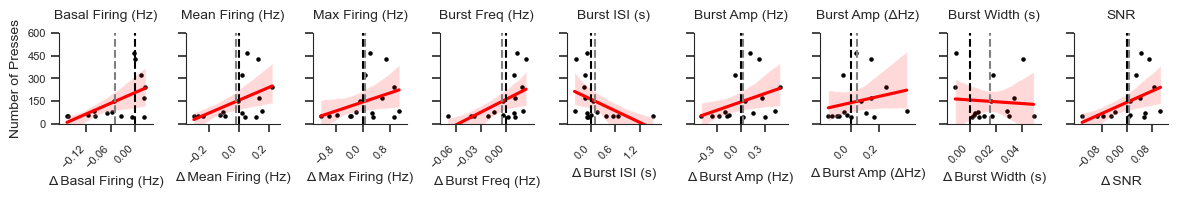

In [552]:
### CORRELATE PRESSES TO CHANGES IN TRACKED!!! CASCADE MEASUREMENTS. DOES SO BY TAKING THE ***AVERAGE*** TRACKED!!! NEURONAL CMEASURE FOR CUE REIN, SUBTRACTING DAY EARLY ACQ, 
### AND CORRELATING TO PRESSES ON EACH REFERENCE DAY
fig, axs = plt.subplots(1, len(measurements), figsize=(12, 1.8), sharey='col')
reference_days = ['5 CueRein']
cmeasures_press_array = np.nan*np.ones((1, len(measurements)+1))

# --- REFACTORED DATA COLLECTION ---

# Get the list of animals from Day 1. We'll loop through these.
try:
    animals = list(cascade_measures_fov['0 EarlyAcq'].keys())
except KeyError:
    print("Error: '0 EarlyAcq' not found in cascade_measures_fov. Stopping.")
    animals = [] # Set to empty list to skip loop

for animal in animals:
    try:
        # --- 1. Get Day 1 (EarlyAcq) Data ---
        # Get the FOV dictionary for this animal (e.g., {'FOV1': [...]})
        day1_fov_dict = cascade_measures_fov['0 EarlyAcq'][animal]
        
        # Per your note, there's only one FOV. Let's grab its name.
        if len(day1_fov_dict) != 1:
            print(f"Warning: Animal {animal} has {len(day1_fov_dict)} FOVs on Day 0. Skipping.")
            continue
        
        # Get the single FOV name (e.g., 'FOV1')
        fov_day1 = list(day1_fov_dict.keys())[0]
        mean_day1 = np.nanmean(day1_fov_dict[fov_day1][:, :], axis=0)


        # --- 2. Get Day 5 (CueRein) Data ---
        # Get the FOV dictionary for this animal (e.g., {'FOV1_tracked': [...]})
        day5_fov_dict = cascade_measures_fov['5 CueRein'][animal]
        
        if len(day5_fov_dict) != 1:
            print(f"Warning: Animal {animal} has {len(day5_fov_dict)} FOVs on Day 5. Skipping.")
            continue
            
        # Get the single FOV name (e.g., 'FOV1_tracked')
        fov_day5 = list(day5_fov_dict.keys())[0]
        mean_day5 = np.nanmean(day5_fov_dict[fov_day5][:, :], axis=0)

        # --- 3. Calculate Change ---
        # This (Day 5 - Day 1) change is the static value we'll correlate against
        change_cmeasures = mean_day5 - mean_day1

        # --- 4. Get presses for EACH reference day and build the array ---
        for day in reference_days:
            try:
                # Get presses for the specific day (Day 5, 6, or 7)
                num_presses = np.shape(activeall_presses_animal[day][animal])[0]
                print(day, animal, num_presses)
                
                # Stack the (Day5-Day1) change with the presses from the current 'day'
                animal_array = np.hstack((change_cmeasures, num_presses))
                cmeasures_press_array = np.vstack((cmeasures_press_array, animal_array))
                
            except KeyError:
                # This animal might be missing press data for this specific day
                print(f"Warning: Missing press data for {animal} on {day}. Skipping this day.")
                continue

    except KeyError as e:
        # This animal is missing from a key day (e.g., '0 EarlyAcq' or '5 CueRein' in cascade_measures_fov)
        print(f"Warning: Missing critical data for {animal} (e.g., in {e.args[0]}). Skipping animal.")
        continue
    except (AttributeError, TypeError, ValueError):
         # Catches errors from np.nanmean if data is empty or malformed
        print(f"Warning: Data processing error for {animal} (e.g., empty array). Skipping animal.")
        continue

# --- END OF REFACTORED BLOCK ---

cmeasures_press_array = cmeasures_press_array[1:, :]

for m, measurement in enumerate(measurements):
    nan_mask = np.any(np.isnan(cmeasures_press_array), axis = 1)
    ax = axs[m]
    ax.scatter(x = cmeasures_press_array[:, m][~nan_mask], y = cmeasures_press_array[:, -1][~nan_mask], s = 5, color = 'k')
    print(np.shape(cmeasures_press_array[:, m][~nan_mask]), np.shape(cmeasures_press_array[:, -1][~nan_mask]))
    sns.regplot(x = cmeasures_press_array[:, m][~nan_mask], y = cmeasures_press_array[:, -1][~nan_mask], ax = ax, color = 'r', scatter = False)
    ax.axvline(np.nanmean(cmeasures_press_array[:, m]), color = 'gray', linestyle = '--')
    ax.axvline(0, color = 'black', linestyle = '--')
        
    # Set y-axis ticks for publication format
    ax.set_ylim(0, 600)
    ax.set_yticks([0, 150, 300, 450, 600])
    
    # Set x-axis ticks based on data range
    x_data = cmeasures_press_array[:, m][~nan_mask]
    if len(x_data) > 0:  # Only set ticks if there's valid data
        x_min, x_max = np.min(x_data), np.max(x_data)
        x_range = x_max - x_min
        
        # Create approximately 3-4 ticks across the data range (fewer to avoid overlap)
        if x_range > 0:
            tick_spacing = x_range / 3
            # Round tick spacing to a nice number
            magnitude = 10 ** np.floor(np.log10(tick_spacing))
            nice_spacing = magnitude * np.round(tick_spacing / magnitude)
            
            if nice_spacing == 0: # Avoid division by zero if range is tiny
                nice_spacing = magnitude if magnitude > 0 else 1
                
            # Generate ticks
            first_tick = np.ceil(x_min / nice_spacing) * nice_spacing
            last_tick = np.floor(x_max / nice_spacing) * nice_spacing
            
            # Ensure at least two ticks if possible
            if first_tick > last_tick:
                x_ticks = [x_min, x_max]
            else:
                x_ticks = np.arange(first_tick, last_tick + nice_spacing/2, nice_spacing)
                
            ax.set_xticks(x_ticks)
            ax.set_xlim(x_min - 0.1 * x_range, x_max + 0.1 * x_range)
            
            # Rotate x-tick labels to avoid overlap
            plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    if m > 0:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel('Number of Presses', fontsize=10)
        
    ax.set_xlabel(f'Δ {measurement}', fontsize=10)
    ax.set_title(measurement, fontsize=10, pad=10)
    
    # Format tick labels and marks - make sure ticks are visible
    ax.tick_params(axis='both', which='major', labelsize=8, direction='out', length=6, width=1.2, top=False, right=False, left=True, bottom=True)
    ax.tick_params(axis='x', which='major', pad=8) # Add padding for x-axis labels
    
    # Ensure spines are visible
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    nan_mask = np.any(np.isnan(cmeasures_press_array), axis = 1) # Recalculate mask just in case
    x_valid = cmeasures_press_array[:, m][~nan_mask]
    y_valid = cmeasures_press_array[:, -1][~nan_mask]
    
    if len(x_valid) > 1 and len(y_valid) > 1:
        print('Correlation, ', measurement, ':', stats.spearmanr(x_valid, y_valid))
    else:
        print(f'Correlation, {measurement} : Not enough data to correlate')
        
        
# Adjust layout with more spacing for x-axis labels
fig.tight_layout(pad=1.5)
plt.subplots_adjust(bottom=0.25) # Make room for x-axis labels

# fig.savefig(os.path.join(basedir, 'Results', 'CMeasures X Behavior.PDF'), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', 'CMeasures X Behavior.png'), format='PNG')
plt.show()

# Warning: Missing press data for LCDD-PGa5 on 6 DrugRein. Skipping this day.
# Warning: Missing press data for LCDD-PGa5 on 7 TMTRein. Skipping this day.
# Warning: Animal PGa-T1 has 0 FOVs on Day 0. Skipping.
# Correlation,  Basal Firing (Hz) : SignificanceResult(statistic=0.45739424577928955, pvalue=0.0013942517499363944)
# Correlation,  Mean Firing (Hz) : SignificanceResult(statistic=0.48328565201834955, pvalue=0.0006684643254152151)
# Correlation,  Max Firing (Hz) : SignificanceResult(statistic=0.38503425364100957, pvalue=0.008234688576345918)
# Correlation,  Burst Freq (Hz) : SignificanceResult(statistic=0.4792072920857053, pvalue=0.000753425924996003)
# Correlation,  Burst ISI (s) : SignificanceResult(statistic=-0.4221102530286851, pvalue=0.0034777213453933502)
# Correlation,  Burst Amp (Hz) : SignificanceResult(statistic=0.355744214124746, pvalue=0.015252295274339715)
# Correlation,  Burst Amp (ΔHz) : SignificanceResult(statistic=0.3276900412547382, pvalue=0.02620784091410742)
# Correlation,  Burst Width (s) : SignificanceResult(statistic=-0.037508552713865, pvalue=0.8045357529788639)
# Correlation,  SNR : SignificanceResult(statistic=0.37669215377878257, pvalue=0.009869678155371505)

Correlation,  Basal Firing (Hz) : SignificanceResult(statistic=0.4087010999168091, pvalue=0.004802848591117876)
Correlation,  Mean Firing (Hz) : SignificanceResult(statistic=0.4374967927745703, pvalue=0.0023623090669803717)
Correlation,  Max Firing (Hz) : SignificanceResult(statistic=0.3254654812914777, pvalue=0.02730402259983392)
Correlation,  Burst Freq (Hz) : SignificanceResult(statistic=0.561145250732468, pvalue=4.9758143045144415e-05)
Correlation,  Burst ISI (s) : SignificanceResult(statistic=-0.5207324113999018, pvalue=0.00020723709908608258)
Correlation,  Burst Amp (Hz) : SignificanceResult(statistic=0.3414081610281781, pvalue=0.020229152404543028)
Correlation,  Burst Amp (ΔHz) : SignificanceResult(statistic=0.1741954037897618, pvalue=0.24693966432309375)
Correlation,  Burst Width (s) : SignificanceResult(statistic=-0.15059035084627512, pvalue=0.31781569116259445)
Correlation,  SNR : SignificanceResult(statistic=0.36179996069139964, pvalue=0.013486812495700027)


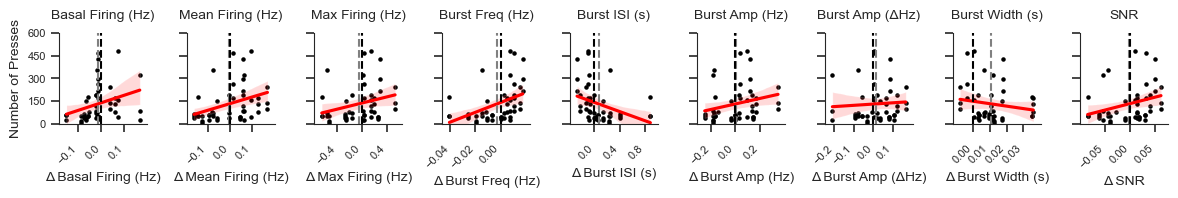

In [446]:
# (Imports go here: numpy, matplotlib, seaborn, stats, os)

fig, axs = plt.subplots(1, len(measurements), figsize=(12, 1.8), sharey='col')

# --- DAY DEFINITIONS ---
baseline_day = '0 EarlyAcq'
# Days to average for the X-axis (neuronal change)
acq_ext_days = ['1 MidAcq', '2 LateAcq', '3 EarlyExt', '4 LateExt', '5 CueRein']
# Days to get presses from for the Y-axis (behavior)
reference_days_behavior = ['5 CueRein', '6 DrugRein', '7 TMTRein']

cmeasures_press_array = np.nan*np.ones((1, len(measurements)+1))

# --- REFACTORED DATA COLLECTION ---

try:
    # Get animal list from the baseline day's dictionary
    animals = list(cascade_measures_fov[baseline_day].keys())
except KeyError:
    print(f"Error: Baseline day '{baseline_day}' not found in cascade_measures_fov. Stopping.")
    animals = [] # Set to empty list to skip loop

for animal in animals:
    try:
        # --- 1. Get Baseline (Day 0) Data ---
        
        # This gets the animal-specific dict: {'FOV1': [data]}
        fov_dict_day0 = cascade_measures_fov[baseline_day][animal] 
        
        if len(fov_dict_day0) != 1:
#             print(f"Warning: Animal {animal} has {len(fov_dict_day0)} FOVs on {baseline_day}. Skipping animal.")
            continue
        
        # This gets the fov *name*: 'FOV1'
        fov_name_day0 = list(fov_dict_day0.keys())[0]
        
        # This accesses cascade_measures_fov[baseline_day][animal][fov_name_day0]
        mean_day0 = np.nanmean(fov_dict_day0[fov_name_day0][:, :], axis=0)

        # --- 2. Get Data for Days 1-5 and Average Them ---
        all_day_means = np.nan*np.ones((len(acq_ext_days), len(measurements)))
        
        day_found_flag = False
        for i, day in enumerate(acq_ext_days):
            try:
                # Get the animal-specific dict for this day: {'FOV1_tracked': [data]}
                fov_dict_current_day = cascade_measures_fov[day][animal] 
                
                if len(fov_dict_current_day) != 1:
#                     print(f"Warning: Animal {animal} has {len(fov_dict_current_day)} FOVs on {day}. Skipping this day.")
                    continue 
                
                # Get the fov *name* for this day: 'FOV1_tracked'
                fov_name_current = list(fov_dict_current_day.keys())[0]
                
                # Accesses cascade_measures_fov[day][animal][fov_name_current]
                day_mean = np.nanmean(fov_dict_current_day[fov_name_current][:, :], axis=0)
                all_day_means[i, :] = day_mean
                day_found_flag = True

            except KeyError:
                # This animal is missing cascade data for this day
#                 print(f"Warning: Missing cascade data for {animal} on {day}. Skipping this day.")
                continue # This day will remain NaN
        
        if not day_found_flag:
#             print(f"Warning: Animal {animal} had no data for any day in {acq_ext_days}. Skipping animal.")
            continue
            
        # Calculate the average across all found days (ignoring NaNs)
        mean_of_acq_ext_days = np.nanmean(all_day_means, axis=0)
        
        # --- 3. Calculate Change (New X-axis value) ---
        change_cmeasures = mean_of_acq_ext_days - mean_day0

        # --- 4. Get presses for EACH reference day (Y-axis value) ---
        for day in reference_days_behavior:
            try:
                # This structure seems to be [day][animal]
                num_presses = np.shape(activeall_presses_animal[day][animal])[0]
                
                animal_array = np.hstack((change_cmeasures, num_presses))
                cmeasures_press_array = np.vstack((cmeasures_press_array, animal_array))
                
            except KeyError:
#                 print(f"Warning: Missing press data for {animal} on {day}. Skipping this day.")
                continue

    except KeyError as e:
        # This animal is missing from a key day (e.g., baseline_day)
#         print(f"Warning: Missing critical data for {animal} (e.g., in {e.args[0]}). Skipping animal.")
        continue
    except (AttributeError, TypeError, ValueError) as e:
         # Catches errors from np.nanmean if data is empty or malformed
#         print(f"Warning: Data processing error for {animal}. Error: {e}. Skipping animal.")
        continue

# --- END OF REFACTORED BLOCK ---

cmeasures_press_array = cmeasures_press_array[1:, :]

for m, measurement in enumerate(measurements):
    nan_mask = np.any(np.isnan(cmeasures_press_array), axis = 1)
    ax = axs[m]
    ax.scatter(x = cmeasures_press_array[:, m][~nan_mask], y = cmeasures_press_array[:, -1][~nan_mask], s = 5, color = 'k')
    sns.regplot(x = cmeasures_press_array[:, m][~nan_mask], y = cmeasures_press_array[:, -1][~nan_mask], ax = ax, color = 'r', scatter = False)
    ax.axvline(np.nanmean(cmeasures_press_array[:, m]), color = 'gray', linestyle = '--')
    ax.axvline(0, color = 'black', linestyle = '--')
        
    # Set y-axis ticks for publication format
    ax.set_ylim(0, 600)
    ax.set_yticks([0, 150, 300, 450, 600])
    
    # Set x-axis ticks based on data range
    x_data = cmeasures_press_array[:, m][~nan_mask]
    if len(x_data) > 0:  # Only set ticks if there's valid data
        x_min, x_max = np.min(x_data), np.max(x_data)
        x_range = x_max - x_min
        
        # Create approximately 3-4 ticks across the data range (fewer to avoid overlap)
        if x_range > 0:
            tick_spacing = x_range / 3
            # Round tick spacing to a nice number
            magnitude = 10 ** np.floor(np.log10(tick_spacing))
            nice_spacing = magnitude * np.round(tick_spacing / magnitude)
            
            if nice_spacing == 0: # Avoid division by zero if range is tiny
                nice_spacing = magnitude if magnitude > 0 else 1
                
            # Generate ticks
            first_tick = np.ceil(x_min / nice_spacing) * nice_spacing
            last_tick = np.floor(x_max / nice_spacing) * nice_spacing
            
            # Ensure at least two ticks if possible
            if first_tick > last_tick:
                x_ticks = [x_min, x_max]
            else:
                x_ticks = np.arange(first_tick, last_tick + nice_spacing/2, nice_spacing)
                
            ax.set_xticks(x_ticks)
            ax.set_xlim(x_min - 0.1 * x_range, x_max + 0.1 * x_range)
            
            # Rotate x-tick labels to avoid overlap
            plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    if m > 0:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel('Number of Presses', fontsize=10)
        
    ax.set_xlabel(f'Δ {measurement}', fontsize=10)
    ax.set_title(measurement, fontsize=10, pad=10)
    
    # Format tick labels and marks - make sure ticks are visible
    ax.tick_params(axis='both', which='major', labelsize=8, direction='out', length=6, width=1.2, top=False, right=False, left=True, bottom=True)
    ax.tick_params(axis='x', which='major', pad=8) # Add padding for x-axis labels
    
    # Ensure spines are visible
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    nan_mask = np.any(np.isnan(cmeasures_press_array), axis = 1) # Recalculate mask just in case
    x_valid = cmeasures_press_array[:, m][~nan_mask]
    y_valid = cmeasures_press_array[:, -1][~nan_mask]
    
    if len(x_valid) > 1 and len(y_valid) > 1:
        print('Correlation, ', measurement, ':', stats.spearmanr(x_valid, y_valid))
    else:
        print(f'Correlation, {measurement} : Not enough data to correlate')
        
        
# Adjust layout with more spacing for x-axis labels
fig.tight_layout(pad=1.5)
plt.subplots_adjust(bottom=0.25) # Make room for x-axis labels

# fig.savefig(os.path.join(basedir, 'Results', 'CMeasures X Behavior.PDF'), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', 'CMeasures X Behavior.png'), format='PNG')
plt.show()

# BETWEEN SESSION TRACKING

In [492]:
pick_your_days = 'all' #'all', 'acq', 'ext', 'rein', 'seeking'
only_cells_tracked_alldays = 'no' ### only cells tracked on all days indicated in pick your days?
# if above term is 'yes', filtering will only happen based on "necessary data",
# preventing unncessary filtering if you don't have popevents, cascade, decoding, etc in an fov 
necessary_data = ['cmeasures'] #'popevents' if tracking lever response, 'cmeasures' if plotting cascade data, 'decoding' if plotting decoding values

if pick_your_days == 'all':
    daysforstability = sorted(days.copy())
elif pick_your_days == 'acq':
    daysforstability = sorted(days.copy())[0:3]
elif pick_your_days == 'ext':
    daysforstability = sorted(days.copy())[3:5]
elif pick_your_days == 'rein':
    daysforstability = sorted(days.copy())[5:] 
elif pick_your_days == 'seeking':
    daysforstability = np.append(sorted(days)[3], sorted(days.copy())[5:]) 
elif pick_your_days == 'other':
    daysforstability = sorted(days.copy())[0:2]

print(daysforstability)

['0 EarlyAcq', '1 MidAcq', '2 LateAcq', '3 EarlyExt', '4 LastExt', '5 CueRein', '6 DrugRein', '7 TMTRein']


In [493]:
# LOAD TRACKING IDS FOR EACH DAY AND ANIMAL
tracking_ids = {}
tempfiles = next(os.walk(os.path.join(basedir, 'CellTracking', 'AllDays')))[2]
for csvfile in sorted(tempfiles):
    if os.path.splitext(csvfile)[1] == '.csv':
        animal = csvfile.split("_")[0]
        with open(os.path.join(basedir, 'CellTracking', 'AllDays', csvfile)) as temp_packaged:
            temp = np.loadtxt(temp_packaged, delimiter=",")
            tracking_ids[animal] = (temp[:, :numdays] - 1)

In [494]:
# CREATE DICTIONARIES FOR EACH VARIABLE OF INTEREST WITH DATA ALIGNED BY TRACKING ID
max_numneurons = 3000 # Set to arbitrarily high number that exceeds the maximum number of neurons in any fov on any day, but is lower than the number that you put in for cells that weren't tracked

# Create empty dictionaries for each variable
tracked_animals = []
tracked_popevents_fov = {}
tracked_aucpvals_fov = {}
tracked_clusterids_fov = {}
tracked_cmeasures_fov = {}
excluded_animals = []

# Create excluded_animals array if you are only examining cells tracked on every day
if only_cells_tracked_alldays == 'yes':
    for basedir, day, animal, fov in iterate_dirs(basedir, sorted(daysforstability)):     
        try: 
            popevents_fov[day][animal][fov]
        except KeyError:
            excluded_animals = np.hstack((excluded_animals, animal))
            continue
            
# Loop through each folder to load/create data for each fov (THIS IS FOR POPEVENTS RELATED VARIABLES)     
for basedir, day, animal, fov in iterate_dirs(basedir, sorted(daysforstability)):     
    # Check to ensure popevents has been created for each fov, otherwise skip that fov
    if animal not in excluded_animals:
        try: 
            popevents_fov[day][animal][fov]
        except KeyError:
            print('Excluded from popevents analysis: ', day, animal)
            continue

        # Create nested dictionaries for each variable (popevents, aucpvals, etc) for each fov, and fill with empty array (np.nans)
        # Skips fovs that do not have tracking ids loaded
        if animal not in tracked_popevents_fov:
            tracked_animals = np.append(tracked_animals, animal)
            temp_numneurons = np.shape(tracking_ids[animal])[0]
            tracked_popevents_fov[animal] = np.nan*np.ones((numdays, temp_numneurons, window_size))
            tracked_aucpvals_fov[animal] = np.nan*np.ones((numdays, temp_numneurons, 2))
            tracked_clusterids_fov[animal] = np.nan*np.ones((numdays, temp_numneurons))

tracked_animals = []
# Loop through each folder to load/create data for each fov (THIS IS FOR CASCADE RELATED VARIABLES)     
for basedir, day, animal, fov in iterate_dirs(basedir, sorted(daysforstability)):     
    # Check to ensure popevents has been created for each fov, otherwise skip that fov
    if animal not in excluded_animals:
        try: 
            cascade_measures_fov[day][animal][fov]
        except KeyError:
            print('Excluded from cascade analysis: ', day, animal)
            continue

        # Create nested dictionaries for each variable (popevents, aucpvals, etc) for each fov, and fill with empty array (np.nans)
        # Skips fovs that do not have tracking ids loaded
        if animal not in tracked_cmeasures_fov:
            tracked_animals = np.append(tracked_animals, animal)
            temp_numneurons = np.shape(tracking_ids[animal])[0]
            tracked_cmeasures_fov[animal] = np.nan*np.ones((numdays, temp_numneurons, 9))
            
sorted_days = np.array(sorted(days)) ### creates a numpy array that is important below

### FOR POPEVENT VARIABLES
for animal in tracked_popevents_fov.keys():
    temp_numneurons = len(tracking_ids[animal])
    for d, day in enumerate(sorted(daysforstability)):
        try:
            tempkeys = popevents_fov[day][animal].keys()
            fovkey = list(tempkeys)[0]
        except KeyError:
            continue
        
        d_forstability = np.where(sorted_days == day)[0][0]
        if only_cells_tracked_alldays == 'yes':
            for tracked_neuron in range(temp_numneurons):
                if (tracking_ids[animal][tracked_neuron, :] < max_numneurons).all():
                    temp_cellid = tracking_ids[animal][tracked_neuron, d_forstability].astype(int)
                    try:
                        tracked_popevents_fov[animal][d, tracked_neuron, :] = popevents_fov[day][animal][fovkey][temp_cellid,:]
                        tracked_aucpvals_fov[animal][d, tracked_neuron, :] = aucpvals_fov[day][animal][fovkey][temp_cellid,:]
                        tracked_clusterids_fov[animal][d, tracked_neuron] = clusterids_fov[day][animal][fovkey][temp_cellid] 
                    except KeyError:
                        continue
                        
        else:
            for tracked_neuron in range(temp_numneurons):
                temp_cellid = tracking_ids[animal][tracked_neuron, d_forstability].astype(int)
                if temp_cellid < max_numneurons:
                    try:
                        tracked_popevents_fov[animal][d, tracked_neuron, :] = popevents_fov[day][animal][fovkey][temp_cellid,:]
                        tracked_aucpvals_fov[animal][d, tracked_neuron, :] = aucpvals_fov[day][animal][fovkey][temp_cellid,:]
                        tracked_clusterids_fov[animal][d, tracked_neuron] = clusterids_fov[day][animal][fovkey][temp_cellid]                    
                    except KeyError:
                        continue
                        
### FOR CASCADE VARIABLES
for animal in tracked_cmeasures_fov.keys():
    temp_numneurons = len(tracking_ids[animal])
    for d, day in enumerate(sorted(daysforstability)):
        try:
            tempkeys = cascade_measures_fov[day][animal].keys()
            fovkey = list(tempkeys)[0]
        except (KeyError, IndexError):
            continue
        
        d_forstability = np.where(sorted_days == day)[0][0]
        if only_cells_tracked_alldays == 'yes':
            for tracked_neuron in range(temp_numneurons):
                if (tracking_ids[animal][tracked_neuron, :] < max_numneurons).all():
                    temp_cellid = tracking_ids[animal][tracked_neuron, d_forstability].astype(int)
                    try:
                        tracked_cmeasures_fov[animal][d, tracked_neuron, :] = cascade_measures_fov[day][animal][fovkey][temp_cellid, :] 
                    except KeyError:
                        continue
                        
        else:
            for tracked_neuron in range(temp_numneurons):
                temp_cellid = tracking_ids[animal][tracked_neuron, d_forstability].astype(int)
                if temp_cellid < max_numneurons:
                    try:
                        tracked_cmeasures_fov[animal][d, tracked_neuron, :] = cascade_measures_fov[day][animal][fovkey][temp_cellid, :]
                    
                    except KeyError:
                        continue

Excluded from popevents analysis:  3 EarlyExt IG-19
Excluded from popevents analysis:  3 EarlyExt LCDD-PGa-T2
Excluded from popevents analysis:  3 EarlyExt LCDD-PGa3
Excluded from popevents analysis:  3 EarlyExt LCDD-PGa5
Excluded from popevents analysis:  4 LastExt CTL1
Excluded from popevents analysis:  4 LastExt ER-L2
Excluded from popevents analysis:  4 LastExt IG-19
Excluded from popevents analysis:  4 LastExt LCDD-PGa-T1
Excluded from popevents analysis:  4 LastExt LCDD-PGa3
Excluded from popevents analysis:  4 LastExt LCDD-PGa4
Excluded from popevents analysis:  4 LastExt LCDD-PGa6
Excluded from popevents analysis:  4 LastExt PGa-T3
Excluded from popevents analysis:  5 CueRein IG-19
Excluded from cascade analysis:  0 EarlyAcq PGa-T1
Excluded from cascade analysis:  1 MidAcq ER-L2
Excluded from cascade analysis:  2 LateAcq ER-L1
Excluded from cascade analysis:  3 EarlyExt ER-L1
Excluded from cascade analysis:  4 LastExt IG-19
Excluded from cascade analysis:  6 DrugRein LCDD-PGa4


In [495]:
# CREATE POPEVENT, AUCPVAL, AND CLUSTER ID ARRAYS WHERE RESPONSES ARE TRACKED ACROSS ALL DAYSFORSTABILITY

max_trackedneurons_all = 39000 #set to higher number than the number of tracked neurons for all day-to-day comparisons combined
max_trackedneurons_day = 3000

###Arrays for all day-to-day comparisons separated as 3D (neurons x variable x days)
tracked_popevents_alldays = np.nan*np.ones((max_trackedneurons_all, window_size, len(daysforstability)))
tracked_aucpvals_alldays = np.nan*np.ones((max_trackedneurons_all, 2, len(daysforstability)))
tracked_clusterids_alldays = np.nan*np.ones((max_trackedneurons_all, 1, len(daysforstability)))
tracked_cmeasures_alldays = np.nan*np.ones((max_trackedneurons_all, 9, len(daysforstability)))
# tracked_seekingstability_alldays = np.nan*np.ones((max_trackedneurons_all, 1, 3)) #1 score, 3 day comparisons (cue vs drug vs stress)

###Loop through day-to-day comparisons and animals and fill the empty arrays above
trackedcellcounter = 0
for tracked_animal in sorted(tracked_animals):
    temp_numneurons = np.shape(tracking_ids[tracked_animal])[0]
    for d, day in enumerate(sorted(daysforstability)):
        for tracked_neuron in range(temp_numneurons):
            neuron_responses = tracked_popevents_fov[tracked_animal][d, tracked_neuron, :]
            if plot_zscored_popevents == 'yes':
                neuron_std = np.nanstd(neuron_responses[baselinefirstframe:baselinelastframe])
                neuron_responses = neuron_responses/neuron_std
            neuron_aucpvals = tracked_aucpvals_fov[tracked_animal][d, tracked_neuron, :]
            neuron_clusters = tracked_clusterids_fov[tracked_animal][d, tracked_neuron]  
            neuron_cmeasures = tracked_cmeasures_fov[tracked_animal][d, tracked_neuron, :]
            tracked_popevents_alldays[trackedcellcounter+tracked_neuron, :, d] = neuron_responses
            tracked_aucpvals_alldays[trackedcellcounter+tracked_neuron, :, d] = neuron_aucpvals
            tracked_clusterids_alldays[trackedcellcounter+tracked_neuron, :, d] = neuron_clusters
            tracked_cmeasures_alldays[trackedcellcounter+tracked_neuron, :, d] = neuron_cmeasures
#             if tracked_animal == 'IG-19':
#                 print(day, tracked_animal, neuron_cmeasures)
            
    trackedcellcounter += temp_numneurons

tracked_popevents_alldays = tracked_popevents_alldays[:trackedcellcounter, :, :]
tracked_aucpvals_alldays = tracked_aucpvals_alldays[:trackedcellcounter, :, :]
tracked_clusterids_alldays = tracked_clusterids_alldays[:trackedcellcounter, :, :]
tracked_cmeasures_alldays = tracked_cmeasures_alldays[:trackedcellcounter, :, :]
# tracked_seekingstability_alldays = tracked_seekingstability_alldays[:trackedcellcounter, :, :]

if only_cells_tracked_alldays == 'yes':
    # Identify rows with NaNs in any of the arrays
    nan_rows_popevents = np.isnan(tracked_popevents_alldays).any(axis=(1, 2))
    nan_rows_aucpvals = np.isnan(tracked_aucpvals_alldays).any(axis=(1, 2))
    nan_rows_clusterids = np.isnan(tracked_clusterids_alldays).any(axis=(1, 2))
    nan_rows_cmeasures = np.isnan(tracked_cmeasures_alldays).any(axis=(1, 2))
        
    # Combine the masks to get rows with NaNs in any of the arrays
    if 'popevents' in necessary_data and 'cmeasures' not in necessary_data:
        nan_rows_combined = nan_rows_popevents | nan_rows_aucpvals | nan_rows_clusterids
    elif 'popevents' in necessary_data and 'cmeasures' in necessary_data:
        nan_rows_combined = nan_rows_popevents | nan_rows_aucpvals | nan_rows_clusterids | nan_rows_cmeasures
    elif 'popevents' not in necessary_data and 'cmeasures' in necessary_data:
        nan_rows_combined = nan_rows_cmeasures

    # Use boolean indexing to exclude those rows
    tracked_popevents_alldays = tracked_popevents_alldays[~nan_rows_combined]
    tracked_aucpvals_alldays = tracked_aucpvals_alldays[~nan_rows_combined]
    tracked_clusterids_alldays = tracked_clusterids_alldays[~nan_rows_combined]
    tracked_cmeasures_alldays = tracked_cmeasures_alldays[~nan_rows_combined]
    print('Only Cells Tracked on All Days')

# Create shuffled control array 
shuffled_popevents_alldays = tracked_popevents_alldays.copy()
rangeofneurons = range(np.shape(tracked_popevents_alldays)[0])

for d, day in enumerate(daysforstability):
    shuffled_rangeofneurons = np.random.permutation(rangeofneurons)
    shuffled_popevents_alldays[:, :, d] = shuffled_popevents_alldays[shuffled_rangeofneurons, :, d]


# # Print shapes of cleaned arrays
print('shapes of arrays: ', tracked_popevents_alldays.shape, tracked_aucpvals_alldays.shape, tracked_clusterids_alldays.shape, tracked_cmeasures_alldays.shape)


/Users/jmo204/anaconda3/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning:

Degrees of freedom <= 0 for slice.



shapes of arrays:  (1775, 162, 8) (1775, 2, 8) (1775, 1, 8) (1775, 9, 8)


Shape of temp[0 EarlyAcq]: (198, 162)
Shape of temp[1 MidAcq]: (198, 162)
Shape of temp[2 LateAcq]: (198, 162)
Shape of temp[3 EarlyExt]: (198, 162)
Shape of temp[4 LastExt]: (198, 162)
Shape of temp[5 CueRein]: (198, 162)
Shape of temp[6 DrugRein]: (198, 162)
Shape of temp[7 TMTRein]: (198, 162)


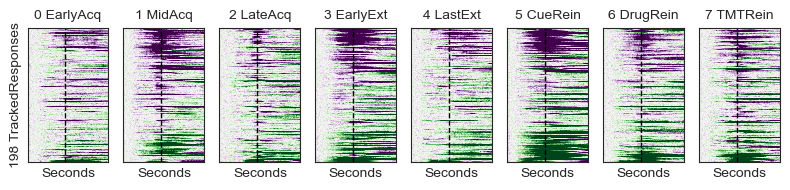

In [496]:
### CREATE HEATMAPS FOR SPECIFIC DAY-TO-DAY COMPARISONS
fig, axs = plt.subplots(1, len(daysforstability), figsize=(1*len(daysforstability), 2))

cmax = 4
cmin = -4

temp = {}
nan_mask = np.isnan(tracked_popevents_alldays).any(axis=(1, 2))

for d, day in enumerate(sorted(daysforstability)):
    # Exclude rows with any NaNs across all days
    temp[day] = tracked_popevents_alldays[~nan_mask, :, d]

    # Optional: Print the shape to verify the result
    print(f"Shape of temp[{day}]:", temp[day].shape)
    
    tempresponse = np.mean(tracked_popevents_alldays[~nan_mask, aucfirstframe:auclastframe, :], axis = (1,2))

    sortresponse = np.argsort(tempresponse)[::-1]
    temp_numneurons = len(sortresponse)

for d, day in enumerate(sorted(daysforstability)):

    ax = axs[d]

    # Plot the heatmap using matplotlib or seaborn (sns)
    im = ax.imshow(temp[day][sortresponse], cmap=plt.get_cmap('PRGn_r'), vmin=cmin, vmax=cmax, aspect='auto') #matplotlib

#     if d == len(daysforstability) -1:
#         fig.colorbar(im, ax=ax, shrink=0.5) #matplotlib

#     sns.heatmap(data[day][sortresponse], cmap='PRGn_r', vmin=-cmax, vmax=cmax, ax = ax) #seaborn

    ax.axvline(x=pre_window_size, color='k', linestyle='--', linewidth = 1)

    ax.set_xticks([])
    ax.set_xlabel('Seconds', fontsize=10)
    ax.set_yticks([])
    if d == 0:
        ax.set_ylabel('%s TrackedResponses'%temp_numneurons, fontsize=10)
    ax.set_title(day, fontsize=10)

fig.tight_layout()

# plt.savefig(os.path.join(basedir, 'Results', 'Tracking_HeatMap_%s.PDF'%pick_your_days), format='PDF')
# plt.savefig(os.path.join(basedir, 'Results', 'Tracking_HeatMap_%s.PNG'%pick_your_days), format='PNG')

plt.show()

/var/folders/pk/ygvbglbn6bq1fx39y5xg76dc0000gn/T/ipykernel_29373/2400260105.py:27: RuntimeWarning:

Mean of empty slice



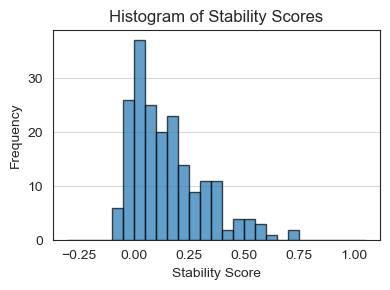

In [497]:
### CALCULATE STABILITY SCORES
stabilityscores = []
stabilityscores_rein = []
numtrackedneurons = np.shape(tracked_popevents_alldays)[0]
stabilityscores_rein_all = np.nan*np.ones((numtrackedneurons, 6))
for neuron in range(numtrackedneurons):
    rvals_neuron = []
    rvals_rein_neuron = []
    for d1, day1 in enumerate(sorted(daysforstability)):
        for d2, day2 in enumerate(sorted(daysforstability)):
            if d1 != d2 and d1 != '0 EarlyAcq' and d2!= '0 EarlyAcq':
                temp1 = tracked_popevents_alldays[neuron, :, d1]
                temp2 = tracked_popevents_alldays[neuron, :, d2]
                try:
                    rval = stats.pearsonr(temp1, temp2)[0]
                except ValueError:
                    rval = np.nan
                rvals_neuron.append(rval)
                if pick_your_days == 'all':
                    if day1 == '5 CueRein' or day1 == '6 DrugRein' or day1 == '7 TMTRein':
                        if day2 == '5 CueRein' or day2 == '6 DrugRein' or day2 == '7 TMTRein':
                            rvals_rein_neuron.append(rval)
                
    stabilityscore = np.mean(rvals_neuron)
    stabilityscores = np.append(stabilityscores, stabilityscore)
    if pick_your_days == 'all':
        stabilityscore_rein  = np.nanmean(rvals_rein_neuron)
        stabilityscores_rein = np.append(stabilityscores_rein, stabilityscore_rein)
        stabilityscores_rein_all[neuron, :] = rvals_rein_neuron
# Define the range and bin size
bins = np.arange(-0.3, 1.1, 0.05)  # Creates bins from -0.3 to +1 with a 0.1 increment

# Create the histogram
plt.figure(figsize=(4, 3))  # Adjust the figure size as needed
plt.hist(stabilityscores, bins=bins, edgecolor='black', alpha=0.7)

# Set plot titles and labels
plt.title('Histogram of Stability Scores')
plt.xlabel('Stability Score')
plt.ylabel('Frequency')

# Show grid
plt.grid(axis='y', alpha=0.75)

# Show the plot
plt.tight_layout()

# plt.savefig(os.path.join(basedir, 'Results', 'Tracking_Histogram_%s.PDF'%pick_your_days), format='PDF')
# plt.savefig(os.path.join(basedir, 'Results', 'Tracking_Histogram_%s.PNG'%pick_your_days), format='PNG')

plt.show()

    

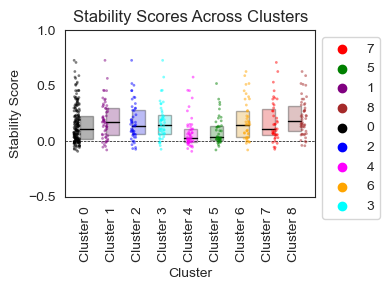

In [498]:
### BOX AND STRIP PLOTS FOR STABILITY SCORES FOR EACH CLUSTER ###
### FIGURE SETTINGS ###
fig, ax = plt.subplots(figsize=(4, 3))  # Wider figure for better visibility

sns.set_style('white')

# Prepare data for the box plot
data = []
labels = []
group_labels = []

for c in range(numclusters):
    # Select stability scores for neurons in cluster 'c'
    temp_clusterids = np.squeeze(tracked_clusterids_alldays)
    
    # Create a mask that is True for neurons belonging to cluster 'c' on any of the 4 days
    clustermask = np.any(temp_clusterids == c, axis=1).astype(bool)
    
    temp = stabilityscores[clustermask]  # Use your existing clustermask logic
    
    data.extend(temp)  # Add stability scores for this cluster
    labels.extend([f'Cluster {c}'] * len(temp))  # Label for the cluster
    group_labels.extend([c] * len(temp))  # Use cluster as group label

# Create a DataFrame for the box plot
df = pd.DataFrame({'Stability Score': data, 'Cluster': labels, 'Group': group_labels})

# Plot the box plot with increased width
sns.boxplot(x='Cluster', y='Stability Score', data=df, 
            palette=cluster_colors, dodge=1, ax=ax, linewidth=1, fliersize=0, 
            width=0.5, boxprops=dict(alpha=0.3), whiskerprops=dict(alpha=0), 
            capprops=dict(alpha=0), medianprops=dict(alpha=1))

# Plot the strip plot
sns.stripplot(x='Cluster', y='Stability Score', hue='Group', size=2, 
              alpha=0.5, data=df, palette=cluster_colors[0:numclusters], dodge=0.01, jitter=1, ax=ax)

# Reduce legend duplication
handles, labels = ax.get_legend_handles_labels()
unique_labels = list(set(labels))
unique_handles = [handles[labels.index(label)] for label in unique_labels]
ax.legend(unique_handles, unique_labels, loc='upper left', bbox_to_anchor=(1, 1))

ax.set_title('Stability Scores Across Clusters')
ax.set_xlabel('Cluster')
ax.set_ylabel('Stability Score')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.set_xlim(-0.8, 8.8)
ax.set_ylim(-0.5, 1.0)
ax.axhline(0, color = 'k', linewidth = 0.5, linestyle = '--')


fig.tight_layout()

# # Save the figure
# plt.savefig(os.path.join(basedir, 'Results', 'StabilityScores_ByCluster_%s.PDF'%pick_your_days), format='PDF')
# plt.savefig(os.path.join(basedir, 'Results', 'StabilityScores_ByCluster_%s.PNG'%pick_your_days), format='PNG')

plt.show()


stable neurons =  66
unstable neurons =  66
stable neurons =  66
unstable neurons =  66
stable neurons =  66
unstable neurons =  66
stable neurons =  66
unstable neurons =  66
stable neurons =  66
unstable neurons =  66
stable neurons =  66
unstable neurons =  66
stable neurons =  66
unstable neurons =  66
stable neurons =  66
unstable neurons =  66


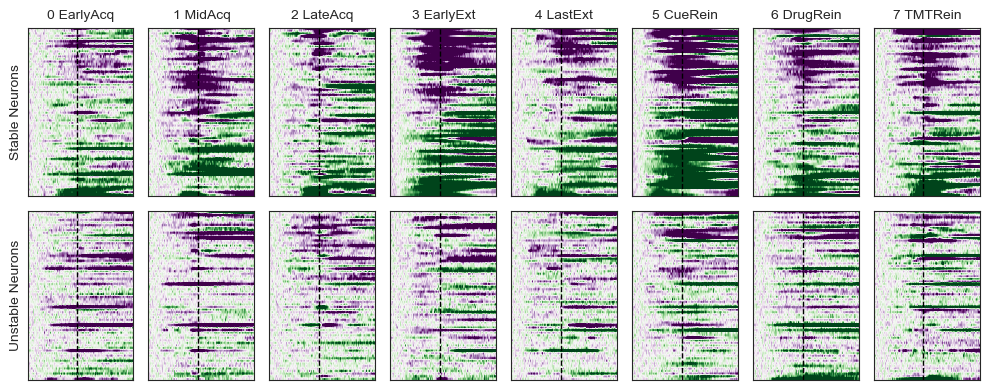

In [499]:
### CREATE HEATMAPS FOR SPECIFIC DAY-TO-DAY COMPARISONS FOR STABLE VS UNSTABLE NEURONS
# Assuming stabilityscores and tracked_popevents_alldays are defined
top_threshold = np.nanquantile(stabilityscores, 2/3)  # Top 1/3
bottom_threshold = np.nanquantile(stabilityscores, 1/3)  # Bottom 1/3

# Create subplots for two rows
fig, axs = plt.subplots(2, len(daysforstability), figsize=(1.25*len(daysforstability), 4))

cmax = 4
cmin = -4

temp = {}
for d, day in enumerate(sorted(daysforstability)):
    # Top 1/3 cells
    top_mask = stabilityscores > top_threshold
    temp_top = tracked_popevents_alldays[:, :, d][top_mask]
    tempresponse = np.mean(tracked_popevents_alldays[:, aucfirstframe:auclastframe, :], axis=(1, 2))[top_mask]
    sortresponse_top = np.argsort(tempresponse)[::-1]
    print('stable neurons = ', len(sortresponse_top))

    # Bottom 1/3 cells
    bottom_mask = stabilityscores < bottom_threshold
    temp_bottom = tracked_popevents_alldays[:, :, d][bottom_mask]
    tempresponse_bottom = np.mean(tracked_popevents_alldays[:, aucfirstframe:auclastframe, :], axis=(1, 2))[bottom_mask]
    sortresponse_bottom = np.argsort(tempresponse_bottom)[::-1]
    print('unstable neurons = ', len(sortresponse_bottom))

    # Plot top 1/3 
    ax_top = axs[0, d]
    im_top = ax_top.imshow(temp_top[sortresponse_top], cmap='PRGn_r', vmin=cmin, vmax=cmax, aspect='auto')
    ax_top.axvline(x=pre_window_size, color='k', linestyle='--', linewidth=1)
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    if d == 0:
        ax_top.set_ylabel('Stable Neurons', fontsize=10)
    ax_top.set_title(day, fontsize=10)

    # Plot bottom 1/3
    ax_bottom = axs[1, d]
    im_bottom = ax_bottom.imshow(temp_bottom[sortresponse_bottom], cmap='PRGn_r', vmin=cmin, vmax=cmax, aspect='auto')
    ax_bottom.axvline(x=pre_window_size, color='k', linestyle='--', linewidth=1)
    ax_bottom.set_xticks([])
    ax_bottom.set_yticks([])
    if d == 0:
        ax_bottom.set_ylabel('Unstable Neurons', fontsize=10)
    
# Adjust layout
fig.tight_layout()

# Save the figure if needed
# plt.savefig(os.path.join(basedir, 'Results', 'Tracking_HeatMap_ByStability_%s.PDF'%pick_your_days), format='PDF')
# plt.savefig(os.path.join(basedir, 'Results', 'Tracking_HeatMap_ByStability_%s.PNG'%pick_your_days), format='PNG')

plt.show()


In [500]:
### PLOT EXAMPLE NEURONS FOR FIGURE IF DESIRED

# Assuming stabilityscores and tracked_popevents_alldays are defined
numexamples = 40
numexamples_each = int(numexamples / 2)

# Create subplots for the top and bottom neurons on each day
fig, axs = plt.subplots(numexamples, len(daysforstability), figsize=(1.25 * len(daysforstability), numexamples), sharey='row')

# Sort indices based on stability scores
sorted_indices = np.argsort(stabilityscores_rein)
top_indices = sorted_indices[-numexamples_each:]  # Top stable cells
bottom_indices = sorted_indices[:numexamples_each]  # Bottom unstable cells

for d, day in enumerate(sorted(daysforstability)):
    # Plot top stable cells
    for i, idx in enumerate(top_indices):
        ax = axs[i, d]
        ax.plot(tracked_popevents_alldays[idx, :, d], color='blue')
        ax.axvline(x=pre_window_size, color='k', linestyle='--', linewidth=1)
        if d == 0:
            ax.axhline(y=0, color='k', linewidth=0.5, linestyle='--')  
            ax.axhline(y=5, color='k', linewidth=0.5, linestyle='--')  
            ax.set_ylabel(f'Top {i+1}', fontsize=10)
        ax.set_yticks([])
        ax.set_xticks([])
        if i == 0:
            ax.set_title(day, fontsize=10)
    
    # Plot bottom unstable cells
    for i, idx in enumerate(bottom_indices):
        ax = axs[i + numexamples_each, d]
        ax.plot(tracked_popevents_alldays[idx, :, d], color='red', linewidth=1)
        ax.axvline(x=pre_window_size, color='k', linestyle='--', linewidth=1)
        if d == 0:
            ax.axhline(y=0, color='k', linewidth=0.5, linestyle='--')  
            ax.axhline(y=5, color='k', linewidth=0.5, linestyle='--') 
            ax.set_ylabel(f'Bottom {i+1}', fontsize=10)
        ax.set_yticks([])
        ax.set_xticks([])

# Adjust layout
fig.tight_layout()

# Save the figure if needed
# plt.savefig(os.path.join(basedir, 'Results', 'Tracking_Examples.PDF'), format='PDF')
# plt.savefig(os.path.join(basedir, 'Results', 'Tracking_Examples.PNG'), format='PNG')

plt.close()


PearsonRResult(statistic=0.2498916202557554, pvalue=4.80178571928964e-28)


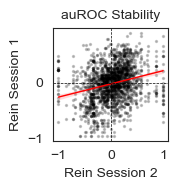

In [501]:
#### Correlation Plots
fig, axs = plt.subplots(1, figsize=(2, 2))
sns.set_style('white')

correlation_array = np.nan*np.ones((1, 2))

# Create a scatter plot with a regression line for clustered neurons
for d1, day1 in enumerate(sorted(daysforstability)):
    for d2, day2 in enumerate(sorted(daysforstability)):
        if d1 > d2 and day1 in ['5 CueRein', '6 DrugRein', '7 TMTRein'] and day2 in ['5 CueRein', '6 DrugRein', '7 TMTRein']:
            day1_responses = tracked_aucpvals_alldays[:, 0, d1].copy()
            day2_responses = tracked_aucpvals_alldays[:, 0, d2].copy()
            responses = np.vstack((day1_responses, day2_responses)).T
            correlation_array = np.vstack((correlation_array, responses))

# Create the mask for NaN values
nan_mask = np.isnan(correlation_array).any(axis=1)
filtered_correlation_array = correlation_array[~nan_mask]

axs.scatter(x=filtered_correlation_array[:, 0], y=filtered_correlation_array[:, 1], s = 2, alpha = .2, color = 'k')

axs.set_ylabel('Rein Session 1')  # Set the y-axis label
axs.set_xlabel('Rein Session 2')  # Set the x-axis label

axs.set_title('auROC Stability', fontsize=10)  # Set the title of the plot

sns.regplot(x=correlation_array[:, 0], y=correlation_array[:, 1], ax = axs, scatter = False,
           line_kws={'color': 'red', 'linewidth': 1})

axs.axvline(x = 0, color = 'k', linestyle = '--', linewidth = 0.5)
axs.axhline(y = 0, color = 'k', linestyle = '--', linewidth = 0.5)

print(stats.pearsonr(filtered_correlation_array[:, 0], filtered_correlation_array[:, 1]))
    
plt.tight_layout()  

# plt.savefig(os.path.join(basedir, 'Results', 'Session Stability Correlation.PDF'), format='PDF')
# plt.savefig(os.path.join(basedir, 'Results', 'Session Stability Correlation.png'), format='PNG')

plt.show()

# PearsonRResult(statistic=0.2498916202557554, pvalue=4.80178571928964e-28)

Unstable Cells: r = -0.14755, p = 0.00007
Stable Cells: r = 0.61463, p = 0.00000


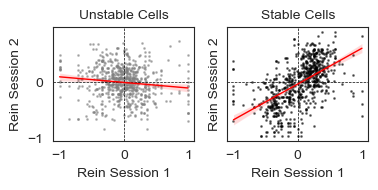

In [502]:
#### Correlation Plots
fig, axs = plt.subplots(1, 2, figsize=(4, 2), sharex=True, sharey=True)
sns.set_style('white')

correlation_array = np.nan * np.ones((1, 2))
stabilityscores_array = []

# Create a scatter plot with a regression line for clustered neurons
for d1, day1 in enumerate(sorted(daysforstability)):
    for d2, day2 in enumerate(sorted(daysforstability)):
        if d1 > d2 and day1 in ['5 CueRein', '6 DrugRein', '7 TMTRein'] and day2 in ['5 CueRein', '6 DrugRein', '7 TMTRein']:
            day1_responses = tracked_aucpvals_alldays[:, 0, d1].copy()
            day2_responses = tracked_aucpvals_alldays[:, 0, d2].copy()
            responses = np.vstack((day1_responses, day2_responses)).T
            correlation_array = np.vstack((correlation_array, responses))
            stabilityscores_array = np.hstack((stabilityscores_array, stabilityscores_rein))
            
# Remove the initial row of NaNs
correlation_array = correlation_array[1:, :]

# Create masks for NaN values and cluster IDs
nan_mask = np.isnan(correlation_array).any(axis=1)

for s in range(2):
    if s == 0:
        stability_mask = stabilityscores_array < bottom_threshold
        title = 'Unstable Cells'
        color = 'gray'
        ax = axs[0]
    else:
        stability_mask = stabilityscores_array > top_threshold
        title = 'Stable Cells'
        color = 'black'
        ax = axs[1]

    
    # Apply masks simultaneously
    filtered_correlation_array = correlation_array[~nan_mask & stability_mask]
    
    ax.axvline(x = 0, color = 'k', linestyle = '--', linewidth = 0.5)
    ax.axhline(y = 0, color = 'k', linestyle = '--', linewidth = 0.5)


    ax.scatter(filtered_correlation_array[:, 0], filtered_correlation_array[:, 1], s=1, alpha=0.5, color=color)
    
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Rein Session 1')
    ax.set_ylabel('Rein Session 2')

    # Add regression line
    sns.regplot(x=filtered_correlation_array[:, 0], y=filtered_correlation_array[:, 1], ax=ax, scatter=False, color='r', line_kws={'linewidth': 1})
       
    # Calculate and display Pearson correlation coefficient
    r, p = stats.spearmanr(filtered_correlation_array[:, 0], filtered_correlation_array[:, 1])
    print(f'{title}: r = {r:.5f}, p = {p:.5f}')
        
plt.tight_layout()

# plt.savefig(os.path.join(basedir, 'Results', 'Session Stability Correlation ByStability.PDF'), format='PDF')
# plt.savefig(os.path.join(basedir, 'Results', 'Session Stability Correlation ByStability.png'), format='PNG')


plt.show()

# Unstable Cells: r = -0.14755, p = 0.00007
# Stable Cells: r = 0.61463, p = 0.00000

NC Cells: r = 0.04968, p = 0.09947
Clustered Cells: r = 0.29164, p = 0.00000


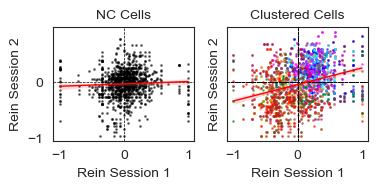

In [503]:
#### Correlation Plots
fig, axs = plt.subplots(1, 2, figsize=(4, 2), sharex=True, sharey=True)
sns.set_style('white')

correlation_array = np.nan * np.ones((1, 2))
clusterids_array = np.nan * np.ones((1, 3))

# Create a scatter plot with a regression line for clustered neurons
for d1, day1 in enumerate(sorted(daysforstability)):
    for d2, day2 in enumerate(sorted(daysforstability)):
        if d1 > d2 and day1 in ['5 CueRein', '6 DrugRein', '7 TMTRein'] and day2 in ['5 CueRein', '6 DrugRein', '7 TMTRein']:
            day1_responses = tracked_aucpvals_alldays[:, 0, d1].copy()
            day2_responses = tracked_aucpvals_alldays[:, 0, d2].copy()
#             day1_responses = np.nanmean(tracked_popevents_alldays[:, aucfirstframe:auclastframe, d1], axis=1)
#             day2_responses = np.nanmean(tracked_popevents_alldays[:, aucfirstframe:auclastframe, d2], axis=1)
            responses = np.vstack((day1_responses, day2_responses)).T
            correlation_array = np.vstack((correlation_array, responses))
            
            clusters = tracked_clusterids_alldays[:, 0, 5:8].copy()
            clusterids_array = np.vstack((clusterids_array, clusters))
            
# Remove the initial row of NaNs
correlation_array = correlation_array[1:, :]
clusterids_array = clusterids_array[1:, :]

# Create masks for NaN values and cluster IDs
nan_mask = np.isnan(correlation_array).any(axis=1)
    
    
#     if c == 0:
#         mask = np.all(reference_clusterids == 0, axis=1)    
#     elif c == 1:
#         mask = np.all(reference_clusterids != 0, axis=1)
        
        
for c in range(numclusters + 1):
    if c == 0:
        cluster_mask = np.sum(clusterids_array == 0, axis=1) >= 2 
        title = 'NC Cells'
        color = 'black'
        ax = axs[0]
    elif c != numclusters:
        cluster_mask = np.any(clusterids_array == c, axis=1) 
        title = 'Clustered Cells'
        color = cluster_colors[c]
        ax = axs[1]
    elif c == numclusters:
        cluster_mask = np.any(clusterids_array > 0, axis=1) 
        ax = axs[1]
    
    # Apply masks simultaneously
    filtered_correlation_array = correlation_array[~nan_mask & cluster_mask]
    
    ax.axvline(x = 0, color = 'k', linestyle = '--', linewidth = 0.5)
    ax.axhline(y = 0, color = 'k', linestyle = '--', linewidth = 0.5)


    if c != numclusters:
        ax.scatter(filtered_correlation_array[:, 0], filtered_correlation_array[:, 1], s=1, alpha=0.5, color=color)
    
    if c < 2:
        ax.set_title(title, fontsize=10)
        ax.set_xlabel('Rein Session 1')
        ax.set_ylabel('Rein Session 2')

    # Add regression line
    if c == 0 or c == numclusters:
        sns.regplot(x=filtered_correlation_array[:, 0], y=filtered_correlation_array[:, 1], ax=ax, scatter=False, color='r', line_kws={'linewidth': 1})
       
        # Calculate and display Pearson correlation coefficient
        r, p = stats.pearsonr(filtered_correlation_array[:, 0], filtered_correlation_array[:, 1])
        print(f'{title}: r = {r:.5f}, p = {p:.5f}')
        
plt.tight_layout()

# plt.savefig(os.path.join(basedir, 'Results', 'Session Stability Correlation ByCluster.PDF'), format='PDF')
# plt.savefig(os.path.join(basedir, 'Results', 'Session Stability Correlation ByCluster.png'), format='PNG')

plt.show()

# NC Cells: r = 0.04968, p = 0.09947
# Clustered Cells: r = 0.29164, p = 0.00000

In [504]:
### SANKEY FOR STABLE VS UNSTABLE NEURONS

# Define options to exclude cluster 0 from the left or right
exclude_unclustered_d1 = 'yes'  # Change to 'no' if you do not want to exclude
exclude_unclustered_d2 = 'yes'  # Change to 'no' if you do not want to exclude

from plotly.subplots import make_subplots
import plotly.io as pio

def create_sankey_data(clusterids, exclude_cluster_0_left=True, exclude_cluster_0_right=True):
    labels = []
    source = []
    target = []
    value = []
    color = []
    
    for i in range(clusterids.shape[1] - 1):
        day1_clusters = clusterids[:, i]
        day2_clusters = clusterids[:, i + 1]
        
        for c1 in np.unique(day1_clusters):
            if exclude_cluster_0_left and c1 == 0:
                continue
            for c2 in np.unique(day2_clusters):
                if exclude_cluster_0_right and c2 == 0:
                    continue
                count = np.sum((day1_clusters == c1) & (day2_clusters == c2))
                if count > 0:
                    source.append(f'Day {i+1} - {c1}')
                    target.append(f'Day {i+2} - {c2}')
                    value.append(count)
                    color.append(cluster_colors[int(c1)])
                    
                    if f'Day {i+1} - {c1}' not in labels:
                        labels.append(f'Day {i+1} - {c1}')
                    if f'Day {i+2} - {c2}' not in labels:
                        labels.append(f'Day {i+2} - {c2}')
    
    # Sort labels by the cluster number, handling floats correctly
    labels = sorted(labels, key=lambda x: int(float(x.split(' - ')[1])))
    
    return labels, source, target, value, color

def get_cluster_color(label):
    cluster_id = int(float(label.split(' - ')[1]))
    return cluster_colors[cluster_id]

def plot_sankey(labels, source, target, value, color, title):
    label_indices = {label: i for i, label in enumerate(labels)}
    source_indices = [label_indices[s] for s in source]
    target_indices = [label_indices[t] for t in target]

    node_colors = [get_cluster_color(label) for label in labels]
    
    fig = go.Figure(go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color=node_colors, width=0.5),  # Node edge color same as node color
            label=[],  # No labels
            color=node_colors,
        ),
        link=dict(
            source=source_indices,
            target=target_indices,
            value=value,
            color=color
        )
    ))

    fig.update_layout(title_text=title, font_size=10, height=400, width=600)
    return fig



In [505]:
### SANKEY PLOTS FOR STABLE VS UNSTABLE NEURONS

clusterids_array = np.nan * np.ones((1, 2))
stabilityscore_array = []

# Create a scatter plot with a regression line for clustered neurons
for d1, day1 in enumerate(sorted(daysforstability)):
    for d2, day2 in enumerate(sorted(daysforstability)):
        if day1 in ['5 CueRein', '6 DrugRein', '7 TMTRein'] and day2 in ['5 CueRein', '6 DrugRein', '7 TMTRein']:     
            clusters = tracked_clusterids_alldays[:, 0, [d1, d2]].copy()
            clusterids_array = np.vstack((clusterids_array, clusters))            
            stabilityscore_array = np.append(stabilityscore_array, stabilityscores_rein)
                        
# Remove the initial row of NaNs
clusterids_array = clusterids_array[1:, :]
    
stable_indices = stabilityscore_array >= top_threshold
unstable_indices = stabilityscore_array < bottom_threshold

stable_clusterids = clusterids_array[stable_indices]
unstable_clusterids = clusterids_array[unstable_indices]

# Set the options for excluding cluster 0
exclude_unclustered_d1 = 'yes'
exclude_unclustered_d2 = 'yes'

exclude_cluster_0_left = exclude_unclustered_d1 == 'yes'
exclude_cluster_0_right = exclude_unclustered_d2 == 'yes'

# Create Sankey data for stable neurons
stable_labels, stable_source, stable_target, stable_value, stable_color = create_sankey_data(stable_clusterids, exclude_cluster_0_left, exclude_cluster_0_right)
unstable_labels, unstable_source, unstable_target, unstable_value, unstable_color = create_sankey_data(unstable_clusterids, exclude_cluster_0_left, exclude_cluster_0_right)

# Plot Sankey diagrams
stable_fig = plot_sankey(stable_labels, stable_source, stable_target, stable_value, stable_color, 'Stable Neurons')
unstable_fig = plot_sankey(unstable_labels, unstable_source, unstable_target, unstable_value, unstable_color, 'Unstable Neurons')

# Combine figures side by side using subplots
fig = make_subplots(rows=1, cols=2, specs=[[{'type': 'domain'}, {'type': 'domain'}]], subplot_titles=('Stable Neurons', 'Unstable Neurons'), horizontal_spacing=0.1)
fig.add_trace(stable_fig.data[0], row=1, col=1)
fig.add_trace(unstable_fig.data[0], row=1, col=2)

fig.update_layout(height=400, width=500)
fig.show()

# pio.write_image(fig, os.path.join(basedir, 'Results', 'Sankey_Plots.pdf'))


### BETWEEN SESSION SPIKE PREDICTION STABILITY

In [506]:
def synchronize_nans(array1, array2):
    # Find indices where either array contains np.nan
    nan_indices = np.isnan(array1) | np.isnan(array2)
    
    # Set both arrays to np.nan at these indices
    array1[nan_indices] = np.nan
    array2[nan_indices] = np.nan
    
    return array1, array2

In [507]:
baseline_day = '0 EarlyAcq' #Day at which data is normalized to (starting point = 0)
reference_day = '5 CueRein' #Day at which data is tracked from 
reference_days = ['5 CueRein', '6 DrugRein', '7 TMTRein']  # Days at which clusters are identified

days = np.asarray(sorted(days))
baseline_day_index = np.where(days == baseline_day)[0][0]
reference_day_index = np.where(days == reference_day)[0][0]
reference_day_indices = [np.where(days == ref_day)[0][0] for ref_day in reference_days]


Basal Firing (Hz) 0 EarlyAcq TtestResult(statistic=8.022541635376404, pvalue=2.7722286246288815e-15, df=1042)
Mean Firing (Hz) 0 EarlyAcq TtestResult(statistic=3.301443252943964, pvalue=0.0009945315973830457, df=1042)
Max Firing (Hz) 0 EarlyAcq TtestResult(statistic=1.395345189914851, pvalue=0.16320906646389147, df=1042)
Burst Freq (Hz) 0 EarlyAcq TtestResult(statistic=2.5466149084368426, pvalue=0.011020247744171005, df=1042)
Burst ISI (s) 0 EarlyAcq TtestResult(statistic=-2.5612070734512575, pvalue=0.010570776837562006, df=1042)
Burst Amp (Hz) 0 EarlyAcq TtestResult(statistic=-0.21158482725893737, pvalue=0.8324723227792927, df=1042)
Burst Amp (ΔHz) 0 EarlyAcq TtestResult(statistic=-4.3878182290910415, pvalue=1.2613544826816228e-05, df=1042)
Burst Width (s) 0 EarlyAcq TtestResult(statistic=-5.648926965642804, pvalue=2.0820693916492828e-08, df=1042)
SNR 0 EarlyAcq TtestResult(statistic=-1.1020711332229436, pvalue=0.27068523227980823, df=1042)


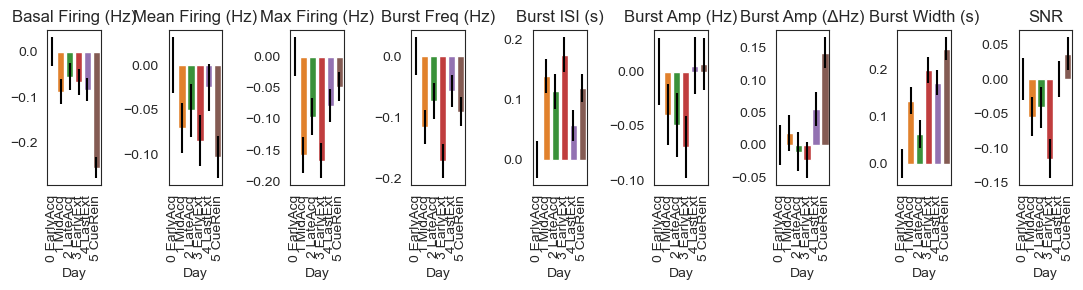

In [508]:
### PLOT THE CHANGE IN CASCADE MEASURES IN TRACKED NEURONS

fig, axs = plt.subplots(1, len(measurements), figsize=(11, 3))

for m, measurement in enumerate(measurements):
    
    # Calculate means and SEMs for each day
    means = []
    sems = []

    for d, day in enumerate(sorted(daysforbaselines)):
        values_day = tracked_cmeasures_alldays[:, m, d].copy()
        values_comparison = tracked_cmeasures_alldays[:, m, reference_day_index].copy()
        values_day, values_comparison = synchronize_nans(values_day, values_comparison)
        values = (values_day-np.nanmean(values_comparison))/np.nanstd(values_day)
        
        if day == baseline_day:
            print(measurement, day, stats.ttest_rel(values_day, values_comparison, nan_policy = 'omit'))

        means.append(np.nanmean(values))
        sems.append(np.nanstd(values) / np.sqrt(np.count_nonzero(values > -1000)))

    means = means - means[baseline_day_index]

    # Create DataFrame for plotting
    plot_df = pd.DataFrame({'Day': sorted(daysforbaselines), 'Mean': means, 'SEM': sems})

    # Plot bar plot with error bars
    ax = axs[m]
    sns.barplot(x='Day', y='Mean', yerr=plot_df['SEM'], data=plot_df, ax=ax, capsize=0.2)
    ax.set_title(measurement)
    ax.set_xlabel('Day')
    ax.set_ylabel(None)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
   
plt.tight_layout()
plt.show()

# Basal Firing (Hz) 0 EarlyAcq TtestResult(statistic=8.022541635376404, pvalue=2.7722286246288815e-15, df=1042)
# Mean Firing (Hz) 0 EarlyAcq TtestResult(statistic=3.301443252943964, pvalue=0.0009945315973830457, df=1042)
# Max Firing (Hz) 0 EarlyAcq TtestResult(statistic=1.395345189914851, pvalue=0.16320906646389147, df=1042)
# Burst Freq (Hz) 0 EarlyAcq TtestResult(statistic=2.5466149084368426, pvalue=0.011020247744171005, df=1042)
# Burst ISI (s) 0 EarlyAcq TtestResult(statistic=-2.5612070734512575, pvalue=0.010570776837562006, df=1042)
# Burst Amp (Hz) 0 EarlyAcq TtestResult(statistic=-0.21158482725893737, pvalue=0.8324723227792927, df=1042)
# Burst Amp (ΔHz) 0 EarlyAcq TtestResult(statistic=-4.3878182290910415, pvalue=1.2613544826816228e-05, df=1042)
# Burst Width (s) 0 EarlyAcq TtestResult(statistic=-5.648926965642804, pvalue=2.0820693916492828e-08, df=1042)
# SNR 0 EarlyAcq TtestResult(statistic=-1.1020711332229436, pvalue=0.27068523227980823, df=1042)
  
    

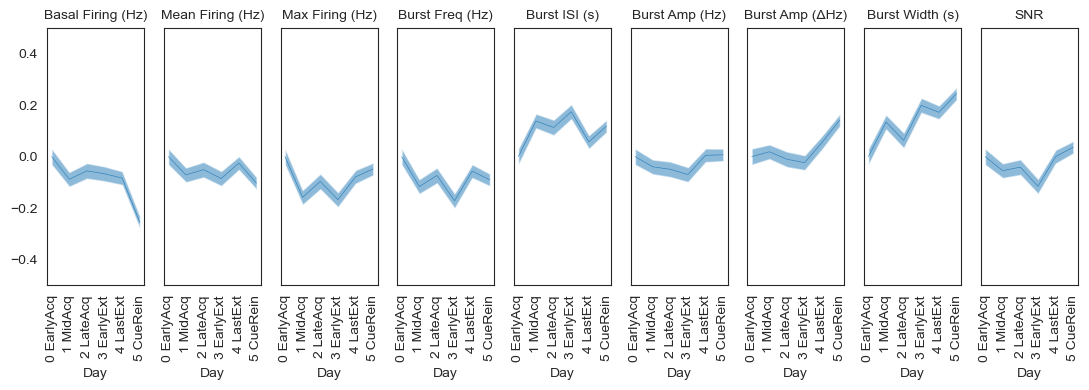

In [509]:
### PLOT THE CHANGE IN CASCADE MEASURES IN TRACKED NEURONS, SPLIT BY CLUSTERED AND NON CLUSTERED CELLS

fig, axs = plt.subplots(1, len(measurements), figsize=(11, 4), sharey='all')

for m, measurement in enumerate(measurements):

    # Calculate means and SEMs for each day
    means = []
    sems = []

    for d, day in enumerate(sorted(daysforbaselines)):
        values_day = tracked_cmeasures_alldays[:, m, d].copy()
        values_comparison = tracked_cmeasures_alldays[:, m, reference_day_index].copy()
        values_day, values_comparison = synchronize_nans(values_day, values_comparison)
        values = (values_day - np.nanmean(values_comparison)) / np.nanstd(values_day)
        means.append(np.nanmean(values))
        sems.append(np.nanstd(values) / np.sqrt(np.count_nonzero(values > -1000)))

    means = means - means[0]

    # Create DataFrame for plotting
    plot_df = pd.DataFrame({'Day': sorted(daysforbaselines), 'Mean': means, 'SEM': sems})

    # Plot line plot with error regions
    ax = axs[m]
    sns.lineplot(x='Day', y='Mean', data=plot_df, ax=ax, marker=None, linewidth = 0.4)
    ax.fill_between(plot_df['Day'], plot_df['Mean'] - plot_df['SEM'], plot_df['Mean'] + plot_df['SEM'], alpha=0.5)
    ax.set_title(measurement, fontsize = 10)
    ax.set_xlabel('Day')
    ax.set_ylabel(None)
    ax.set_ylim(-0.5, 0.5)
    ax.set_xticks(plot_df['Day'])  # Set the positions of the ticks
    ax.set_xticklabels(plot_df['Day'], rotation=90)  # Set the labels for the ticks

plt.tight_layout()
plt.show()

# fig.savefig(os.path.join(basedir, 'Results', 'CascadeMeasures_Tracked_Cluster.PDF'), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', 'CascadeMeasures_Tracked_Cluster.png'), format='PNG')

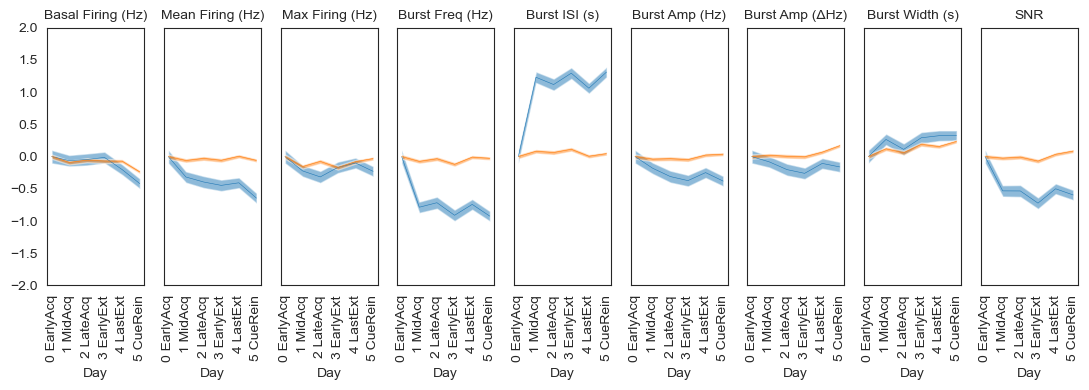

In [510]:
### PLOT THE CHANGE IN CASCADE MEASURES IN TRACKED NEURONS, SPLIT BY CLUSTERED AND NON CLUSTERED CELLS

fig, axs = plt.subplots(1, len(measurements), figsize=(11, 4), sharey='all')

reference_clusterids = tracked_clusterids_alldays[:, 0, reference_day_indices]
for c in range(2):
    if c == 0:
        mask = np.all(reference_clusterids == 0, axis=1)    
    elif c == 1:
        mask = np.any(reference_clusterids != 0, axis=1)

    for m, measurement in enumerate(measurements):

        # Calculate means and SEMs for each day
        means = []
        sems = []
        
        for d, day in enumerate(sorted(daysforbaselines)):
            values_day = tracked_cmeasures_alldays[:, m, d][mask]
            values_comparison = tracked_cmeasures_alldays[:, m, reference_day_index][mask]
            values_day, values_comparison = synchronize_nans(values_day, values_comparison)
            values = (values_day - np.nanmean(values_comparison)) / np.nanstd(values_day)
            means.append(np.nanmean(values))
            sems.append(np.nanstd(values) / np.sqrt(np.count_nonzero(values > -1000)))

        means = means - means[0]

        # Create DataFrame for plotting
        plot_df = pd.DataFrame({'Day': sorted(daysforbaselines), 'Mean': means, 'SEM': sems})

        # Plot line plot with error regions
        ax = axs[m]
        sns.lineplot(x='Day', y='Mean', data=plot_df, ax=ax, marker=None, linewidth = 0.4)
        ax.fill_between(plot_df['Day'], plot_df['Mean'] - plot_df['SEM'], plot_df['Mean'] + plot_df['SEM'], alpha=0.5, edgecolors = None)
        ax.set_title(measurement, fontsize = 10)
        ax.set_xlabel('Day')
        ax.set_ylabel(None)
        ax.set_ylim(-2, 2)
        ax.set_xticks(plot_df['Day'])  # Set the positions of the ticks
        ax.set_xticklabels(plot_df['Day'], rotation=90)  # Set the labels for the ticks

plt.tight_layout()
plt.show()

# fig.savefig(os.path.join(basedir, 'Results', 'CascadeMeasures_Tracked_ClusteredvsNon.PDF'), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', 'CascadeMeasures_Tracked_ClusteredvsNon.png'), format='PNG')

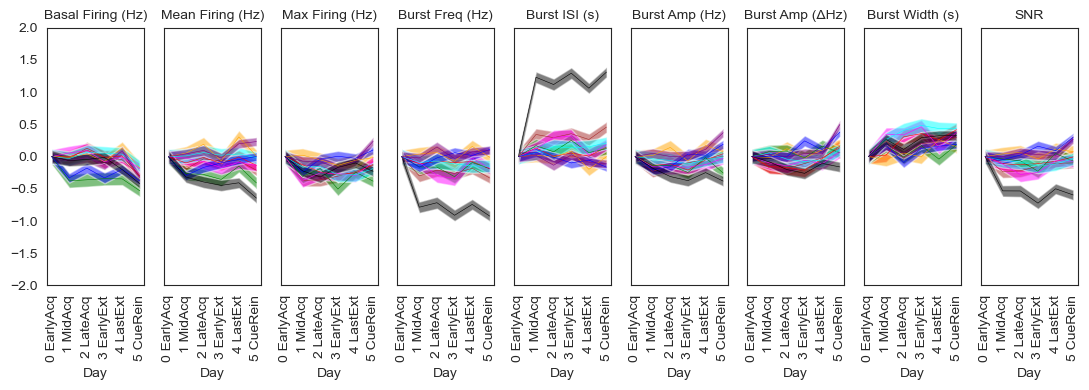

In [511]:
### PLOT THE CHANGE IN CASCADE MEASURES IN TRACKED NEURONS, SPLIT BY EACH CLUSTER

fig, axs = plt.subplots(1, len(measurements), figsize=(11, 4), sharey='all')
cmeasure_heatmaps = np.nan*np.ones((numclusters, len(daysforbaselines), len(measurements)))

reference_clusterids = tracked_clusterids_alldays[:, 0, reference_day_indices]
for c in reversed(range(numclusters)):
    if c == 0:
        mask = np.all(reference_clusterids == 0, axis=1)    
    else:
        mask = np.any(reference_clusterids == c, axis=1)

    for m, measurement in enumerate(measurements):

        # Calculate means and SEMs for each day
        means = []
        sems = []
        all_values = []
        
        for d, day in enumerate(sorted(daysforbaselines)):
            
            # Select neurons in cluster 0 on all reference days       
            values_day = tracked_cmeasures_alldays[:, m, d][mask]
            values_comparison = tracked_cmeasures_alldays[:, m, reference_day_index][mask]
            values_day, values_comparison = synchronize_nans(values_day, values_comparison)
            values = (values_day - np.nanmean(values_comparison)) / np.nanstd(values_day)

            means.append(np.nanmean(values))
            sems.append(np.nanstd(values) / np.sqrt(np.count_nonzero(values > -1000)))

        means = means - means[0]
        cmeasure_heatmaps[c, :, m] = means / sems
        
        # Create DataFrame for plotting
        plot_df = pd.DataFrame({'Day': sorted(daysforbaselines), 'Mean': means, 'SEM': sems})

        # Plot line plot with error regions
        ax = axs[m]
        sns.lineplot(x='Day', y='Mean', data=plot_df, ax=ax, marker=None, linewidth=0.4, label=f'Cluster {c}', color = cluster_colors[c])
        ax.fill_between(plot_df['Day'], plot_df['Mean'] - plot_df['SEM'], plot_df['Mean'] + plot_df['SEM'], alpha=0.5,  color = cluster_colors[c], edgecolor = None)
        ax.set_title(measurement, fontsize = 10)
        ax.set_xlabel('Day')
        ax.set_ylabel(None)
        ax.set_ylim(-2, 2)
        ax.set_xticks(plot_df['Day'])  # Set the positions of the ticks
        ax.set_xticklabels(plot_df['Day'], rotation=90)  # Set the labels for the ticks
        ax.get_legend().set_visible(False)
    
plt.tight_layout()
plt.show()

# fig.savefig(os.path.join(basedir, 'Results', 'CascadeMeasures_Tracked_Clusters.PDF'), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', 'CascadeMeasures_Tracked_Clusteres.png'), format='PNG')

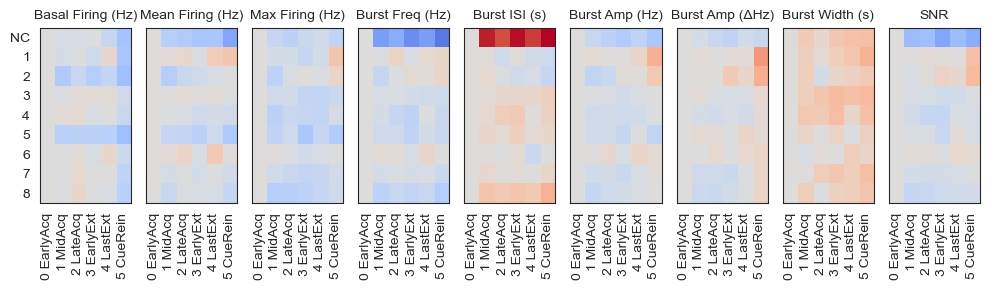

In [512]:
fig, axs = plt.subplots(1, len(measurements), figsize=(10, 3))

for m, measurement in enumerate(measurements):
    ax = axs[m]
    ax.imshow(cmeasure_heatmaps[:,:, m], cmap='coolwarm', aspect='auto', vmax=15, vmin=-15)
    ax.set_title(measurement, fontsize = 10)

    # Set the x-tick positions and labels
    ax.set_xticks(np.arange(len(daysforbaselines)))
    ax.set_xticklabels(daysforbaselines, rotation=90)
    if m == 0:
        # Set the y-tick positions and labels
        ax.set_yticks(np.arange(numclusters))
        ax.set_yticklabels(np.append('NC', np.arange(1, numclusters)))
    else:
        ax.set_yticklabels([])
plt.tight_layout()

plt.show()

In [513]:
# ### PLOT THE CHANGE IN CASCADE MEASURES IN TRACKED NEURONS, SPLIT BY STABLE AND UNSTABLE CELLS
# fig, axs = plt.subplots(1, len(measurements), figsize=(14, 4), sharey='row')

# top_threshold = np.nanquantile(stabilityscores, 2/3)  # Top 1/3
# bottom_threshold = np.nanquantile(stabilityscores, 1/3)  # Bottom 1/3

# # Define groups based on stability only
# groups = [
#     ('stable', stabilityscores_rein >= top_threshold),
#     ('unstable', stabilityscores_rein <= bottom_threshold)
# ]

# colors = ['b', 'r']  # Define distinct colors for stable and unstable groups

# for g, (label, stability_condition) in enumerate(groups):
#     mask = stability_condition
#     print(stability_condition)
    
#     for m, measurement in enumerate(measurements):
#         # Calculate means and SEMs for each day
#         means = []
#         sems = []

#         for d, day in enumerate(sorted(daysforbaselines)):
#             values_day = tracked_cmeasures_alldays[:, m, d][mask].copy()
#             values_comparison = tracked_cmeasures_alldays[:, m, reference_day_index][mask].copy()
#             values_day, values_comparison = synchronize_nans(values_day, values_comparison)
#             values = (values_day - np.nanmean(values_comparison)) / np.nanstd(values_day)
            
#             means.append(np.nanmean(values))
#             sems.append(np.nanstd(values) / np.sqrt(np.count_nonzero(values > -1000)))
            
#         means = means - means[0]

#         # Create DataFrame for plotting
#         plot_df = pd.DataFrame({'Day': sorted(daysforbaselines), 'Mean': means, 'SEM': sems})

#         # Plot line plot with error regions
#         ax = axs[m]
#         sns.lineplot(x='Day', y='Mean', data=plot_df, ax=ax, marker=None, linewidth=0.4, label=label, color=colors[g])
#         ax.fill_between(plot_df['Day'], plot_df['Mean'] - plot_df['SEM'], plot_df['Mean'] + plot_df['SEM'], alpha=0.5, color=colors[g], edgecolors = None)
#         ax.set_title(measurement)
#         ax.set_xlabel('Day')
#         ax.set_ylabel(None)
#         ax.set_ylim(-1, 1)
#         ax.set_xticks(plot_df['Day'])  # Set the positions of the ticks
#         ax.set_xticklabels(plot_df['Day'], rotation=90)  # Set the labels for the ticks

#         # Add legend outside the plot
#         if m == len(measurements) - 1:
#             handles, labels = ax.get_legend_handles_labels()
#             ax.legend(handles=handles, labels=labels, loc='upper left', bbox_to_anchor=(1, 1))
#         else:
#             ax.get_legend().set_visible(False)

# plt.tight_layout()
# plt.show()

# # fig.savefig(os.path.join(basedir, 'Results', 'CascadeMeasures_Tracked_Stability.PDF'), format='PDF')
# # fig.savefig(os.path.join(basedir, 'Results', 'CascadeMeasures_Tracked_Stability.png'), format='PNG')

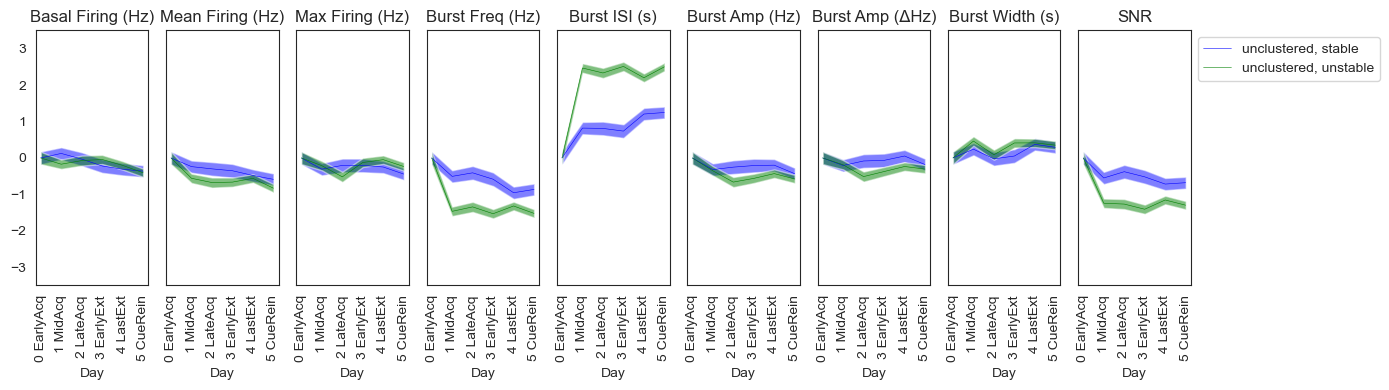

In [514]:
### PLOT THE CHANGE IN CASCADE MEASURES IN TRACKED NEURONS, SPLIT BY STABLE AND UNSTABLE CELLS
fig, axs = plt.subplots(1, len(measurements), figsize=(14, 4), sharey='row')

top_threshold = np.nanquantile(stabilityscores, 2/3)  # Top 1/3
bottom_threshold = np.nanquantile(stabilityscores, 1/3)  # Bottom 1/3

groups = [
    ('unclustered, stable', stabilityscores_rein >= top_threshold, np.all(tracked_clusterids_alldays[:, 0, reference_day_indices] == 0, axis=1)),
    ('unclustered, unstable', stabilityscores_rein <= bottom_threshold, np.all(tracked_clusterids_alldays[:, 0, reference_day_indices] == 0, axis=1))
]

colors = ['b', 'g', 'r', 'm']  # Define distinct colors for each group

for g, (label, stability_condition, cluster_condition) in enumerate(groups):
    mask = np.logical_and(stability_condition, cluster_condition)
    
    for m, measurement in enumerate(measurements):
        # Calculate means and SEMs for each day
        means = []
        sems = []

        for d, day in enumerate(sorted(daysforbaselines)):
            values_day = tracked_cmeasures_alldays[:, m, d][mask].copy()
            values_comparison = tracked_cmeasures_alldays[:, m, reference_day_index][mask].copy()
            values_day, values_comparison = synchronize_nans(values_day, values_comparison)
            values = (values_day - np.nanmean(values_comparison)) / np.nanstd(values_day)
            
            means.append(np.nanmean(values))
            sems.append(np.nanstd(values) / np.sqrt(np.count_nonzero(values > -1000)))
            
        means = means - means[0]

        # Create DataFrame for plotting
        plot_df = pd.DataFrame({'Day': sorted(daysforbaselines), 'Mean': means, 'SEM': sems})

        # Plot line plot with error regions
        ax = axs[m]
        sns.lineplot(x='Day', y='Mean', data=plot_df, ax=ax, marker=None, linewidth=0.4, label=label, color=colors[g])
        ax.fill_between(plot_df['Day'], plot_df['Mean'] - plot_df['SEM'], plot_df['Mean'] + plot_df['SEM'], alpha=0.5, color=colors[g], edgecolor = None)
        ax.set_title(measurement)
        ax.set_xlabel('Day')
        ax.set_ylabel(None)
        ax.set_ylim(-3.5, 3.5)
        ax.set_xticks(plot_df['Day'])  # Set the positions of the ticks
        ax.set_xticklabels(plot_df['Day'], rotation=90)  # Set the labels for the ticks

        # Add legend outside the plot
        if m == len(measurements)-1:
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles=handles, labels=labels, loc='upper left', bbox_to_anchor=(1, 1))
        else:
            ax.get_legend().set_visible(False)

plt.tight_layout()
plt.show()

# fig.savefig(os.path.join(basedir, 'Results', 'CascadeMeasures_Tracked_UnclusteredStability.PDF'), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', 'CascadeMeasures_Tracked_UnclusteredStability.png'), format='PNG')

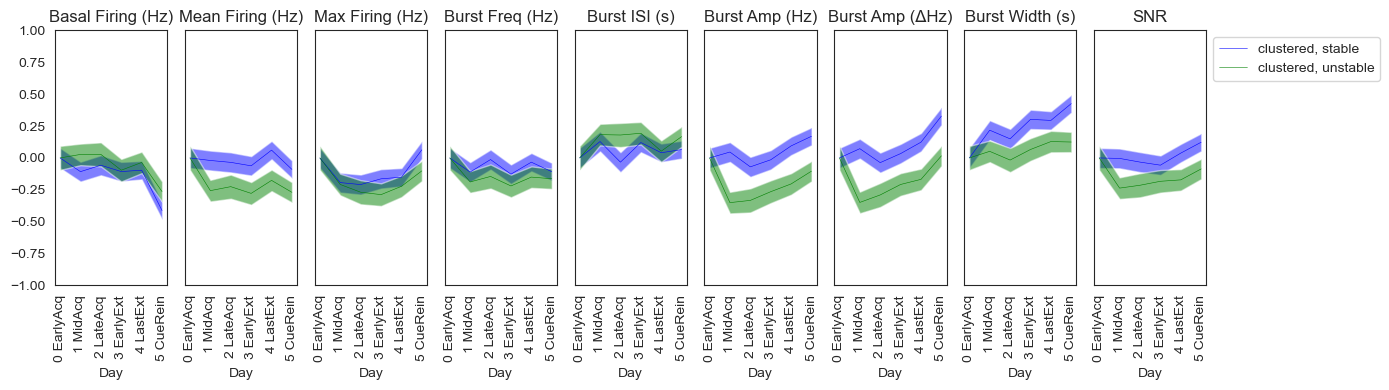

In [515]:
### PLOT THE CHANGE IN CASCADE MEASURES IN TRACKED NEURONS, SPLIT BY STABLE AND UNSTABLE CELLS
fig, axs = plt.subplots(1, len(measurements), figsize=(14, 4), sharey='row')

top_threshold = np.nanquantile(stabilityscores, 2/3)  # Top 1/3
bottom_threshold = np.nanquantile(stabilityscores, 1/3)  # Bottom 1/3

groups = [
    ('clustered, stable', stabilityscores_rein >= top_threshold, np.any(tracked_clusterids_alldays[:, 0, reference_day_indices] > 0, axis=1)),
    ('clustered, unstable', stabilityscores_rein <= bottom_threshold, np.any(tracked_clusterids_alldays[:, 0, reference_day_indices] > 0, axis=1))
]

colors = ['b', 'g', 'r', 'm']  # Define distinct colors for each group

for g, (label, stability_condition, cluster_condition) in enumerate(groups):
    mask = np.logical_and(stability_condition, cluster_condition)
    
    for m, measurement in enumerate(measurements):
        # Calculate means and SEMs for each day
        means = []
        sems = []

        for d, day in enumerate(sorted(daysforbaselines)):
            values_day = tracked_cmeasures_alldays[:, m, d][mask].copy()
            values_comparison = tracked_cmeasures_alldays[:, m, reference_day_index][mask].copy()
            values_day, values_comparison = synchronize_nans(values_day, values_comparison)
            values = (values_day - np.nanmean(values_comparison)) / np.nanstd(values_day)
            
            means.append(np.nanmean(values))
            sems.append(np.nanstd(values) / np.sqrt(np.count_nonzero(values > -1000)))
            
        means = means - means[0]

        # Create DataFrame for plotting
        plot_df = pd.DataFrame({'Day': sorted(daysforbaselines), 'Mean': means, 'SEM': sems})

        # Plot line plot with error regions
        ax = axs[m]
        sns.lineplot(x='Day', y='Mean', data=plot_df, ax=ax, marker=None, linewidth=0.4, label=label, color=colors[g])
        ax.fill_between(plot_df['Day'], plot_df['Mean'] - plot_df['SEM'], plot_df['Mean'] + plot_df['SEM'], alpha=0.5, color=colors[g], edgecolor = None)
        ax.set_title(measurement)
        ax.set_xlabel('Day')
        ax.set_ylabel(None)
        ax.set_ylim(-1, 1)
        ax.set_xticks(plot_df['Day'])  # Set the positions of the ticks
        ax.set_xticklabels(plot_df['Day'], rotation=90)  # Set the labels for the ticks

        # Add legend outside the plot
        if m == len(measurements)-1:
            handles, labels = ax.get_legend_handles_labels()
            ax.legend(handles=handles, labels=labels, loc='upper left', bbox_to_anchor=(1, 1))
        else:
            ax.get_legend().set_visible(False)

plt.tight_layout()
plt.show()

# fig.savefig(os.path.join(basedir, 'Results', 'CascadeMeasures_Tracked_ClusteredStability.PDF'), format='PDF')
# fig.savefig(os.path.join(basedir, 'Results', 'CascadeMeasures_Tracked_ClusteredStability.png'), format='PNG')

In [516]:
### Correlate change in cascade measure by response stability
# fig, axs = plt.subplots(1, len(measurements), figsize=(12, 1.5), sharey='col')

for m, measurement in enumerate(measurements):
        
    values_day = tracked_cmeasures_alldays[:, m, baseline_day_index].copy()
    values_comparison = tracked_cmeasures_alldays[:, m, reference_day_index].copy()
    values_day, values_comparison = synchronize_nans(values_day, values_comparison)

    values_day_z = (values_day - np.nanmean(values_day)) / np.nanstd(values_day)
    values_comparison_z = (values_comparison - np.nanmean(values_day)) / np.nanstd(values_comparison)
        
    nan_mask = np.isnan(stabilityscores_rein) | np.isnan(values_comparison_z)

    print(measurement, stats.pearsonr((values_comparison_z[~nan_mask]-values_day_z[~nan_mask]), stabilityscores_rein[~nan_mask]))
    
    ax = axs[m]
    
# plt.tight_layout()
# plt.show()

# Basal Firing (Hz) PearsonRResult(statistic=-0.007948606470050553, pvalue=0.8679525687638155)
# Mean Firing (Hz) PearsonRResult(statistic=0.11739207486854564, pvalue=0.013741255840674874)
# Max Firing (Hz) PearsonRResult(statistic=0.038973197682477645, pvalue=0.4147901452994826)
# Burst Freq (Hz) PearsonRResult(statistic=0.08642212144103406, pvalue=0.07013488366185447)
# Burst ISI (s) PearsonRResult(statistic=-0.06967611114233124, pvalue=0.14452252976536561)
# Burst Amp (Hz) PearsonRResult(statistic=0.12823385264243503, pvalue=0.007074172971413983)
# Burst Amp (ΔHz) PearsonRResult(statistic=0.13279210090326507, pvalue=0.0052722314579097046)
# Burst Width (s) PearsonRResult(statistic=0.0738263235052139, pvalue=0.12203223600551823)
# SNR PearsonRResult(statistic=0.1308248713249705, pvalue=0.00599197995052416)

Basal Firing (Hz) PearsonRResult(statistic=-0.007948606470050553, pvalue=0.8679525687638155)
Mean Firing (Hz) PearsonRResult(statistic=0.11739207486854564, pvalue=0.013741255840674874)
Max Firing (Hz) PearsonRResult(statistic=0.038973197682477645, pvalue=0.4147901452994826)
Burst Freq (Hz) PearsonRResult(statistic=0.08642212144103406, pvalue=0.07013488366185447)
Burst ISI (s) PearsonRResult(statistic=-0.06967611114233124, pvalue=0.14452252976536561)
Burst Amp (Hz) PearsonRResult(statistic=0.12823385264243503, pvalue=0.007074172971413983)
Burst Amp (ΔHz) PearsonRResult(statistic=0.13279210090326507, pvalue=0.0052722314579097046)
Burst Width (s) PearsonRResult(statistic=0.0738263235052139, pvalue=0.12203223600551823)
SNR PearsonRResult(statistic=0.1308248713249705, pvalue=0.00599197995052416)


Basal Firing (Hz) PearsonRResult(statistic=0.025651973824738005, pvalue=0.4079047949021743)
Mean Firing (Hz) PearsonRResult(statistic=0.10744543270044207, pvalue=0.0005091214952425776)
Max Firing (Hz) PearsonRResult(statistic=0.09691788879760277, pvalue=0.0017265318484878801)
Burst Freq (Hz) PearsonRResult(statistic=0.11373938698082656, pvalue=0.00023248746178736404)
Burst ISI (s) PearsonRResult(statistic=-0.0942792254590568, pvalue=0.002304191823112054)
Burst Amp (Hz) PearsonRResult(statistic=0.08375156289658447, pvalue=0.006803510353743345)
Burst Amp (ΔHz) PearsonRResult(statistic=0.08600934483175651, pvalue=0.005443646927899971)
Burst Width (s) PearsonRResult(statistic=-0.015281401938265, pvalue=0.6220424999060784)
SNR PearsonRResult(statistic=0.1174741327030858, pvalue=0.00014323701264771455)


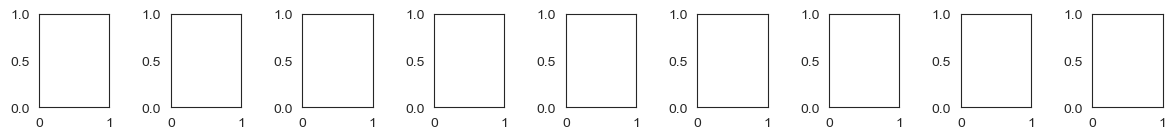

In [517]:
### Correlate change in cascade measure by auc response
fig, axs = plt.subplots(1, len(measurements), figsize=(12, 1.5), sharey='col')

for m, measurement in enumerate(measurements):
        
    values_day = tracked_cmeasures_alldays[:, m, baseline_day_index].copy()
    values_comparison = tracked_cmeasures_alldays[:, m, reference_day_index].copy()
    values_day, values_comparison = synchronize_nans(values_day, values_comparison)

    values_day_z = (values_day - np.nanmean(values_day)) / np.nanstd(values_day)
    values_comparison_z = (values_comparison - np.nanmean(values_day)) / np.nanstd(values_comparison)
        
    nan_mask = np.isnan(tracked_aucpvals_alldays[:, 0, reference_day_index]) | np.isnan(values_comparison_z)

    print(measurement, stats.pearsonr((values_comparison_z[~nan_mask]-values_day_z[~nan_mask]), 
                         tracked_aucpvals_alldays[:, 0, reference_day_index][~nan_mask]))
    
    ax = axs[m]
    
plt.tight_layout()
plt.show()

# Basal Firing (Hz) PearsonRResult(statistic=0.025651973824738005, pvalue=0.4079047949021743)
# Mean Firing (Hz) PearsonRResult(statistic=0.10744543270044207, pvalue=0.0005091214952425776)
# Max Firing (Hz) PearsonRResult(statistic=0.09691788879760277, pvalue=0.0017265318484878801)
# Burst Freq (Hz) PearsonRResult(statistic=0.11373938698082656, pvalue=0.00023248746178736404)
# Burst ISI (s) PearsonRResult(statistic=-0.0942792254590568, pvalue=0.002304191823112054)
# Burst Amp (Hz) PearsonRResult(statistic=0.08375156289658447, pvalue=0.006803510353743345)
# Burst Amp (ΔHz) PearsonRResult(statistic=0.08600934483175651, pvalue=0.005443646927899971)
# Burst Width (s) PearsonRResult(statistic=-0.015281401938265, pvalue=0.6220424999060784)
# SNR PearsonRResult(statistic=0.1174741327030858, pvalue=0.00014323701264771455)

Basal Firing (Hz) PearsonRResult(statistic=-0.04099314520834723, pvalue=0.18588090885042763)
Mean Firing (Hz) PearsonRResult(statistic=0.11310060845771212, pvalue=0.00025220412209028164)
Max Firing (Hz) PearsonRResult(statistic=0.11970534627042657, pvalue=0.00010651459822004177)
Burst Freq (Hz) PearsonRResult(statistic=0.09683528867522377, pvalue=0.0017423852221799725)
Burst ISI (s) PearsonRResult(statistic=-0.08638991631317754, pvalue=0.00524024968774461)
Burst Amp (Hz) PearsonRResult(statistic=0.1474080004397485, pvalue=1.7438312998955163e-06)
Burst Amp (ΔHz) PearsonRResult(statistic=0.18892268353533304, pvalue=7.772921677004666e-10)
Burst Width (s) PearsonRResult(statistic=0.013153509782736422, pvalue=0.6713410011309986)
SNR PearsonRResult(statistic=0.152562017044823, pvalue=7.415083412244454e-07)


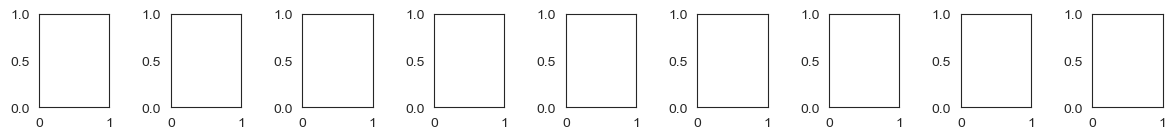

In [518]:
### Correlate change in cascade measure by mean response
fig, axs = plt.subplots(1, len(measurements), figsize=(12, 1.5), sharey='col')

for m, measurement in enumerate(measurements):
        
    values_day = tracked_cmeasures_alldays[:, m, baseline_day_index].copy()
    values_comparison = tracked_cmeasures_alldays[:, m, reference_day_index].copy()
    values_day, values_comparison = synchronize_nans(values_day, values_comparison)

    values_day_z = (values_day - np.nanmean(values_day)) / np.nanstd(values_day)
    values_comparison_z = (values_comparison - np.nanmean(values_day)) / np.nanstd(values_comparison)
        
    nan_mask = np.isnan(tracked_aucpvals_alldays[:, 0, reference_day_index]) | np.isnan(values_comparison_z)

    print(measurement, stats.pearsonr((values_comparison_z[~nan_mask]-values_day_z[~nan_mask]), 
                         np.nanmean(tracked_popevents_alldays[:, aucfirstframe:auclastframe, reference_day_index], axis = 1)[~nan_mask]))
    
    ax = axs[m]
    
plt.tight_layout()
plt.show()

clustered Basal Firing (Hz) -0.04478057641914564 0.40769977364437865
unclustered Basal Firing (Hz) 0.13975499512242967 0.1744473607318311
clustered Mean Firing (Hz) 0.08651043516726128 0.10922341498891537
unclustered Mean Firing (Hz) 0.17838074236428486 0.08206159933259938
clustered Max Firing (Hz) 0.044796403278763705 0.4075338998059249
unclustered Max Firing (Hz) -0.003720588729624434 0.9713008877059252
clustered Burst Freq (Hz) 0.041131006903640306 0.44700853961363246
unclustered Burst Freq (Hz) 0.18869566601618376 0.06559358094725992
clustered Burst ISI (s) -0.04126307655097633 0.4455496310842775
unclustered Burst ISI (s) -0.1519072854075264 0.13954882410232117
clustered Burst Amp (Hz) 0.1298921104509775 0.015926663776758502
unclustered Burst Amp (Hz) 0.08524671301417826 0.40891347213761636
clustered Burst Amp (ΔHz) 0.1508032050345521 0.00506534536074848
unclustered Burst Amp (ΔHz) -0.006756366030511746 0.9479095342372683
clustered Burst Width (s) 0.09335046028614646 0.083832691124

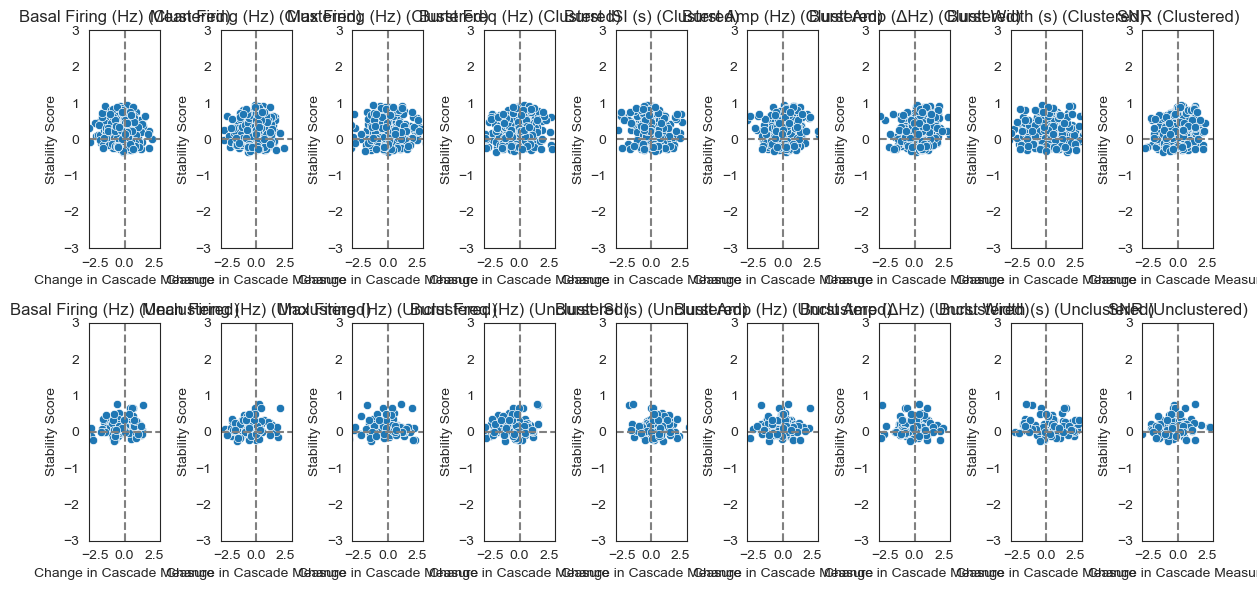

In [519]:
### Correlate change in cascade measure by response stability
fig, axs = plt.subplots(2, len(measurements), figsize=(12, 6), sharey='col')

# Define masks for clustered and unclustered neurons
clustered_mask = np.any(tracked_clusterids_alldays[:, 0, reference_day_indices] > 0, axis=1)
unclustered_mask = np.all(tracked_clusterids_alldays[:, 0, reference_day_indices] == 0, axis=1)

for m, measurement in enumerate(measurements):
    # Process for clustered neurons
    values_day = tracked_cmeasures_alldays[:, m, baseline_day_index][clustered_mask].copy()
    values_comparison = tracked_cmeasures_alldays[:, m, reference_day_index][clustered_mask].copy()
    values_day, values_comparison = synchronize_nans(values_day, values_comparison)

    values_day_z = (values_day - np.nanmean(values_day)) / np.nanstd(values_day)
    values_comparison_z = (values_comparison - np.nanmean(values_day)) / np.nanstd(values_comparison)

    nan_mask = np.isnan(stabilityscores_rein[clustered_mask]) | np.isnan(values_comparison_z)
    rval, pval = stats.pearsonr((values_comparison_z[~nan_mask] - values_day_z[~nan_mask]), stabilityscores_rein[clustered_mask][~nan_mask])
    print('clustered', measurement, rval, pval)
    
    # Plot for clustered neurons
    ax = axs[0, m]
    sns.scatterplot(x=(values_comparison_z[~nan_mask] - values_day_z[~nan_mask]), y=stabilityscores_rein[clustered_mask][~nan_mask], ax=ax)
    ax.set_title(f'{measurement} (Clustered)')
    ax.set_xlabel('Change in Cascade Measure')
    ax.set_ylabel('Stability Score')
    ax.axhline(0, color='gray', linestyle='--')
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

    # Process for unclustered neurons
    values_day = tracked_cmeasures_alldays[:, m, baseline_day_index][unclustered_mask].copy()
    values_comparison = tracked_cmeasures_alldays[:, m, reference_day_index][unclustered_mask].copy()
    values_day, values_comparison = synchronize_nans(values_day, values_comparison)

    values_day_z = (values_day - np.nanmean(values_day)) / np.nanstd(values_day)
    values_comparison_z = (values_comparison - np.nanmean(values_day)) / np.nanstd(values_comparison)

    nan_mask = np.isnan(stabilityscores_rein[unclustered_mask]) | np.isnan(values_comparison_z)
    rval, pval = stats.pearsonr((values_comparison_z[~nan_mask] - values_day_z[~nan_mask]), stabilityscores_rein[unclustered_mask][~nan_mask])
    print('unclustered', measurement, rval, pval)
    
    # Plot for unclustered neurons
    ax = axs[1, m]
    sns.scatterplot(x=(values_comparison_z[~nan_mask] - values_day_z[~nan_mask]), y=stabilityscores_rein[unclustered_mask][~nan_mask], ax=ax)
    ax.set_title(f'{measurement} (Unclustered)')
    ax.set_xlabel('Change in Cascade Measure')
    ax.set_ylabel('Stability Score')
    ax.axhline(0, color='gray', linestyle='--')
    ax.axvline(0, color='gray', linestyle='--')
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

plt.tight_layout()
plt.show()

# CORRELATE DATA WITH BEHAVIOR

In [520]:
### EXTRACT LEVER PRESSES FOR EACH ANIMAL
active_presses_animal = {}
activetimeout_presses_animal = {}
activeall_presses_animal = {}
for basedir, day, animal, fov in iterate_dirs(basedir, sorted(days)):
    if day not in active_presses_animal:
        active_presses_animal[day] = {}
        activetimeout_presses_animal[day] = {}
        activeall_presses_animal[day] = {}
    active_presses_animal[day][animal], activetimeout_presses_animal[day][animal] = analyze_single_session(os.path.join(basedir, day, animal, fov), 'window_size', 'pre_window_size')
    activeall_presses_animal[day][animal] = np.sort(np.hstack((active_presses_animal[day][animal], activetimeout_presses_animal[day][animal])))
            

5 CueRein CTL1 FOV1_tracked
5 CueRein ER-L1 FOV1_tracked
5 CueRein ER-L2 FOV1_tracked
5 CueRein IG-19 FOV2_tracked
5 CueRein LCDD-PGa-T1 FOV1_tracked
5 CueRein LCDD-PGa-T2 FOV1_tracked
5 CueRein LCDD-PGa-T3 FOV1_tracked
5 CueRein LCDD-PGa-T4 FOV1_tracked
5 CueRein LCDD-PGa-T5 FOV1_tracked
5 CueRein LCDD-PGa1 FOV1_tracked
5 CueRein LCDD-PGa3 FOV1_tracked
5 CueRein LCDD-PGa4 FOV1_tracked
5 CueRein LCDD-PGa5 FOV1_tracked
5 CueRein LCDD-PGa6 FOV1_tracked
5 CueRein PGa-T1 FOV1_tracked
5 CueRein PGa-T2 FOV1_tracked
5 CueRein PGa-T3 FOV1_tracked
6 DrugRein CTL1 FOV1_tracked
6 DrugRein ER-L1 FOV1_tracked
6 DrugRein ER-L2 FOV1_tracked
6 DrugRein IG-19 FOV2_tracked
6 DrugRein LCDD-PGa-T1 FOV1_tracked
6 DrugRein LCDD-PGa-T2 FOV1_tracked
6 DrugRein LCDD-PGa-T3 FOV1_tracked
6 DrugRein LCDD-PGa-T4 FOV1_tracked
6 DrugRein LCDD-PGa-T5 FOV1_tracked
6 DrugRein LCDD-PGa1 FOV1_tracked
6 DrugRein LCDD-PGa3 FOV1_tracked
6 DrugRein LCDD-PGa4 FOV1_tracked
6 DrugRein LCDD-PGa6 FOV1_tracked
6 DrugRein PGa-T1 FO

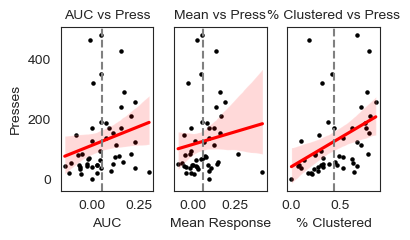

In [523]:
fig, axs = plt.subplots(1, 3, figsize=(4, 2.5), sharey='row')

reference_days = ['5 CueRein', '6 DrugRein', '7 TMTRein']

auc_press_array = np.nan*np.ones((1, 2))
popevents_press_array = np.nan*np.ones((1, 2))
clustered_press_array = np.nan*np.ones((1, 2))

for basedir, day, animal, fov in iterate_dirs(basedir, sorted(reference_days)):
    print(day, animal, fov)
    mean_auc = np.nanmean(aucpvals_fov[day][animal][fov][:, 0])
    mean_popevents = np.nanmean(popevents_fov[day][animal][fov][:, aucfirstframe:auclastframe])
    percent_clustered = np.count_nonzero(clusterids_fov[day][animal][fov] > 0)/ np.count_nonzero(clusterids_fov[day][animal][fov] > -1)
    num_presses = np.shape(activeall_presses_animal[day][animal])[0]
    
    auc_press_array = np.vstack((auc_press_array, np.hstack((mean_auc, num_presses))))
    popevents_press_array = np.vstack((popevents_press_array, np.hstack((mean_popevents, num_presses))))
    clustered_press_array = np.vstack((clustered_press_array, np.hstack((percent_clustered, num_presses))))
    
auc_press_array = auc_press_array[1:, :]
popevents_press_array = popevents_press_array[1:, :]
clustered_press_array = clustered_press_array[1:, :]

print('Correlation,  auc vs presses: ', stats.spearmanr(auc_press_array[:, 0], auc_press_array[:, 1]))
print('Correlation,  mean response vs presses: ', stats.spearmanr(popevents_press_array[:, 0], popevents_press_array[:, 1]))
print('Correlation,  % clustered vs presses: ', stats.spearmanr(clustered_press_array[:, 0], clustered_press_array[:, 1]))

ax = axs[0]
ax.scatter(x = auc_press_array[:, 0], y = auc_press_array[:, 1], s = 5, color = 'k')
sns.regplot(x = auc_press_array[:, 0], y = auc_press_array[:, 1], \
            ax = ax, color = 'r', scatter = False)
ax.axvline(np.nanmean(auc_press_array[:, 0]), color = 'gray', linestyle = '--')
ax.set_title('AUC vs Press', fontsize = 10)
ax.set_ylabel('Presses')
ax.set_xlabel('AUC')

ax = axs[1]
ax.scatter(x = popevents_press_array[:, 0], y = popevents_press_array[:, 1], s = 5, color = 'k')
sns.regplot(x = popevents_press_array[:, 0], y = popevents_press_array[:, 1], \
            ax = ax, color = 'r', scatter = False)
ax.axvline(np.nanmean(popevents_press_array[:, 0]), color = 'gray', linestyle = '--')
ax.set_title('Mean vs Press', fontsize = 10)
ax.set_xlabel('Mean Response')

ax = axs[2]
ax.scatter(x = clustered_press_array[:, 0], y = clustered_press_array[:, 1], s = 5, color = 'k')
sns.regplot(x = clustered_press_array[:, 0], y = clustered_press_array[:, 1], \
            ax = ax, color = 'r', scatter = False)
ax.axvline(np.nanmean(clustered_press_array[:, 0]), color = 'gray', linestyle = '--')
ax.set_title('% Clustered vs Press', fontsize = 10)
ax.set_xlabel('% Clustered')

fig.tight_layout()

# Correlation,  auc vs presses:  SignificanceResult(statistic=0.33962649426774677, pvalue=0.016965480254120275)
# Correlation,  mean response vs presses:  SignificanceResult(statistic=0.25196448748409456, pvalue=0.08072058298557025)
# Correlation,  % clustered vs presses:  SignificanceResult(statistic=0.5239820417120631, pvalue=0.00011155121442171269)

Cluster =  0 ,  % vs presses:  SignificanceResult(statistic=-0.5239820417120631, pvalue=0.00011155121442171269)
Cluster =  1 ,  % vs presses:  SignificanceResult(statistic=0.5404633153972316, pvalue=6.106054427232534e-05)
Cluster =  2 ,  % vs presses:  SignificanceResult(statistic=0.08062047189649037, pvalue=0.5818583281102743)


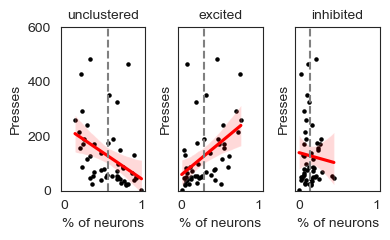

In [524]:
fig, axs = plt.subplots(1, 3, figsize=(4, 2.5), sharey='row', sharex = 'row')

reference_days = ['5 CueRein', '6 DrugRein', '7 TMTRein']

for rt in range(3):
    clustered_press_array = np.nan*np.ones((1, 2))

    for basedir, day, animal, fov in iterate_dirs(basedir, sorted(reference_days)):
        if rt == 0:
            percent_clustered = np.count_nonzero(clusterids_fov[day][animal][fov] == 0)/ np.count_nonzero(clusterids_fov[day][animal][fov] > -1)
            title = 'unclustered'
        elif rt == 1:
            percent_clustered = np.count_nonzero(np.logical_and(clusterids_fov[day][animal][fov] > 0, clusterids_fov[day][animal][fov] < 5))/np.count_nonzero(clusterids_fov[day][animal][fov] > -1)
            title = 'excited'
        elif rt == 2:
            percent_clustered = np.count_nonzero(clusterids_fov[day][animal][fov] >= 5)/ np.count_nonzero(clusterids_fov[day][animal][fov] > -1)
            title = 'inhibited'
        num_presses = np.shape(activeall_presses_animal[day][animal])[0]
        clustered_press_array = np.vstack((clustered_press_array, np.hstack((percent_clustered, num_presses))))

    clustered_press_array = clustered_press_array[1:, :]
    
    print('Cluster = ', rt, ',  % vs presses: ', stats.spearmanr(clustered_press_array[:, 0], clustered_press_array[:, 1]))


    ax = axs[rt]
    ax.scatter(x = clustered_press_array[:, 0], y = clustered_press_array[:, 1], s = 5, color = 'k')
    sns.regplot(x = clustered_press_array[:, 0], y = clustered_press_array[:, 1], \
                ax = ax, color = 'r', scatter = False)
    ax.axvline(np.nanmean(clustered_press_array[:, 0]), color = 'gray', linestyle = '--')
    ax.set_title(title, fontsize = 10)
    ax.set_xlabel('% of neurons')
    ax.set_ylim(0, 600)
    if c == 0:
        ax.set_ylabel('Presses')

fig.tight_layout()

# Cluster =  0 ,  % vs presses:  SignificanceResult(statistic=-0.5239820417120631, pvalue=0.00011155121442171269)
# Cluster =  1 ,  % vs presses:  SignificanceResult(statistic=0.5404633153972316, pvalue=6.106054427232534e-05)
# Cluster =  2 ,  % vs presses:  SignificanceResult(statistic=0.08062047189649037, pvalue=0.5818583281102743)

Cluster =  0 ,  % vs presses:  SignificanceResult(statistic=-0.5239820417120631, pvalue=0.00011155121442171269)
Cluster =  1 ,  % vs presses:  SignificanceResult(statistic=0.4572468541623185, pvalue=0.0009566841434787565)
Cluster =  2 ,  % vs presses:  SignificanceResult(statistic=0.5101123172587313, pvalue=0.0001809282235036302)
Cluster =  3 ,  % vs presses:  SignificanceResult(statistic=0.29916305052063463, pvalue=0.03678264712410371)
Cluster =  4 ,  % vs presses:  SignificanceResult(statistic=0.0638748540126772, pvalue=0.662817071558927)
Cluster =  5 ,  % vs presses:  SignificanceResult(statistic=-0.2618036916768366, pvalue=0.06919331864058278)
Cluster =  6 ,  % vs presses:  SignificanceResult(statistic=0.35987484597765795, pvalue=0.011091034431191039)
Cluster =  7 ,  % vs presses:  SignificanceResult(statistic=0.2098995838883792, pvalue=0.1477433900342778)
Cluster =  8 ,  % vs presses:  SignificanceResult(statistic=-0.26011949037630283, pvalue=0.07106778619542299)


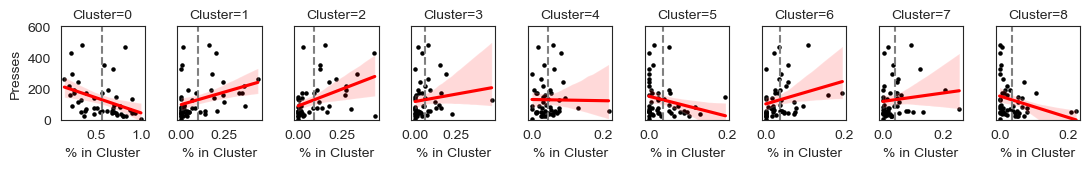

In [525]:
### PROPORTION OF CELLS IN EACH CLUSTER CORRELATED WITH LEVER PRESSING

fig, axs = plt.subplots(1, numclusters, figsize=(numclusters+2, 1.8), sharey='row')

reference_days = ['5 CueRein', '6 DrugRein', '7 TMTRein']

for c in range(numclusters):
    clustered_press_array = np.nan*np.ones((1, 2))

    for basedir, day, animal, fov in iterate_dirs(basedir, sorted(reference_days)):
        
        percent_clustered = np.count_nonzero(clusterids_fov[day][animal][fov] == c)/ np.count_nonzero(clusterids_fov[day][animal][fov] > -1)
        num_presses = np.shape(activeall_presses_animal[day][animal])[0]
        clustered_press_array = np.vstack((clustered_press_array, np.hstack((percent_clustered, num_presses))))

    clustered_press_array = clustered_press_array[1:, :]

    print('Cluster = ', c, ',  % vs presses: ', stats.spearmanr(clustered_press_array[:, 0], clustered_press_array[:, 1]))


    ax = axs[c]
    ax.scatter(x = clustered_press_array[:, 0], y = clustered_press_array[:, 1], s = 5, color = 'k')
    sns.regplot(x = clustered_press_array[:, 0], y = clustered_press_array[:, 1], \
                ax = ax, color = 'r', scatter = False)
    ax.axvline(np.nanmean(clustered_press_array[:, 0]), color = 'gray', linestyle = '--')
    ax.set_title('Cluster=%s'%c, fontsize = 10)
    ax.set_xlabel('% in Cluster')
    ax.set_ylim(0, 600)
    if c == 0:
        ax.set_ylabel('Presses')

fig.tight_layout()

# Cluster =  0 ,  % vs presses:  SignificanceResult(statistic=-0.5239820417120631, pvalue=0.00011155121442171269)
# Cluster =  1 ,  % vs presses:  SignificanceResult(statistic=0.4572468541623185, pvalue=0.0009566841434787565)
# Cluster =  2 ,  % vs presses:  SignificanceResult(statistic=0.5101123172587313, pvalue=0.0001809282235036302)
# Cluster =  3 ,  % vs presses:  SignificanceResult(statistic=0.29916305052063463, pvalue=0.03678264712410371)
# Cluster =  4 ,  % vs presses:  SignificanceResult(statistic=0.0638748540126772, pvalue=0.662817071558927)
# Cluster =  5 ,  % vs presses:  SignificanceResult(statistic=-0.2618036916768366, pvalue=0.06919331864058278)
# Cluster =  6 ,  % vs presses:  SignificanceResult(statistic=0.35987484597765795, pvalue=0.011091034431191039)
# Cluster =  7 ,  % vs presses:  SignificanceResult(statistic=0.2098995838883792, pvalue=0.1477433900342778)
# Cluster =  8 ,  % vs presses:  SignificanceResult(statistic=-0.26011949037630283, pvalue=0.07106778619542299)

Cluster =  1 ,  % vs presses:  SignificanceResult(statistic=0.37667350662985716, pvalue=0.008318607003982134)
Cluster =  2 ,  % vs presses:  SignificanceResult(statistic=0.44191720989619593, pvalue=0.001663108893884312)
Cluster =  3 ,  % vs presses:  SignificanceResult(statistic=0.055975687069068886, pvalue=0.7055161257891007)
Cluster =  4 ,  % vs presses:  SignificanceResult(statistic=-0.3738802329197735, pvalue=0.008851726852154096)
Cluster =  5 ,  % vs presses:  SignificanceResult(statistic=-0.32663477750496284, pvalue=0.023458388227974396)
Cluster =  6 ,  % vs presses:  SignificanceResult(statistic=0.1670564235472508, pvalue=0.25642170098085193)
Cluster =  7 ,  % vs presses:  SignificanceResult(statistic=-0.00794365213742995, pvalue=0.9572655469021959)
Cluster =  8 ,  % vs presses:  SignificanceResult(statistic=-0.491498332525108, pvalue=0.0003888664758262572)


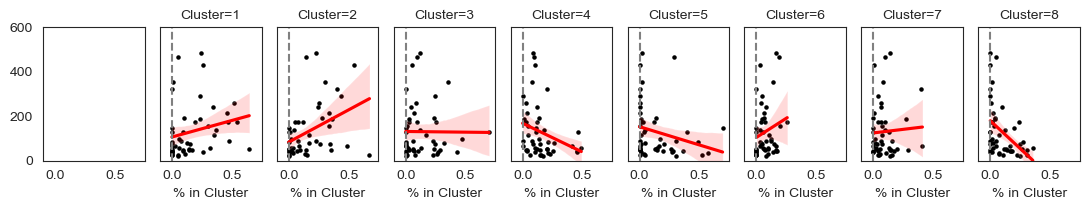

In [526]:
### PROPORTION OF CELLS IN A CLUSTER, OUT OF ONLY CLUSTERED CELLS, CORRELATED WITH LEVER PRESSING
fig, axs = plt.subplots(1, numclusters, figsize=(numclusters+2, 2.2), sharey='row', sharex='row')

reference_days = ['5 CueRein', '6 DrugRein', '7 TMTRein']

for c in range(1, numclusters):
    clustered_press_array = np.nan*np.ones((1, 2))

    for basedir, day, animal, fov in iterate_dirs(basedir, sorted(reference_days)):
        
        try:
            percent_clustered = np.count_nonzero(clusterids_fov[day][animal][fov] == c)/ np.count_nonzero(clusterids_fov[day][animal][fov] > 0)
        except ZeroDivisionError:
            continue
        num_presses = np.shape(activeall_presses_animal[day][animal])[0]
        clustered_press_array = np.vstack((clustered_press_array, np.hstack((percent_clustered, num_presses))))

    clustered_press_array = clustered_press_array[1:, :]

    print('Cluster = ', c, ',  % vs presses: ', stats.spearmanr(clustered_press_array[:, 0], clustered_press_array[:, 1]))


    ax = axs[c]
    ax.scatter(x = clustered_press_array[:, 0], y = clustered_press_array[:, 1], s = 5, color = 'k')
    sns.regplot(x = clustered_press_array[:, 0], y = clustered_press_array[:, 1], \
                ax = ax, color = 'r', scatter = False)
    ax.axvline(0, color = 'gray', linestyle = '--')
    ax.set_title('Cluster=%s'%c, fontsize = 10)
    ax.set_xlabel('% in Cluster')
    ax.set_xlim(-0.1, 0.75)
    ax.set_ylim(0, 600)
    if c == 0:
        ax.set_ylabel('Presses')

fig.tight_layout()

Correlation,  Basal Firing (Hz) : SignificanceResult(statistic=0.049999999999999996, pvalue=0.8540995521297436)
Correlation,  Mean Firing (Hz) : SignificanceResult(statistic=0.5323529411764706, pvalue=0.033768622960234626)
Correlation,  Max Firing (Hz) : SignificanceResult(statistic=0.4852941176470588, pvalue=0.05671771428191195)
Correlation,  Burst Freq (Hz) : SignificanceResult(statistic=0.6470588235294118, pvalue=0.0067420770071798634)
Correlation,  Burst ISI (s) : SignificanceResult(statistic=-0.6088235294117647, pvalue=0.012315203198246456)
Correlation,  Burst Amp (Hz) : SignificanceResult(statistic=0.5, pvalue=0.04858028888702393)
Correlation,  Burst Amp (ΔHz) : SignificanceResult(statistic=0.5941176470588235, pvalue=0.015232400876327998)
Correlation,  Burst Width (s) : SignificanceResult(statistic=-0.17352941176470588, pvalue=0.5204075144487408)
Correlation,  SNR : SignificanceResult(statistic=0.6411764705882352, pvalue=0.007434419082533941)


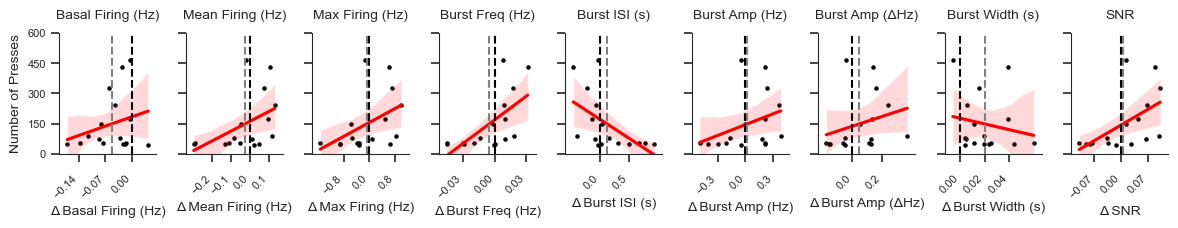

In [554]:
### CORRELATE PRESSES TO CHANGES IN TRACKED!!! CASCADE MEASUREMENTS. DOES SO BY TAKING THE ***AVERAGE*** TRACKED!!! NEURONAL CMEASURE FOR CUE REIN, SUBTRACTING DAY EARLY ACQ, 
### AND CORRELATING TO PRESSES ON EACH REFERENCE DAY
fig, axs = plt.subplots(1, len(measurements), figsize=(12, 2.2), sharey='col')
reference_days = ['5 CueRein']
cmeasures_press_array = np.nan*np.ones((1, len(measurements)+1))

for basedir, day, animal, fov in iterate_dirs(basedir, sorted(reference_days)):
    
    num_presses = np.shape(activeall_presses_animal[day][animal])[0]
    
    # Get data for day 1 (index 0) and day 5 (index 5)
    day1_data = tracked_cmeasures_fov[animal][0, :, :]  # neurons x cmeasures
    day5_data = tracked_cmeasures_fov[animal][5, :, :]  # neurons x cmeasures
    
    # Find neurons that have valid data (not NaN) in both day 1 and day 5
    # Check across all cmeasures for each neuron
    day1_valid = ~np.any(np.isnan(day1_data), axis=1)  # neurons with valid data on day 1
    day5_valid = ~np.any(np.isnan(day5_data), axis=1)  # neurons with valid data on day 5
    both_days_valid = day1_valid & day5_valid  # neurons valid in both days
d
    
    animal_array = np.hstack((change_cmeasures, num_presses))
    cmeasures_press_array = np.vstack((cmeasures_press_array, animal_array))

cmeasures_press_array = cmeasures_press_array[1:, :]

for m, measurement in enumerate(measurements):
    nan_mask = np.any(np.isnan(cmeasures_press_array), axis = 1)
    ax = axs[m]
    ax.scatter(x = cmeasures_press_array[:, m][~nan_mask], y = cmeasures_press_array[:, -1][~nan_mask], s = 5, color = 'k')
    sns.regplot(x = cmeasures_press_array[:, m][~nan_mask], y = cmeasures_press_array[:, -1][~nan_mask], \
                ax = ax, color = 'r', scatter = False)
    ax.axvline(np.nanmean(cmeasures_press_array[:, m]), color = 'gray', linestyle = '--')
    ax.axvline(0, color = 'black', linestyle = '--')
    
    # Set y-axis ticks for publication format
    ax.set_ylim(0, 600)
    ax.set_yticks([0, 150, 300, 450, 600])
    
    # Set x-axis ticks based on data range
    x_data = cmeasures_press_array[:, m][~nan_mask]
    if len(x_data) > 0:  # Only set ticks if there's valid data
        x_min, x_max = np.min(x_data), np.max(x_data)
        x_range = x_max - x_min
        
        # Create approximately 3-4 ticks across the data range (fewer to avoid overlap)
        if x_range > 0:
            tick_spacing = x_range / 3
            # Round tick spacing to a nice number
            magnitude = 10 ** np.floor(np.log10(tick_spacing))
            nice_spacing = magnitude * np.round(tick_spacing / magnitude)
            
            # Generate ticks
            first_tick = np.ceil(x_min / nice_spacing) * nice_spacing
            last_tick = np.floor(x_max / nice_spacing) * nice_spacing
            x_ticks = np.arange(first_tick, last_tick + nice_spacing/2, nice_spacing)
            
            ax.set_xticks(x_ticks)
            ax.set_xlim(x_min - 0.1 * x_range, x_max + 0.1 * x_range)
            
            # Rotate x-tick labels to avoid overlap
            plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    if m > 0:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel('Number of Presses', fontsize=10)
    
    ax.set_xlabel(f'Δ {measurement}', fontsize=10)
    ax.set_title(measurement, fontsize=10, pad=10)
    
    # Format tick labels and marks - make sure ticks are visible
    ax.tick_params(axis='both', which='major', labelsize=8, 
                   direction='out', length=6, width=1.2,
                   top=False, right=False, left=True, bottom=True)
    ax.tick_params(axis='x', which='major', pad=8)  # Add padding for x-axis labels
    
    # Ensure spines are visible
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    print('Correlation, ', measurement, ':', stats.spearmanr(cmeasures_press_array[:, m][~nan_mask], cmeasures_press_array[:, -1][~nan_mask]))

# Adjust layout with more spacing for x-axis labels
fig.tight_layout(pad=1.5)
plt.subplots_adjust(bottom=0.25)  # Make room for x-axis labels

fig.savefig(os.path.join(basedir, 'Results', 'Tracked CMeasures X Behavior.PDF'), format='PDF')
fig.savefig(os.path.join(basedir, 'Results', 'Tracked CMeasures X Behavior.png'), format='PNG')
plt.show()

# Correlation,  Basal Firing (Hz) : SignificanceResult(statistic=0.3868880536103933, pvalue=0.007904953367893005)
# Correlation,  Mean Firing (Hz) : SignificanceResult(statistic=0.42878393291846667, pvalue=0.002947091030040704)
# Correlation,  Max Firing (Hz) : SignificanceResult(statistic=0.37094537387369286, pvalue=0.011152018571693208)
# Correlation,  Burst Freq (Hz) : SignificanceResult(statistic=0.4695675322449096, pvalue=0.000993893606190915)
# Correlation,  Burst ISI (s) : SignificanceResult(statistic=-0.4688260122571561, pvalue=0.001014961025544982)
# Correlation,  Burst Amp (Hz) : SignificanceResult(statistic=0.24433083596478128, pvalue=0.10174848767620788)
# Correlation,  Burst Amp (ΔHz) : SignificanceResult(statistic=0.32237581467583803, pvalue=0.02888961931503123)
# Correlation,  Burst Width (s) : SignificanceResult(statistic=-0.14132135099935625, pvalue=0.34884954011870695)
# Correlation,  SNR : SignificanceResult(statistic=0.3978254734297576, pvalue=0.006182405730867069)

Correlation,  Basal Firing (Hz) : SignificanceResult(statistic=0.10906773545068985, pvalue=5.88337223915352e-09)
Correlation,  Mean Firing (Hz) : SignificanceResult(statistic=0.2595759469327228, pvalue=7.530513088705196e-45)
Correlation,  Max Firing (Hz) : SignificanceResult(statistic=0.14035368224746084, pvalue=6.174269930492158e-14)
Correlation,  Burst Freq (Hz) : SignificanceResult(statistic=0.2293482562268951, pvalue=3.938344595734591e-35)
Correlation,  Burst ISI (s) : SignificanceResult(statistic=-0.23646578145291358, pvalue=2.6737885991076505e-37)
Correlation,  Burst Amp (Hz) : SignificanceResult(statistic=0.19571124808141077, pvalue=7.4349181702429e-26)
Correlation,  Burst Amp (ΔHz) : SignificanceResult(statistic=0.16683650423274404, pvalue=3.9332654314485587e-19)
Correlation,  Burst Width (s) : SignificanceResult(statistic=0.011514046612513273, pvalue=0.540143685909322)
Correlation,  SNR : SignificanceResult(statistic=0.23342794140337667, pvalue=2.2986247153494584e-36)


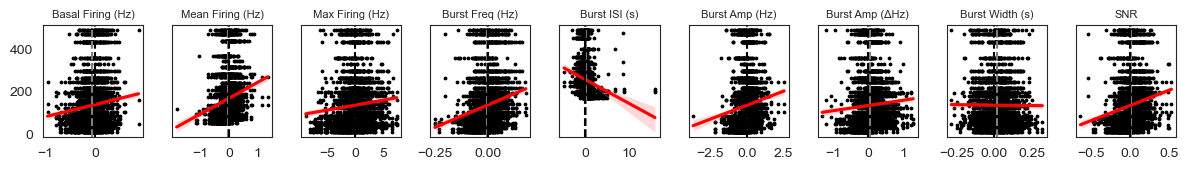

In [528]:
### CORRELATE PRESSES TO CHANGES IN CASCADE MEASUREMENTS. DOES SO BY TAKING ***INDIVIDUAL*** NEURONAL CMEASURES FOR CUE REIN, SUBTRACTING DAY EARLY ACQ, 
### AND CORRELATING TO PRESSES ON EACH REFERENCE DAY (ONE DATAPOINT PER NEURON)
fig, axs = plt.subplots(1, len(measurements), figsize=(12, 1.8), sharey='col')
reference_days = ['5 CueRein', '6 DrugRein', '7 TMTRein']
cmeasures_press_array_neurons = np.nan*np.ones((1, len(measurements)+1))

for basedir, day, animal, fov in iterate_dirs(basedir, sorted(reference_days)):
    
    num_presses = np.shape(activeall_presses_animal[day][animal])[0]
    
    # Get data for day 1 (index 0) and day 5 (index 5)
    day1_data = tracked_cmeasures_fov[animal][0, :, :]  # neurons x cmeasures
    day5_data = tracked_cmeasures_fov[animal][5, :, :]  # neurons x cmeasures
    
    # Find neurons that have valid data (not NaN) in both day 1 and day 5
    day1_valid = ~np.any(np.isnan(day1_data), axis=1)  # neurons with valid data on day 1
    day5_valid = ~np.any(np.isnan(day5_data), axis=1)  # neurons with valid data on day 5
    both_days_valid = day1_valid & day5_valid  # neurons valid in both days
    
    # Only use neurons that were tracked in both days
    if np.sum(both_days_valid) > 0:  # Check if any neurons are valid in both days
        day1_filtered = day1_data[both_days_valid, :]  # valid_neurons x cmeasures
        day5_filtered = day5_data[both_days_valid, :]  # valid_neurons x cmeasures
        
        # Calculate change for each individual neuron
        change_cmeasures_per_neuron = day5_filtered - day1_filtered  # valid_neurons x cmeasures
        
        # Create an array for this FOV with one row per valid neuron
        num_valid_neurons = np.sum(both_days_valid)
        fov_array = np.zeros((num_valid_neurons, len(measurements)+1))
        fov_array[:, :-1] = change_cmeasures_per_neuron  # cmeasures for each neuron
        fov_array[:, -1] = num_presses  # same number of presses for all neurons in this FOV
        
        # Add to the main array
        cmeasures_press_array_neurons = np.vstack((cmeasures_press_array_neurons, fov_array))

# Remove the initial NaN row
cmeasures_press_array_neurons = cmeasures_press_array_neurons[1:, :]

# Plot the results
for m, measurement in enumerate(measurements):
    nan_mask = np.any(np.isnan(cmeasures_press_array_neurons), axis = 1)
    ax = axs[m]
    ax.scatter(x = cmeasures_press_array_neurons[:, m][~nan_mask], 
               y = cmeasures_press_array_neurons[:, -1][~nan_mask], s = 3, color = 'k')
    sns.regplot(x = cmeasures_press_array_neurons[:, m][~nan_mask], 
                y = cmeasures_press_array_neurons[:, -1][~nan_mask], \
                ax = ax, color = 'r', scatter = False)
    ax.axvline(np.nanmean(cmeasures_press_array_neurons[:, m]), color = 'gray', linestyle = '--')
    ax.axvline(0, color = 'black', linestyle = '--')
    if m > 0:
        ax.set_yticklabels([])
    ax.set_title(measurement, fontsize = 8)
    print('Correlation, ', measurement, ':', stats.spearmanr(cmeasures_press_array_neurons[:, m][~nan_mask], 
                                                            cmeasures_press_array_neurons[:, -1][~nan_mask]) )

fig.tight_layout()
plt.show()

# Correlation,  Basal Firing (Hz) : SignificanceResult(statistic=0.10906773545068985, pvalue=5.88337223915352e-09)
# Correlation,  Mean Firing (Hz) : SignificanceResult(statistic=0.2595759469327228, pvalue=7.530513088705196e-45)
# Correlation,  Max Firing (Hz) : SignificanceResult(statistic=0.14035368224746084, pvalue=6.174269930492158e-14)
# Correlation,  Burst Freq (Hz) : SignificanceResult(statistic=0.2293482562268951, pvalue=3.938344595734591e-35)
# Correlation,  Burst ISI (s) : SignificanceResult(statistic=-0.23646578145291358, pvalue=2.6737885991076505e-37)
# Correlation,  Burst Amp (Hz) : SignificanceResult(statistic=0.19571124808141077, pvalue=7.4349181702429e-26)
# Correlation,  Burst Amp (ΔHz) : SignificanceResult(statistic=0.16683650423274404, pvalue=3.9332654314485587e-19)
# Correlation,  Burst Width (s) : SignificanceResult(statistic=0.011514046612513273, pvalue=0.540143685909322)
# Correlation,  SNR : SignificanceResult(statistic=0.23342794140337667, pvalue=2.2986247153494584e-36

Correlation, cluster:  0 Basal Firing (Hz) : SignificanceResult(statistic=0.12336691071209899, pvalue=0.516025116989854)
Correlation, cluster:  0 Mean Firing (Hz) : SignificanceResult(statistic=0.15487911073095037, pvalue=0.4138082234938997)
Correlation, cluster:  0 Max Firing (Hz) : SignificanceResult(statistic=0.08179762558084823, pvalue=0.6674079495906057)
Correlation, cluster:  0 Burst Freq (Hz) : SignificanceResult(statistic=0.1917550894764147, pvalue=0.31004991790935627)
Correlation, cluster:  0 Burst ISI (s) : SignificanceResult(statistic=-0.18773225543145497, pvalue=0.32050095583375576)
Correlation, cluster:  0 Burst Amp (Hz) : SignificanceResult(statistic=0.05497873194778324, pvalue=0.7729229963156956)
Correlation, cluster:  0 Burst Amp (ΔHz) : SignificanceResult(statistic=-0.006034251067439623, pvalue=0.974753735682401)
Correlation, cluster:  0 Burst Width (s) : SignificanceResult(statistic=0.4116700172675476, pvalue=0.023803954927222655)
Correlation, cluster:  0 SNR : Signif

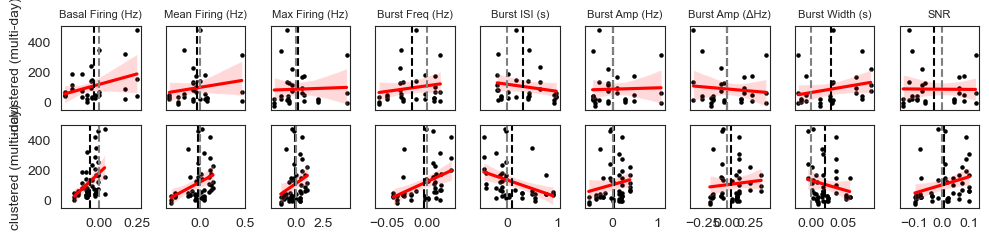

In [529]:
### SEPARATED BY CLUSTERED AND NOT CLUSTERED NEURONS
### CORRELATE PRESSES TO CHANGES IN CASCADE MEASUREMENTS WITH MULTI-DAY CLUSTERING (NO Z-SCORE)

fig, axs = plt.subplots(2, len(measurements), figsize=(10, 2.5), sharey='col', sharex = 'col')
reference_days = ['5 CueRein', '6 DrugRein', '7 TMTRein']

# Reference day indices for clustering (adjust these to match your reference_day_indices)
reference_day_indices = [5, 6, 7]  # Days to check for consistent clustering

for c in range(2):
    cmeasures_press_array = np.nan*np.ones((1, len(measurements)+1))
    
    for basedir, day, animal, fov in iterate_dirs(basedir, sorted(reference_days)):
        num_presses = np.shape(activeall_presses_animal[day][animal])[0]
        
        # Get clustering data for reference days for this animal
        reference_clusterids = tracked_clusterids_fov[animal][reference_day_indices, :]  # reference_days x neurons
        
        # Apply clustering mask - consistent across multiple reference days
        if c == 0:
            cluster_mask = np.all(reference_clusterids == 0, axis=0)  # axis=0 for neurons    
        elif c == 1:
            cluster_mask = np.any(reference_clusterids != 0, axis=0)
        
        if not np.any(cluster_mask):  # Skip if no neurons meet clustering criteria
            continue
        
        # Process each measurement separately
        change_cmeasures = []
        
        for m in range(len(measurements)):
            # Get day 1 and day 5 data for this measurement and clustered neurons
            values_day1 = tracked_cmeasures_fov[animal][0, cluster_mask, m]  # day 1
            values_day5 = tracked_cmeasures_fov[animal][5, cluster_mask, m]  # day 5
            
            # Synchronize NaNs between day1 and day5
            values_day1, values_day5 = synchronize_nans(values_day1, values_day5)
            
            if len(values_day1[~np.isnan(values_day1)]) == 0:  # Skip if no valid data
                change_cmeasures.append(np.nan)
                continue
            
            # Simple subtraction (no z-score normalization)
            mean_day1 = np.nanmean(values_day1)
            mean_day5 = np.nanmean(values_day5)
            
            # Calculate change (day 5 - day 1)
            change = mean_day5 - mean_day1
            change_cmeasures.append(change)
        
        change_cmeasures = np.array(change_cmeasures)
        animal_array = np.hstack((change_cmeasures, num_presses))
        cmeasures_press_array = np.vstack((cmeasures_press_array, animal_array))
        
    cmeasures_press_array = cmeasures_press_array[1:, :]
    
    for m, measurement in enumerate(measurements):
        nan_mask = np.any(np.isnan(cmeasures_press_array), axis = 1)
        ax = axs[c, m]
        ax.scatter(x = cmeasures_press_array[:, m][~nan_mask], y = cmeasures_press_array[:, -1][~nan_mask], s = 5, color = 'k')
        sns.regplot(x = cmeasures_press_array[:, m][~nan_mask], y = cmeasures_press_array[:, -1][~nan_mask], \
                    ax = ax, color = 'r', scatter = False)
        ax.axvline(np.nanmean(cmeasures_press_array[:, m]), color = 'black', linestyle = '--')
        ax.axvline(0, color = 'gray', linestyle = '--')
        if m > 0:
            ax.set_yticklabels([])
        else:
            if c == 0:
                ax.set_ylabel('unclustered (multi-day)')
            else:
                ax.set_ylabel('clustered (multi-day)')
        if c == 0:
            ax.set_title(measurement, fontsize = 8)
        print('Correlation, cluster: ', c, measurement, ':', stats.spearmanr(cmeasures_press_array[:, m][~nan_mask], cmeasures_press_array[:, -1][~nan_mask]) )

fig.tight_layout()
plt.show()


Correlation, cluster:  0 Basal Firing (Hz) : SignificanceResult(statistic=-0.01607757287641701, pvalue=0.7858708304939729)
Correlation, cluster:  0 Mean Firing (Hz) : SignificanceResult(statistic=0.08411498961952282, pvalue=0.1545058090891884)
Correlation, cluster:  0 Max Firing (Hz) : SignificanceResult(statistic=0.12471208914920547, pvalue=0.03438772223837401)
Correlation, cluster:  0 Burst Freq (Hz) : SignificanceResult(statistic=0.13714514201562478, pvalue=0.01989509630941892)
Correlation, cluster:  0 Burst ISI (s) : SignificanceResult(statistic=-0.1424915042873236, pvalue=0.015520272845451105)
Correlation, cluster:  0 Burst Amp (Hz) : SignificanceResult(statistic=0.11115327304821021, pvalue=0.059568771974735195)
Correlation, cluster:  0 Burst Amp (ΔHz) : SignificanceResult(statistic=0.10967511875696359, pvalue=0.06306046453357327)
Correlation, cluster:  0 Burst Width (s) : SignificanceResult(statistic=0.11561569691825686, pvalue=0.049983133068344524)
Correlation, cluster:  0 SNR :

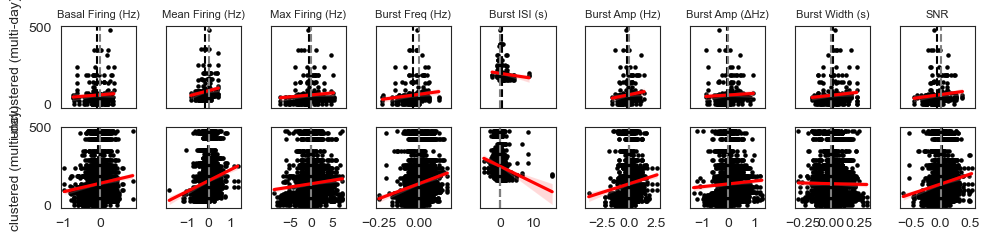

In [530]:
### SEPARATED BY CLUSTERED AND NOT CLUSTERED NEURONS
### CORRELATE PRESSES TO CHANGES IN CASCADE MEASUREMENTS - INDIVIDUAL NEURONS WITH MULTI-DAY CLUSTERING (NO Z-SCORE)

fig, axs = plt.subplots(2, len(measurements), figsize=(10, 2.5), sharey='col', sharex = 'col')
reference_days = ['5 CueRein', '6 DrugRein', '7 TMTRein']

# Reference day indices for clustering (adjust these to match your reference_day_indices)
reference_day_indices = [5, 6, 7]  # Days to check for consistent clustering

for c in range(2):
    cmeasures_press_array_neurons = np.nan*np.ones((1, len(measurements)+1))
    
    for basedir, day, animal, fov in iterate_dirs(basedir, sorted(reference_days)):
        num_presses = np.shape(activeall_presses_animal[day][animal])[0]
        
        # Get clustering data for reference days for this animal
        reference_clusterids = tracked_clusterids_fov[animal][reference_day_indices, :]  # reference_days x neurons
        
        # Apply clustering mask - consistent across multiple reference days
        if c == 0:
            cluster_mask = np.all(reference_clusterids == 0, axis=0)  # axis=0 for neurons    
        elif c == 1:
            cluster_mask = np.any(reference_clusterids != 0, axis=0)
        
        if not np.any(cluster_mask):  # Skip if no neurons meet clustering criteria
            continue
        
        # Get day 1 and day 5 data for all measurements and filtered neurons
        day1_data = tracked_cmeasures_fov[animal][0, cluster_mask, :]  # filtered_neurons x cmeasures
        day5_data = tracked_cmeasures_fov[animal][5, cluster_mask, :]  # filtered_neurons x cmeasures
        
        # Process each neuron individually
        valid_neurons = []
        change_cmeasures_per_neuron = []
        
        for neuron_idx in range(day1_data.shape[0]):  # Loop through filtered neurons
            neuron_changes = []
            valid_neuron = True
            
            for m in range(len(measurements)):
                # Get this neuron's day 1 and day 5 values for this measurement
                val_day1 = day1_data[neuron_idx, m]
                val_day5 = day5_data[neuron_idx, m]
                
                # Check if both values are valid (not NaN)
                if np.isnan(val_day1) or np.isnan(val_day5):
                    valid_neuron = False
                    break
                
                # Calculate change for this neuron and measurement
                change = val_day5 - val_day1
                neuron_changes.append(change)
            
            if valid_neuron:
                change_cmeasures_per_neuron.append(neuron_changes)
                valid_neurons.append(neuron_idx)
        
        # Convert to array and create FOV array
        if len(change_cmeasures_per_neuron) > 0:
            change_cmeasures_per_neuron = np.array(change_cmeasures_per_neuron)  # valid_neurons x cmeasures
            num_valid_neurons = len(valid_neurons)
            
            # Create array with one row per valid neuron
            fov_array = np.zeros((num_valid_neurons, len(measurements)+1))
            fov_array[:, :-1] = change_cmeasures_per_neuron  # cmeasures for each neuron
            fov_array[:, -1] = num_presses  # same number of presses for all neurons in this FOV
            
            # Add to the main array
            cmeasures_press_array_neurons = np.vstack((cmeasures_press_array_neurons, fov_array))
        
    # Remove the initial NaN row
    cmeasures_press_array_neurons = cmeasures_press_array_neurons[1:, :]
    
    for m, measurement in enumerate(measurements):
        nan_mask = np.any(np.isnan(cmeasures_press_array_neurons), axis = 1)
        ax = axs[c, m]
        ax.scatter(x = cmeasures_press_array_neurons[:, m][~nan_mask], 
                   y = cmeasures_press_array_neurons[:, -1][~nan_mask], s = 5, color = 'k')
        sns.regplot(x = cmeasures_press_array_neurons[:, m][~nan_mask], 
                    y = cmeasures_press_array_neurons[:, -1][~nan_mask], \
                    ax = ax, color = 'r', scatter = False)
        ax.axvline(np.nanmean(cmeasures_press_array_neurons[:, m]), color = 'black', linestyle = '--')
        ax.axvline(0, color = 'gray', linestyle = '--')
        if m > 0:
            ax.set_yticklabels([])
        else:
            if c == 0:
                ax.set_ylabel('unclustered (multi-day)')
            else:
                ax.set_ylabel('clustered (multi-day)')
        if c == 0:
            ax.set_title(measurement, fontsize = 8)
        print('Correlation, cluster: ', c, measurement, ':', 
              stats.spearmanr(cmeasures_press_array_neurons[:, m][~nan_mask], 
                            cmeasures_press_array_neurons[:, -1][~nan_mask]) )

fig.tight_layout()
plt.show()

Correlation, not clustered, Basal Firing (Hz): SignificanceResult(statistic=0.12336691071209899, pvalue=0.516025116989854)
Correlation, not clustered, Mean Firing (Hz): SignificanceResult(statistic=0.15487911073095037, pvalue=0.4138082234938997)
Correlation, not clustered, Max Firing (Hz): SignificanceResult(statistic=0.08179762558084823, pvalue=0.6674079495906057)
Correlation, not clustered, Burst Freq (Hz): SignificanceResult(statistic=0.1917550894764147, pvalue=0.31004991790935627)
Correlation, not clustered, Burst ISI (s): SignificanceResult(statistic=-0.18773225543145497, pvalue=0.32050095583375576)
Correlation, not clustered, Burst Amp (Hz): SignificanceResult(statistic=0.05497873194778324, pvalue=0.7729229963156956)
Correlation, not clustered, Burst Amp (ΔHz): SignificanceResult(statistic=-0.006034251067439623, pvalue=0.974753735682401)
Correlation, not clustered, Burst Width (s): SignificanceResult(statistic=0.4116700172675476, pvalue=0.023803954927222655)
Correlation, not clus

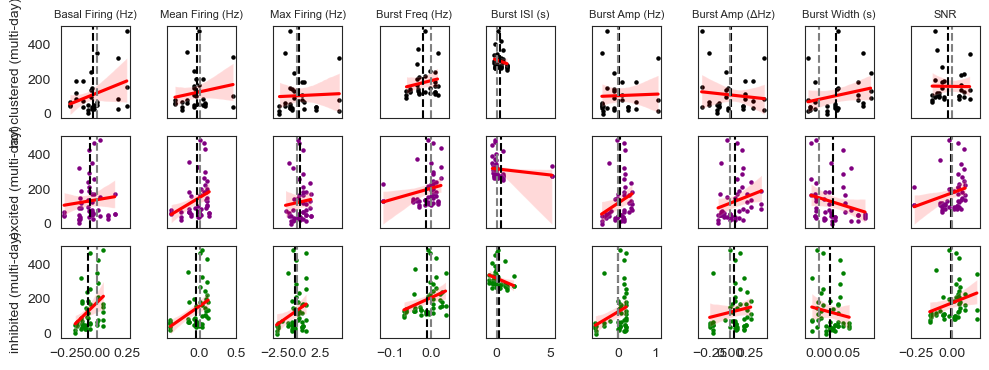

In [531]:
### SEPARATED BY RESPONSE TYPE (NOT CLUSTERED, EXCITED, INHIBITED)
### CORRELATE PRESSES TO CHANGES IN CASCADE MEASUREMENTS - FOV AVERAGES WITH MULTI-DAY CLUSTERING (NO Z-SCORE)

fig, axs = plt.subplots(3, len(measurements), figsize=(10, 3.8), sharey='col', sharex = 'col')
reference_days = ['5 CueRein', '6 DrugRein', '7 TMTRein']

# Reference day indices for clustering (adjust these to match your reference_day_indices)
reference_day_indices = [5, 6, 7]  # Days to check for consistent clustering

# Response type definitions
response_types = [
    {'name': 'not clustered', 'color': 'black', 'condition': lambda x: np.all(x == 0, axis=0)},
    {'name': 'excited', 'color': 'purple', 'condition': lambda x: np.any(np.isin(x, [1, 2, 3, 4]), axis=0)},
    {'name': 'inhibited', 'color': 'green', 'condition': lambda x: np.any(x >= 5, axis=0)}
]

for rt in range(3):
    cmeasures_press_array = np.nan*np.ones((1, len(measurements)+1))
    
    for basedir, day, animal, fov in iterate_dirs(basedir, sorted(reference_days)):
        num_presses = np.shape(activeall_presses_animal[day][animal])[0]
        
        # Get clustering data for reference days for this animal
        reference_clusterids = tracked_clusterids_fov[animal][reference_day_indices, :]  # reference_days x neurons
        
        # Apply response type mask
        rt_mask = response_types[rt]['condition'](reference_clusterids)
        
        if not np.any(rt_mask):  # Skip if no neurons meet response type criteria
            continue
        
        # Process each measurement separately
        change_cmeasures = []
        
        for m in range(len(measurements)):
            # Get day 1 and day 5 data for this measurement and filtered neurons
            values_day1 = tracked_cmeasures_fov[animal][0, rt_mask, m]  # day 1
            values_day5 = tracked_cmeasures_fov[animal][5, rt_mask, m]  # day 5
            
            # Synchronize NaNs between day1 and day5
            values_day1, values_day5 = synchronize_nans(values_day1, values_day5)
            
            if len(values_day1[~np.isnan(values_day1)]) == 0:  # Skip if no valid data
                change_cmeasures.append(np.nan)
                continue
            
            # Simple subtraction (no z-score normalization)
            mean_day1 = np.nanmean(values_day1)
            mean_day5 = np.nanmean(values_day5)
            
            # Calculate change (day 5 - day 1)
            change = mean_day5 - mean_day1
            change_cmeasures.append(change)
        
        change_cmeasures = np.array(change_cmeasures)
        animal_array = np.hstack((change_cmeasures, num_presses))
        cmeasures_press_array = np.vstack((cmeasures_press_array, animal_array))
        
    # Remove the initial NaN row
    cmeasures_press_array = cmeasures_press_array[1:, :]
    
    for m, measurement in enumerate(measurements):
        nan_mask = np.any(np.isnan(cmeasures_press_array), axis = 1)
        ax = axs[rt, m]
        ax.scatter(x = cmeasures_press_array[:, m][~nan_mask], 
                   y = cmeasures_press_array[:, -1][~nan_mask], 
                   s = 5, color = response_types[rt]['color'])
        sns.regplot(x = cmeasures_press_array[:, m][~nan_mask], 
                    y = cmeasures_press_array[:, -1][~nan_mask], \
                    ax = ax, color = 'r', scatter = False)
        ax.axvline(np.nanmean(cmeasures_press_array[:, m]), color = 'black', linestyle = '--')
        ax.axvline(0, color = 'gray', linestyle = '--')
        if m > 0:
            ax.set_yticklabels([])
        else:
            ax.set_ylabel(f'{response_types[rt]["name"]} (multi-day)')
        if rt == 0:
            ax.set_title(measurement, fontsize = 8)
        print(f'Correlation, {response_types[rt]["name"]}, {measurement}:', 
              stats.spearmanr(cmeasures_press_array[:, m][~nan_mask], 
                            cmeasures_press_array[:, -1][~nan_mask]) )

fig.tight_layout()
plt.show()

Correlation, not clustered, Basal Firing (Hz): SignificanceResult(statistic=-0.01607757287641701, pvalue=0.7858708304939729)
Correlation, not clustered, Mean Firing (Hz): SignificanceResult(statistic=0.08411498961952282, pvalue=0.1545058090891884)
Correlation, not clustered, Max Firing (Hz): SignificanceResult(statistic=0.12471208914920547, pvalue=0.03438772223837401)
Correlation, not clustered, Burst Freq (Hz): SignificanceResult(statistic=0.13714514201562478, pvalue=0.01989509630941892)
Correlation, not clustered, Burst ISI (s): SignificanceResult(statistic=-0.1424915042873236, pvalue=0.015520272845451105)
Correlation, not clustered, Burst Amp (Hz): SignificanceResult(statistic=0.11115327304821021, pvalue=0.059568771974735195)
Correlation, not clustered, Burst Amp (ΔHz): SignificanceResult(statistic=0.10967511875696359, pvalue=0.06306046453357327)
Correlation, not clustered, Burst Width (s): SignificanceResult(statistic=0.11561569691825686, pvalue=0.049983133068344524)
Correlation, n

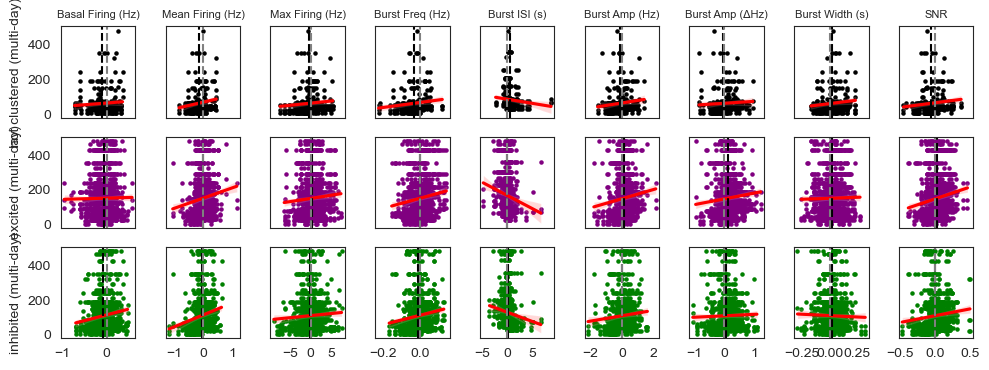

In [532]:
### SEPARATED BY RESPONSE TYPE (NOT CLUSTERED, EXCITED, INHIBITED)
### CORRELATE PRESSES TO CHANGES IN CASCADE MEASUREMENTS - INDIVIDUAL NEURONS WITH MULTI-DAY CLUSTERING (NO Z-SCORE)

fig, axs = plt.subplots(3, len(measurements), figsize=(10, 3.8), sharey='col', sharex = 'col')
reference_days = ['5 CueRein', '6 DrugRein', '7 TMTRein']

# Reference day indices for clustering (adjust these to match your reference_day_indices)
reference_day_indices = [5, 6, 7]  # Days to check for consistent clustering

# Response type definitions
response_types = [
    {'name': 'not clustered', 'color': 'black', 'condition': lambda x: np.all(x == 0, axis=0)},
    {'name': 'excited', 'color': 'purple', 'condition': lambda x: np.any(np.isin(x, [1, 2, 3, 4]), axis=0)},
    {'name': 'inhibited', 'color': 'green', 'condition': lambda x: np.any(x >= 5, axis=0)}
]

for rt in range(3):
    cmeasures_press_array_neurons = np.nan*np.ones((1, len(measurements)+1))
    
    for basedir, day, animal, fov in iterate_dirs(basedir, sorted(reference_days)):
        num_presses = np.shape(activeall_presses_animal[day][animal])[0]
        
        # Get clustering data for reference days for this animal
        reference_clusterids = tracked_clusterids_fov[animal][reference_day_indices, :]  # reference_days x neurons
        
        # Apply response type mask
        rt_mask = response_types[rt]['condition'](reference_clusterids)
        
        if not np.any(rt_mask):  # Skip if no neurons meet response type criteria
            continue
        
        # Get day 1 and day 5 data for all measurements and filtered neurons
        day1_data = tracked_cmeasures_fov[animal][0, rt_mask, :]  # filtered_neurons x cmeasures
        day5_data = tracked_cmeasures_fov[animal][5, rt_mask, :]  # filtered_neurons x cmeasures
        
        # Process each neuron individually
        valid_neurons = []
        change_cmeasures_per_neuron = []
        
        for neuron_idx in range(day1_data.shape[0]):  # Loop through filtered neurons
            neuron_changes = []
            valid_neuron = True
            
            for m in range(len(measurements)):
                # Get this neuron's day 1 and day 5 values for this measurement
                val_day1 = day1_data[neuron_idx, m]
                val_day5 = day5_data[neuron_idx, m]
                
                # Check if both values are valid (not NaN)
                if np.isnan(val_day1) or np.isnan(val_day5):
                    valid_neuron = False
                    break
                
                # Calculate change for this neuron and measurement
                change = val_day5 - val_day1
                neuron_changes.append(change)
            
            if valid_neuron:
                change_cmeasures_per_neuron.append(neuron_changes)
                valid_neurons.append(neuron_idx)
        
        # Convert to array and create FOV array
        if len(change_cmeasures_per_neuron) > 0:
            change_cmeasures_per_neuron = np.array(change_cmeasures_per_neuron)  # valid_neurons x cmeasures
            num_valid_neurons = len(valid_neurons)
            
            # Create array with one row per valid neuron
            fov_array = np.zeros((num_valid_neurons, len(measurements)+1))
            fov_array[:, :-1] = change_cmeasures_per_neuron  # cmeasures for each neuron
            fov_array[:, -1] = num_presses  # same number of presses for all neurons in this FOV
            
            # Add to the main array
            cmeasures_press_array_neurons = np.vstack((cmeasures_press_array_neurons, fov_array))
        
    # Remove the initial NaN row
    cmeasures_press_array_neurons = cmeasures_press_array_neurons[1:, :]
    
    for m, measurement in enumerate(measurements):
        nan_mask = np.any(np.isnan(cmeasures_press_array_neurons), axis = 1)
        ax = axs[rt, m]
        ax.scatter(x = cmeasures_press_array_neurons[:, m][~nan_mask], 
                   y = cmeasures_press_array_neurons[:, -1][~nan_mask], 
                   s = 5, color = response_types[rt]['color'])
        sns.regplot(x = cmeasures_press_array_neurons[:, m][~nan_mask], 
                    y = cmeasures_press_array_neurons[:, -1][~nan_mask], \
                    ax = ax, color = 'r', scatter = False)
        ax.axvline(np.nanmean(cmeasures_press_array_neurons[:, m]), color = 'black', linestyle = '--')
        ax.axvline(0, color = 'gray', linestyle = '--')
        if m > 0:
            ax.set_yticklabels([])
        else:
            ax.set_ylabel(f'{response_types[rt]["name"]} (multi-day)')
        if rt == 0:
            ax.set_title(measurement, fontsize = 8)
        print(f'Correlation, {response_types[rt]["name"]}, {measurement}:', 
              stats.spearmanr(cmeasures_press_array_neurons[:, m][~nan_mask], 
                            cmeasures_press_array_neurons[:, -1][~nan_mask]) )

fig.tight_layout()
plt.show()

Correlation, Cluster 0, Basal Firing (Hz): SignificanceResult(statistic=0.12336691071209899, pvalue=0.516025116989854)
Correlation, Cluster 0, Mean Firing (Hz): SignificanceResult(statistic=0.15487911073095037, pvalue=0.4138082234938997)
Correlation, Cluster 0, Max Firing (Hz): SignificanceResult(statistic=0.08179762558084823, pvalue=0.6674079495906057)
Correlation, Cluster 0, Burst Freq (Hz): SignificanceResult(statistic=0.1917550894764147, pvalue=0.31004991790935627)
Correlation, Cluster 0, Burst ISI (s): SignificanceResult(statistic=-0.18773225543145497, pvalue=0.32050095583375576)
Correlation, Cluster 0, Burst Amp (Hz): SignificanceResult(statistic=0.05497873194778324, pvalue=0.7729229963156956)
Correlation, Cluster 0, Burst Amp (ΔHz): SignificanceResult(statistic=-0.006034251067439623, pvalue=0.974753735682401)
Correlation, Cluster 0, Burst Width (s): SignificanceResult(statistic=0.4116700172675476, pvalue=0.023803954927222655)
Correlation, Cluster 0, SNR: SignificanceResult(stati

Correlation, Cluster 8, Max Firing (Hz): SignificanceResult(statistic=0.2797795638314823, pvalue=0.06920875197030407)
Correlation, Cluster 8, Burst Freq (Hz): SignificanceResult(statistic=0.1710310560614417, pvalue=0.27282426448562347)
Correlation, Cluster 8, Burst ISI (s): SignificanceResult(statistic=-0.16338763275958082, pvalue=0.2951509592289212)
Correlation, Cluster 8, Burst Amp (Hz): SignificanceResult(statistic=0.12774354983704142, pvalue=0.41430618994069635)
Correlation, Cluster 8, Burst Amp (ΔHz): SignificanceResult(statistic=0.14023033047869535, pvalue=0.36977318803125503)
Correlation, Cluster 8, Burst Width (s): SignificanceResult(statistic=-0.2573033586765052, pvalue=0.09577113122195473)
Correlation, Cluster 8, SNR: SignificanceResult(statistic=0.08528849565541806, pvalue=0.5865884865955371)


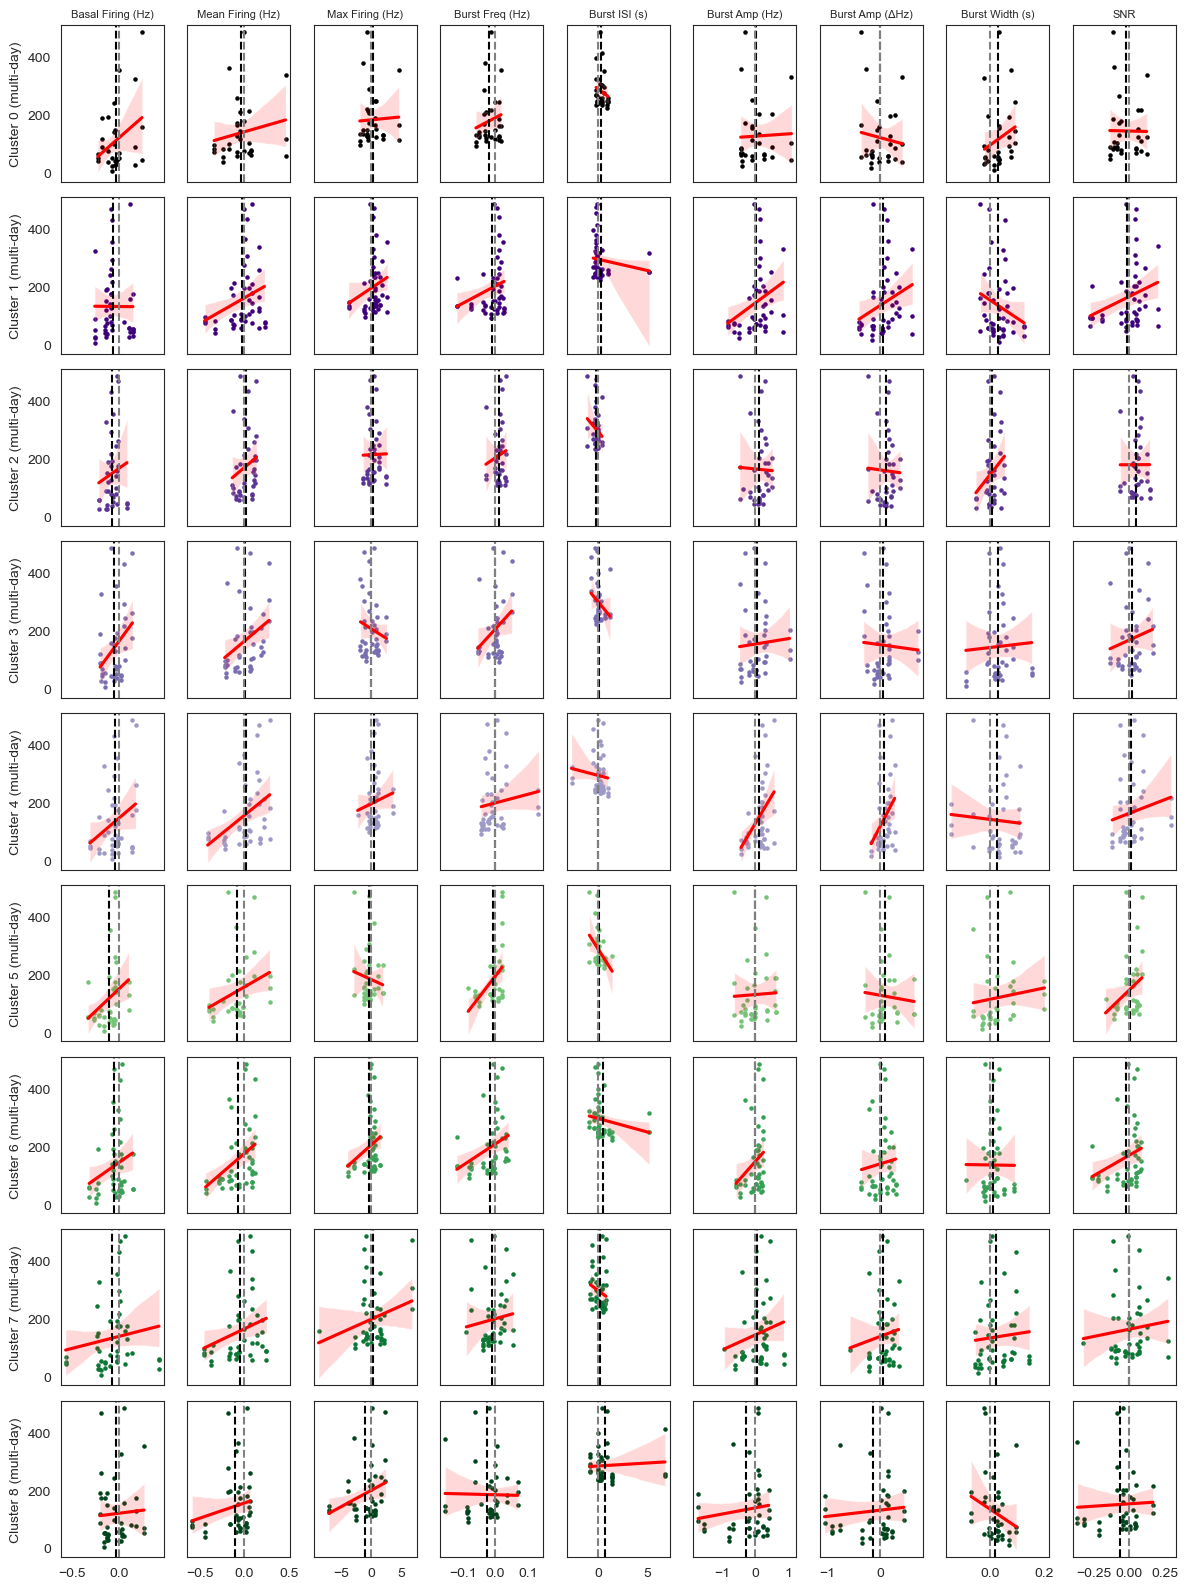

In [533]:
### SEPARATED BY INDIVIDUAL CLUSTERS (0 THROUGH 8)
### CORRELATE PRESSES TO CHANGES IN CASCADE MEASUREMENTS - FOV AVERAGES WITH MULTI-DAY CLUSTERING (NO Z-SCORE)

fig, axs = plt.subplots(9, len(measurements), figsize=(12, 16), sharey='col', sharex = 'col')
reference_days = ['5 CueRein', '6 DrugRein', '7 TMTRein']

# Reference day indices for clustering (adjust these to match your reference_day_indices)
reference_day_indices = [5, 6, 7]  # Days to check for consistent clustering

# Define colors for each cluster
cluster_colors = []
for c in range(1, numclusters):
    if c <= 4:
        color = mcolors.to_hex(plt.cm.Purples(1-(c-1)/6))
    else:
        color = mcolors.to_hex(plt.cm.Greens(0.5+(c-5)/6))
    cluster_colors.append(color)
cluster_colors.insert(0, 'black')

for cluster in range(9):  # Clusters 0 through 8
    cmeasures_press_array = np.nan*np.ones((1, len(measurements)+1))
    
    for basedir, day, animal, fov in iterate_dirs(basedir, sorted(reference_days)):
        num_presses = np.shape(activeall_presses_animal[day][animal])[0]
        
        # Get clustering data for reference days for this animal
        reference_clusterids = tracked_clusterids_fov[animal][reference_day_indices, :]  # reference_days x neurons
        
        # Apply cluster mask - neurons that have this cluster ID on any reference day
        if cluster == 0:
            cluster_mask = np.all(reference_clusterids == 0, axis=0)  # Must be 0 on ALL reference days
        else:
            cluster_mask = np.any(reference_clusterids == cluster, axis=0)  # Must be this cluster on ANY reference day
        
        if not np.any(cluster_mask):  # Skip if no neurons meet cluster criteria
            continue
        
        # Process each measurement separately
        change_cmeasures = []
        
        for m in range(len(measurements)):
            # Get day 1 and day 5 data for this measurement and filtered neurons
            values_day1 = tracked_cmeasures_fov[animal][0, cluster_mask, m]  # day 1
            values_day5 = tracked_cmeasures_fov[animal][5, cluster_mask, m]  # day 5
            
            # Synchronize NaNs between day1 and day5
            values_day1, values_day5 = synchronize_nans(values_day1, values_day5)
            
            if len(values_day1[~np.isnan(values_day1)]) == 0:  # Skip if no valid data
                change_cmeasures.append(np.nan)
                continue
            
            # Simple subtraction (no z-score normalization)
            mean_day1 = np.nanmean(values_day1)
            mean_day5 = np.nanmean(values_day5)
            
            # Calculate change (day 5 - day 1)
            change = mean_day5 - mean_day1
            change_cmeasures.append(change)
        
        change_cmeasures = np.array(change_cmeasures)
        animal_array = np.hstack((change_cmeasures, num_presses))
        cmeasures_press_array = np.vstack((cmeasures_press_array, animal_array))
        
    # Remove the initial NaN row
    cmeasures_press_array = cmeasures_press_array[1:, :]
    
    for m, measurement in enumerate(measurements):
        nan_mask = np.any(np.isnan(cmeasures_press_array), axis = 1)
        ax = axs[cluster, m]
        ax.scatter(x = cmeasures_press_array[:, m][~nan_mask], 
                   y = cmeasures_press_array[:, -1][~nan_mask], 
                   s = 5, color = cluster_colors[cluster])
        sns.regplot(x = cmeasures_press_array[:, m][~nan_mask], 
                    y = cmeasures_press_array[:, -1][~nan_mask], \
                    ax = ax, color = 'r', scatter = False)
        ax.axvline(np.nanmean(cmeasures_press_array[:, m]), color = 'black', linestyle = '--')
        ax.axvline(0, color = 'gray', linestyle = '--')
        if m > 0:
            ax.set_yticklabels([])
        else:
            ax.set_ylabel(f'Cluster {cluster} (multi-day)')
        if cluster == 0:
            ax.set_title(measurement, fontsize = 8)
        print(f'Correlation, Cluster {cluster}, {measurement}:', 
              stats.spearmanr(cmeasures_press_array[:, m][~nan_mask], 
                            cmeasures_press_array[:, -1][~nan_mask]) )

fig.tight_layout()
plt.show()

Correlation, Cluster 0, Basal Firing (Hz): SignificanceResult(statistic=-0.01607757287641701, pvalue=0.7858708304939729)
Correlation, Cluster 0, Mean Firing (Hz): SignificanceResult(statistic=0.08411498961952282, pvalue=0.1545058090891884)
Correlation, Cluster 0, Max Firing (Hz): SignificanceResult(statistic=0.12471208914920547, pvalue=0.03438772223837401)
Correlation, Cluster 0, Burst Freq (Hz): SignificanceResult(statistic=0.13714514201562478, pvalue=0.01989509630941892)
Correlation, Cluster 0, Burst ISI (s): SignificanceResult(statistic=-0.1424915042873236, pvalue=0.015520272845451105)
Correlation, Cluster 0, Burst Amp (Hz): SignificanceResult(statistic=0.11115327304821021, pvalue=0.059568771974735195)
Correlation, Cluster 0, Burst Amp (ΔHz): SignificanceResult(statistic=0.10967511875696359, pvalue=0.06306046453357327)
Correlation, Cluster 0, Burst Width (s): SignificanceResult(statistic=0.11561569691825686, pvalue=0.049983133068344524)
Correlation, Cluster 0, SNR: SignificanceResul

Correlation, Cluster 8, Burst Freq (Hz): SignificanceResult(statistic=0.17194176848964665, pvalue=0.00315101506540636)
Correlation, Cluster 8, Burst ISI (s): SignificanceResult(statistic=-0.1319984192793493, pvalue=0.023840683288667685)
Correlation, Cluster 8, Burst Amp (Hz): SignificanceResult(statistic=0.08742987935826241, pvalue=0.13543152590079227)
Correlation, Cluster 8, Burst Amp (ΔHz): SignificanceResult(statistic=0.12342825373787815, pvalue=0.03470346865611351)
Correlation, Cluster 8, Burst Width (s): SignificanceResult(statistic=-0.08712981725249797, pvalue=0.1367830927202311)
Correlation, Cluster 8, SNR: SignificanceResult(statistic=0.14007333900453886, pvalue=0.016428227532305256)


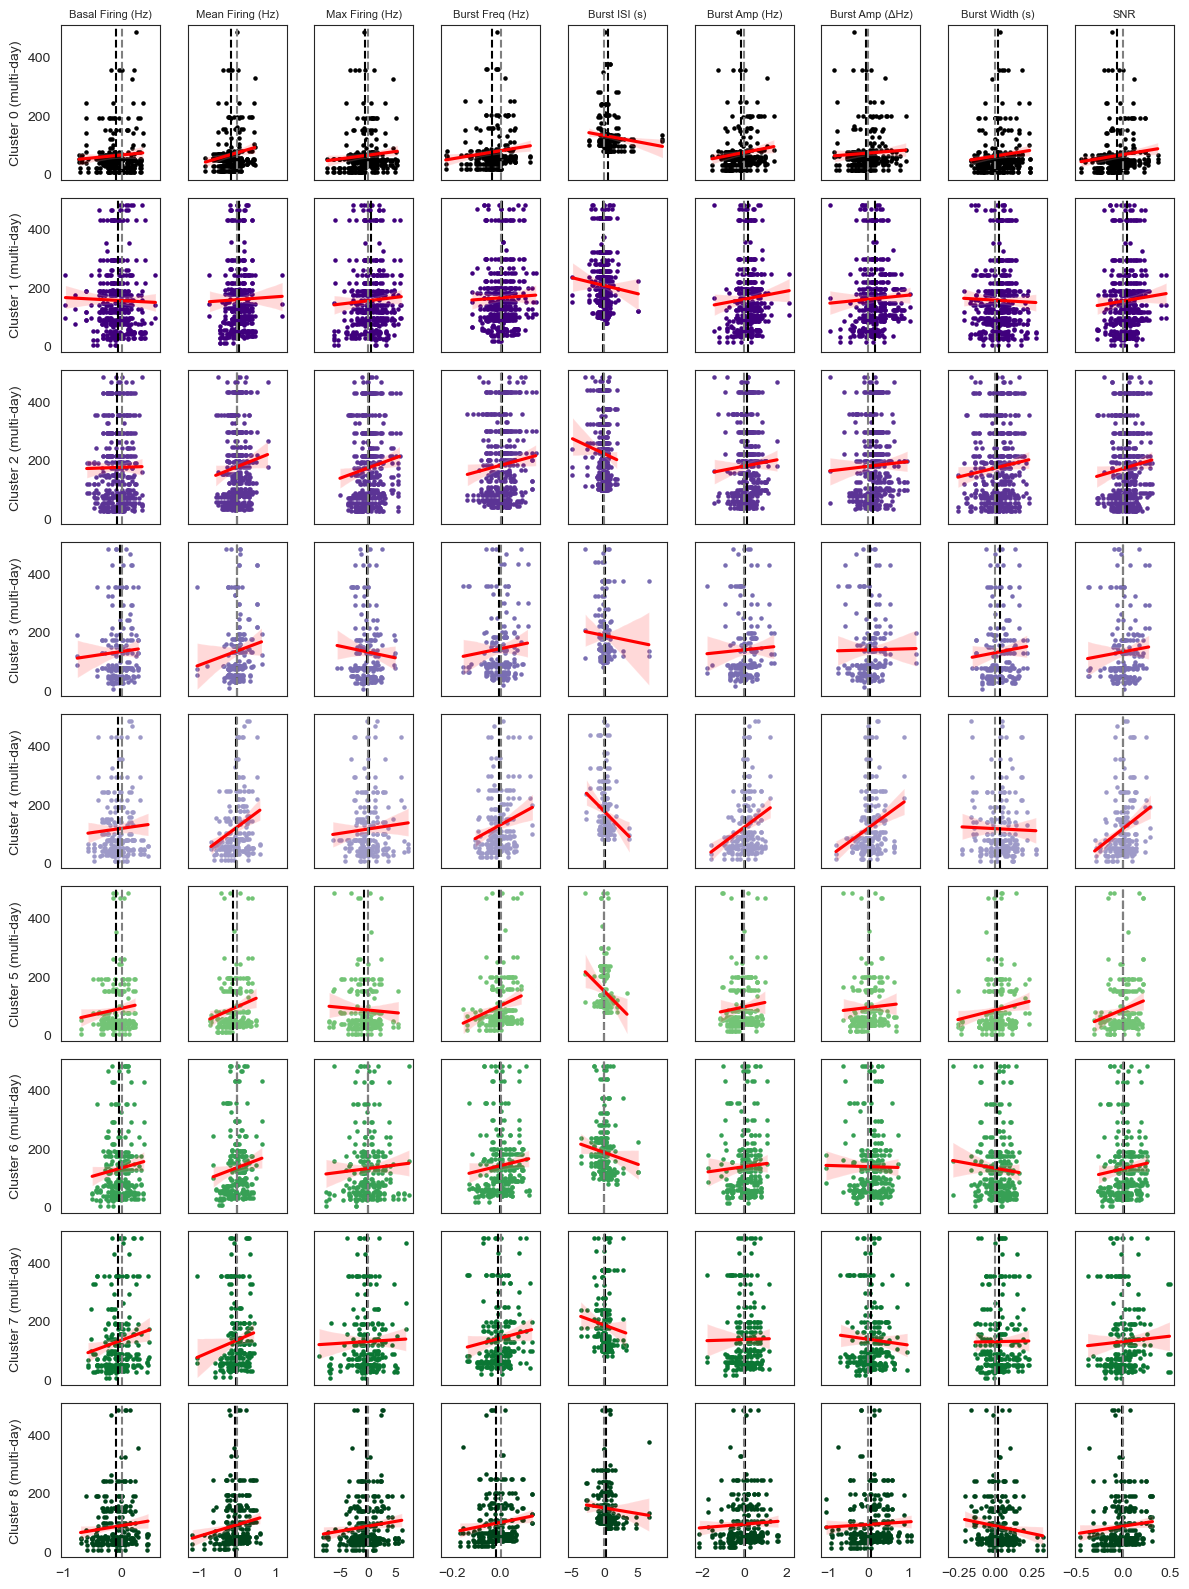

In [534]:
### SEPARATED BY INDIVIDUAL CLUSTERS (0 THROUGH 8)
### CORRELATE PRESSES TO CHANGES IN CASCADE MEASUREMENTS - INDIVIDUAL NEURONS WITH MULTI-DAY CLUSTERING (NO Z-SCORE)

fig, axs = plt.subplots(9, len(measurements), figsize=(12, 16), sharey='col', sharex = 'col')
reference_days = ['5 CueRein', '6 DrugRein', '7 TMTRein']

# Reference day indices for clustering (adjust these to match your reference_day_indices)
reference_day_indices = [5, 6, 7]  # Days to check for consistent clustering

for cluster in range(9):  # Clusters 0 through 8
    cmeasures_press_array_neurons = np.nan*np.ones((1, len(measurements)+1))
    
    for basedir, day, animal, fov in iterate_dirs(basedir, sorted(reference_days)):
        num_presses = np.shape(activeall_presses_animal[day][animal])[0]
        
        # Get clustering data for reference days for this animal
        reference_clusterids = tracked_clusterids_fov[animal][reference_day_indices, :]  # reference_days x neurons
        
        # Apply cluster mask - neurons that have this cluster ID on any reference day
        if cluster == 0:
            cluster_mask = np.all(reference_clusterids == 0, axis=0)  # Must be 0 on ALL reference days
        else:
            cluster_mask = np.any(reference_clusterids == cluster, axis=0)  # Must be this cluster on ANY reference day
        
        if not np.any(cluster_mask):  # Skip if no neurons meet cluster criteria
            continue
        
        # Get day 1 and day 5 data for all measurements and filtered neurons
        day1_data = tracked_cmeasures_fov[animal][0, cluster_mask, :]  # filtered_neurons x cmeasures
        day5_data = tracked_cmeasures_fov[animal][5, cluster_mask, :]  # filtered_neurons x cmeasures
        
        # Process each neuron individually
        valid_neurons = []
        change_cmeasures_per_neuron = []
        
        for neuron_idx in range(day1_data.shape[0]):  # Loop through filtered neurons
            neuron_changes = []
            valid_neuron = True
            
            for m in range(len(measurements)):
                # Get this neuron's day 1 and day 5 values for this measurement
                val_day1 = day1_data[neuron_idx, m]
                val_day5 = day5_data[neuron_idx, m]
                
                # Check if both values are valid (not NaN)
                if np.isnan(val_day1) or np.isnan(val_day5):
                    valid_neuron = False
                    break
                
                # Calculate change for this neuron and measurement
                change = val_day5 - val_day1
                neuron_changes.append(change)
            
            if valid_neuron:
                change_cmeasures_per_neuron.append(neuron_changes)
                valid_neurons.append(neuron_idx)
        
        # Convert to array and create FOV array
        if len(change_cmeasures_per_neuron) > 0:
            change_cmeasures_per_neuron = np.array(change_cmeasures_per_neuron)  # valid_neurons x cmeasures
            num_valid_neurons = len(valid_neurons)
            
            # Create array with one row per valid neuron
            fov_array = np.zeros((num_valid_neurons, len(measurements)+1))
            fov_array[:, :-1] = change_cmeasures_per_neuron  # cmeasures for each neuron
            fov_array[:, -1] = num_presses  # same number of presses for all neurons in this FOV
            
            # Add to the main array
            cmeasures_press_array_neurons = np.vstack((cmeasures_press_array_neurons, fov_array))
        
    # Remove the initial NaN row
    cmeasures_press_array_neurons = cmeasures_press_array_neurons[1:, :]
    
    for m, measurement in enumerate(measurements):
        nan_mask = np.any(np.isnan(cmeasures_press_array_neurons), axis = 1)
        ax = axs[cluster, m]
        ax.scatter(x = cmeasures_press_array_neurons[:, m][~nan_mask], 
                   y = cmeasures_press_array_neurons[:, -1][~nan_mask], 
                   s = 5, color = cluster_colors[cluster])
        sns.regplot(x = cmeasures_press_array_neurons[:, m][~nan_mask], 
                    y = cmeasures_press_array_neurons[:, -1][~nan_mask], \
                    ax = ax, color = 'r', scatter = False)
        ax.axvline(np.nanmean(cmeasures_press_array_neurons[:, m]), color = 'black', linestyle = '--')
        ax.axvline(0, color = 'gray', linestyle = '--')
        if m > 0:
            ax.set_yticklabels([])
        else:
            ax.set_ylabel(f'Cluster {cluster} (multi-day)')
        if cluster == 0:
            ax.set_title(measurement, fontsize = 8)
        print(f'Correlation, Cluster {cluster}, {measurement}:', 
              stats.spearmanr(cmeasures_press_array_neurons[:, m][~nan_mask], 
                            cmeasures_press_array_neurons[:, -1][~nan_mask]) )

fig.tight_layout()
plt.show()



/var/folders/pk/ygvbglbn6bq1fx39y5xg76dc0000gn/T/ipykernel_29373/2686781946.py:110: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.



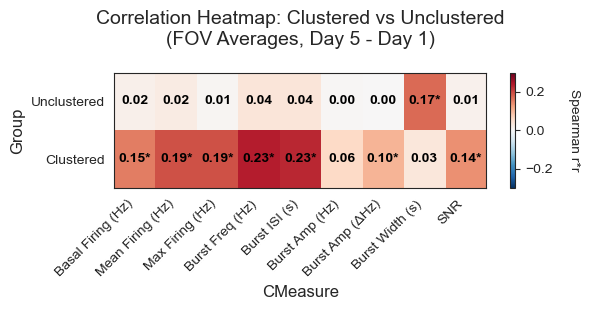

In [539]:
### SEPARATED BY CLUSTERED AND NOT CLUSTERED NEURONS
### CORRELATE PRESSES TO CHANGES IN CASCADE MEASUREMENTS - FOV AVERAGES WITH MULTI-DAY CLUSTERING (NO Z-SCORE)
### SAVE R-VALUES AND CREATE HEATMAP

reference_days = ['5 CueRein', '6 DrugRein', '7 TMTRein']

# Reference day indices for clustering (adjust these to match your reference_day_indices)
reference_day_indices = [5, 6, 7]  # Days to check for consistent clustering

# Initialize array to store r-values
cluster_labels = ['Unclustered', 'Clustered']
r_values = np.full((2, len(measurements)), np.nan)  # 2 groups x measurements
p_values = np.full((2, len(measurements)), np.nan)  # 2 groups x measurements

for c in range(2):
    cmeasures_press_array = np.nan*np.ones((1, len(measurements)+1))
    
    for basedir, day, animal, fov in iterate_dirs(basedir, sorted(reference_days)):
        num_presses = np.shape(activeall_presses_animal[day][animal])[0]
        
        # Get clustering data for reference days for this animal
        reference_clusterids = tracked_clusterids_fov[animal][reference_day_indices, :]  # reference_days x neurons
        
        # Apply clustering mask - consistent across multiple reference days
        if c == 0:
            cluster_mask = np.all(reference_clusterids == 0, axis=0)  # axis=0 for neurons    
        elif c == 1:
            cluster_mask = np.any(reference_clusterids != 0, axis=0)
        
        if not np.any(cluster_mask):  # Skip if no neurons meet clustering criteria
            continue
        
        # Process each measurement separately
        change_cmeasures = []
        
        for m in range(len(measurements)):
            # Get day 1 and day 5 data for this measurement and filtered neurons
            values_day1 = tracked_cmeasures_fov[animal][0, cluster_mask, m]  # day 1
            values_day5 = tracked_cmeasures_fov[animal][5, cluster_mask, m]  # day 5
            
            # Synchronize NaNs between day1 and day5
            values_day1, values_day5 = synchronize_nans(values_day1, values_day5)
            
            if len(values_day1[~np.isnan(values_day1)]) == 0:  # Skip if no valid data
                change_cmeasures.append(np.nan)
                continue
            
            # Simple subtraction (no z-score normalization)
            mean_day1 = np.nanmean(values_day1)
            mean_day5 = np.nanmean(values_day5)
            
            # Calculate change (day 5 - day 1)
            change = mean_day5 - mean_day1
            change_cmeasures.append(change)
        
        change_cmeasures = np.array(change_cmeasures)
        animal_array = np.hstack((change_cmeasures, num_presses))
        cmeasures_press_array = np.vstack((cmeasures_press_array, animal_array))
        
    # Remove the initial NaN row
    cmeasures_press_array = cmeasures_press_array[1:, :]
    
    # Calculate correlations for each measurement and save r-values
    for m, measurement in enumerate(measurements):
        nan_mask = np.any(np.isnan(cmeasures_press_array), axis = 1)
        
        if np.sum(~nan_mask) > 2:  # Need at least 3 points for correlation
            r, p = stats.spearmanr(cmeasures_press_array[:, m][~nan_mask], 
                                 cmeasures_press_array[:, -1][~nan_mask])
            r_values[c, m] = r*r
            p_values[c, m] = p
#             print(f'Correlation, {cluster_labels[c]} (FOV avg), {measurement}: r={r:.3f}, p={p:.3f}')
        else:
            print(f'Correlation, {cluster_labels[c]} (FOV avg), {measurement}: insufficient data')

# Create heatmap
fig, ax = plt.subplots(figsize=(6, 1.5))

# Create heatmap with r-values
im = ax.imshow(r_values, cmap='RdBu_r', aspect='auto', vmin=-.3, vmax=.3)

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label('Spearman r*r', rotation=270, labelpad=20)

# Set ticks and labels
ax.set_xticks(range(len(measurements)))
ax.set_xticklabels(measurements, rotation=45, ha='right')
ax.set_yticks(range(2))
ax.set_yticklabels(cluster_labels)

# Add text annotations with r-values
for c in range(2):
    for m in range(len(measurements)):
        if not np.isnan(r_values[c, m]):
            # Color text based on significance
            text_color = 'white' if abs(r_values[c, m]) > 0.3 else 'black'
            if p_values[c, m] < 0.05:
                text = f'{r_values[c, m]:.2f}*'  # Add asterisk for significant correlations
            else:
                text = f'{r_values[c, m]:.2f}'
            ax.text(m, c, text, ha='center', va='center', 
                   color=text_color, fontsize=10, fontweight='bold')

ax.set_title('Correlation Heatmap: Clustered vs Unclustered\n(FOV Averages, Day 5 - Day 1)', 
             fontsize=14, pad=20)
ax.set_xlabel('CMeasure', fontsize=12)
ax.set_ylabel('Group', fontsize=12)

plt.tight_layout()
plt.show()

# # Print summary statistics
# print(f"\nSummary:")
# print(f"Total correlations calculated: {np.sum(~np.isnan(r_values))}")
# print(f"Significant correlations (p < 0.05): {np.sum(p_values < 0.05)}")
# print(f"Strong correlations (|r| > 0.3): {np.sum(np.abs(r_values) > 0.3)}")

# # Print comparison between groups
# print(f"\nGroup Comparison (FOV Averages):")
# for m, measurement in enumerate(measurements):
#     if not np.isnan(r_values[0, m]) and not np.isnan(r_values[1, m]):
#         diff = r_values[1, m] - r_values[0, m]  # Clustered - Unclustered
#         sig0 = "*" if p_values[0, m] < 0.05 else ""
#         sig1 = "*" if p_values[1, m] < 0.05 else ""
#         print(f"{measurement}: Unclustered r={r_values[0, m]:.3f}{sig0}, Clustered r={r_values[1, m]:.3f}{sig1}, Diff={diff:.3f}")

/var/folders/pk/ygvbglbn6bq1fx39y5xg76dc0000gn/T/ipykernel_29373/754804304.py:126: UserWarning:

Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.



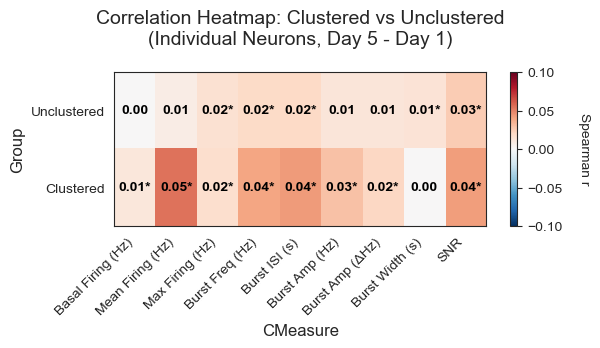


Summary:
Total correlations calculated: 18
Significant correlations (p < 0.05): 13
Strong correlations (|r| > 0.3): 0


In [536]:
### SEPARATED BY CLUSTERED AND NOT CLUSTERED NEURONS
### CORRELATE PRESSES TO CHANGES IN CASCADE MEASUREMENTS - INDIVIDUAL NEURONS WITH MULTI-DAY CLUSTERING (NO Z-SCORE)
### SAVE R-VALUES AND CREATE HEATMAP

reference_days = ['5 CueRein', '6 DrugRein', '7 TMTRein']

# Reference day indices for clustering (adjust these to match your reference_day_indices)
reference_day_indices = [5, 6, 7]  # Days to check for consistent clustering

# Initialize array to store r-values
cluster_labels = ['Unclustered', 'Clustered']
r_values = np.full((2, len(measurements)), np.nan)  # 2 groups x measurements
p_values = np.full((2, len(measurements)), np.nan)  # 2 groups x measurements

for c in range(2):
    cmeasures_press_array_neurons = np.nan*np.ones((1, len(measurements)+1))
    
    for basedir, day, animal, fov in iterate_dirs(basedir, sorted(reference_days)):
        num_presses = np.shape(activeall_presses_animal[day][animal])[0]
        
        # Get clustering data for reference days for this animal
        reference_clusterids = tracked_clusterids_fov[animal][reference_day_indices, :]  # reference_days x neurons
        
        # Apply clustering mask - consistent across multiple reference days
        if c == 0:
            cluster_mask = np.all(reference_clusterids == 0, axis=0)  # axis=0 for neurons    
        elif c == 1:
            cluster_mask = np.any(reference_clusterids != 0, axis=0)
        
        if not np.any(cluster_mask):  # Skip if no neurons meet clustering criteria
            continue
        
        # Get day 1 and day 5 data for all measurements and filtered neurons
        day1_data = tracked_cmeasures_fov[animal][0, cluster_mask, :]  # filtered_neurons x cmeasures
        day5_data = tracked_cmeasures_fov[animal][5, cluster_mask, :]  # filtered_neurons x cmeasures
        
        # Process each neuron individually
        valid_neurons = []
        change_cmeasures_per_neuron = []
        
        for neuron_idx in range(day1_data.shape[0]):  # Loop through filtered neurons
            neuron_changes = []
            valid_neuron = True
            
            for m in range(len(measurements)):
                # Get this neuron's day 1 and day 5 values for this measurement
                val_day1 = day1_data[neuron_idx, m]
                val_day5 = day5_data[neuron_idx, m]
                
                # Check if both values are valid (not NaN)
                if np.isnan(val_day1) or np.isnan(val_day5):
                    valid_neuron = False
                    break
                
                # Calculate change for this neuron and measurement
                change = val_day5 - val_day1
                neuron_changes.append(change)
            
            if valid_neuron:
                change_cmeasures_per_neuron.append(neuron_changes)
                valid_neurons.append(neuron_idx)
        
        # Convert to array and create FOV array
        if len(change_cmeasures_per_neuron) > 0:
            change_cmeasures_per_neuron = np.array(change_cmeasures_per_neuron)  # valid_neurons x cmeasures
            num_valid_neurons = len(valid_neurons)
            
            # Create array with one row per valid neuron
            fov_array = np.zeros((num_valid_neurons, len(measurements)+1))
            fov_array[:, :-1] = change_cmeasures_per_neuron  # cmeasures for each neuron
            fov_array[:, -1] = num_presses  # same number of presses for all neurons in this FOV
            
            # Add to the main array
            cmeasures_press_array_neurons = np.vstack((cmeasures_press_array_neurons, fov_array))
        
    # Remove the initial NaN row
    cmeasures_press_array_neurons = cmeasures_press_array_neurons[1:, :]
    
    # Calculate correlations for each measurement and save r-values
    for m, measurement in enumerate(measurements):
        nan_mask = np.any(np.isnan(cmeasures_press_array_neurons), axis = 1)
        
        if np.sum(~nan_mask) > 2:  # Need at least 3 points for correlation
            r, p = stats.spearmanr(cmeasures_press_array_neurons[:, m][~nan_mask], 
                                 cmeasures_press_array_neurons[:, -1][~nan_mask])
            r_values[c, m] = r*r
            p_values[c, m] = p
#             print(f'Correlation, {cluster_labels[c]}, {measurement}: r={r:.3f}, p={p:.3f}')
        else:
            print(f'Correlation, {cluster_labels[c]}, {measurement}: insufficient data')

# Create heatmap
fig, ax = plt.subplots(figsize=(6, 2))

# Create heatmap with r-values
im = ax.imshow(r_values, cmap='RdBu_r', aspect='auto', vmin=-.1, vmax=.1)

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label('Spearman r', rotation=270, labelpad=20)

# Set ticks and labels
ax.set_xticks(range(len(measurements)))
ax.set_xticklabels(measurements, rotation=45, ha='right')
ax.set_yticks(range(2))
ax.set_yticklabels(cluster_labels)

# Add text annotations with r-values
for c in range(2):
    for m in range(len(measurements)):
        if not np.isnan(r_values[c, m]):
            # Color text based on significance
            text_color = 'white' if abs(r_values[c, m]) > 0.3 else 'black'
            if p_values[c, m] < 0.05:
                text = f'{r_values[c, m]:.2f}*'  # Add asterisk for significant correlations
            else:
                text = f'{r_values[c, m]:.2f}'
            ax.text(m, c, text, ha='center', va='center', 
                   color=text_color, fontsize=10, fontweight='bold')

ax.set_title('Correlation Heatmap: Clustered vs Unclustered\n(Individual Neurons, Day 5 - Day 1)', 
             fontsize=14, pad=20)
ax.set_xlabel('CMeasure', fontsize=12)
ax.set_ylabel('Group', fontsize=12)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary:")
print(f"Total correlations calculated: {np.sum(~np.isnan(r_values))}")
print(f"Significant correlations (p < 0.05): {np.sum(p_values < 0.05)}")
print(f"Strong correlations (|r| > 0.3): {np.sum(np.abs(r_values) > 0.3)}")

# # Print comparison between groups
# print(f"\nGroup Comparison:")
# for m, measurement in enumerate(measurements):
#     if not np.isnan(r_values[0, m]) and not np.isnan(r_values[1, m]):
#         diff = r_values[1, m] - r_values[0, m]  # Clustered - Unclustered
#         print(f"{measurement}: Unclustered r={r_values[0, m]:.3f}, Clustered r={r_values[1, m]:.3f}, Diff={diff:.3f}")

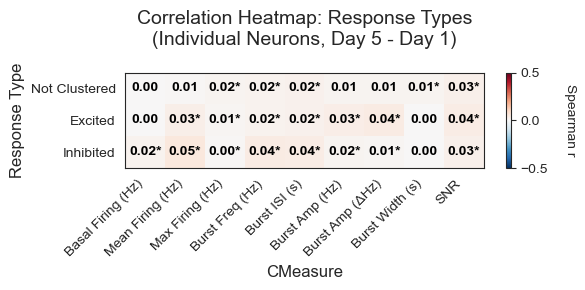


Summary:
Total correlations calculated: 27
Significant correlations (p < 0.05): 20
Strong correlations (|r| > 0.3): 0


In [537]:
### SEPARATED BY RESPONSE TYPE (NOT CLUSTERED, EXCITED, INHIBITED)
### CORRELATE PRESSES TO CHANGES IN CASCADE MEASUREMENTS - INDIVIDUAL NEURONS WITH MULTI-DAY CLUSTERING (NO Z-SCORE)
### SAVE R-VALUES AND CREATE HEATMAP

reference_days = ['5 CueRein', '6 DrugRein', '7 TMTRein']

# Reference day indices for clustering (adjust these to match your reference_day_indices)
reference_day_indices = [5, 6, 7]  # Days to check for consistent clustering

# Response type definitions
response_types = [
    {'name': 'not clustered', 'color': 'black', 'condition': lambda x: np.all(x == 0, axis=0)},
    {'name': 'excited', 'color': 'purple', 'condition': lambda x: np.any(np.isin(x, [1, 2, 3, 4]), axis=0)},
    {'name': 'inhibited', 'color': 'green', 'condition': lambda x: np.any(x >= 5, axis=0)}
]

# Initialize array to store r-values
r_values = np.full((3, len(measurements)), np.nan)  # 3 response types x measurements
p_values = np.full((3, len(measurements)), np.nan)  # 3 response types x measurements

for rt in range(3):
    cmeasures_press_array_neurons = np.nan*np.ones((1, len(measurements)+1))
    
    for basedir, day, animal, fov in iterate_dirs(basedir, sorted(reference_days)):
        num_presses = np.shape(activeall_presses_animal[day][animal])[0]
        
        # Get clustering data for reference days for this animal
        reference_clusterids = tracked_clusterids_fov[animal][reference_day_indices, :]  # reference_days x neurons
        
        # Apply response type mask
        rt_mask = response_types[rt]['condition'](reference_clusterids)
        
        if not np.any(rt_mask):  # Skip if no neurons meet response type criteria
            continue
        
        # Get day 1 and day 5 data for all measurements and filtered neurons
        day1_data = tracked_cmeasures_fov[animal][0, rt_mask, :]  # filtered_neurons x cmeasures
        day5_data = tracked_cmeasures_fov[animal][5, rt_mask, :]  # filtered_neurons x cmeasures
        
        # Process each neuron individually
        valid_neurons = []
        change_cmeasures_per_neuron = []
        
        for neuron_idx in range(day1_data.shape[0]):  # Loop through filtered neurons
            neuron_changes = []
            valid_neuron = True
            
            for m in range(len(measurements)):
                # Get this neuron's day 1 and day 5 values for this measurement
                val_day1 = day1_data[neuron_idx, m]
                val_day5 = day5_data[neuron_idx, m]
                
                # Check if both values are valid (not NaN)
                if np.isnan(val_day1) or np.isnan(val_day5):
                    valid_neuron = False
                    break
                
                # Calculate change for this neuron and measurement
                change = val_day5 - val_day1
                neuron_changes.append(change)
            
            if valid_neuron:
                change_cmeasures_per_neuron.append(neuron_changes)
                valid_neurons.append(neuron_idx)
        
        # Convert to array and create FOV array
        if len(change_cmeasures_per_neuron) > 0:
            change_cmeasures_per_neuron = np.array(change_cmeasures_per_neuron)  # valid_neurons x cmeasures
            num_valid_neurons = len(valid_neurons)
            
            # Create array with one row per valid neuron
            fov_array = np.zeros((num_valid_neurons, len(measurements)+1))
            fov_array[:, :-1] = change_cmeasures_per_neuron  # cmeasures for each neuron
            fov_array[:, -1] = num_presses  # same number of presses for all neurons in this FOV
            
            # Add to the main array
            cmeasures_press_array_neurons = np.vstack((cmeasures_press_array_neurons, fov_array))
    
    # Remove the initial NaN row
    cmeasures_press_array_neurons = cmeasures_press_array_neurons[1:, :]
    
    # Calculate correlations for each measurement and save r-values
    for m, measurement in enumerate(measurements):
        nan_mask = np.any(np.isnan(cmeasures_press_array_neurons), axis = 1)
        
        if np.sum(~nan_mask) > 2:  # Need at least 3 points for correlation
            r, p = stats.spearmanr(cmeasures_press_array_neurons[:, m][~nan_mask], 
                                 cmeasures_press_array_neurons[:, -1][~nan_mask])
            r_values[rt, m] = r*r
            p_values[rt, m] = p
#             print(f'Correlation, {response_types[rt]["name"]}, {measurement}: r={r:.3f}, p={p:.3f}')
        else:
            print(f'Correlation, {response_types[rt]["name"]}, {measurement}: insufficient data')

# Create heatmap
fig, ax = plt.subplots(figsize=(6, 3))

# Create heatmap with r-values
im = ax.imshow(r_values, cmap='RdBu_r', aspect='auto', vmin=-.5, vmax=.5)

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label('Spearman r', rotation=270, labelpad=20)

# Set ticks and labels
ax.set_xticks(range(len(measurements)))
ax.set_xticklabels(measurements, rotation=45, ha='right')
ax.set_yticks(range(3))
ax.set_yticklabels([rt['name'].title() for rt in response_types])

# Add text annotations with r-values
for rt in range(3):
    for m in range(len(measurements)):
        if not np.isnan(r_values[rt, m]):
            # Color text based on significance
            text_color = 'white' if abs(r_values[rt, m]) > 0.3 else 'black'
            if p_values[rt, m] < 0.05:
                text = f'{r_values[rt, m]:.2f}*'  # Add asterisk for significant correlations
            else:
                text = f'{r_values[rt, m]:.2f}'
            ax.text(m, rt, text, ha='center', va='center', 
                   color=text_color, fontsize=10, fontweight='bold')

ax.set_title('Correlation Heatmap: Response Types\n(Individual Neurons, Day 5 - Day 1)', 
             fontsize=14, pad=20)
ax.set_xlabel('CMeasure', fontsize=12)
ax.set_ylabel('Response Type', fontsize=12)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary:")
print(f"Total correlations calculated: {np.sum(~np.isnan(r_values))}")
print(f"Significant correlations (p < 0.05): {np.sum(p_values < 0.05)}")
print(f"Strong correlations (|r| > 0.3): {np.sum(np.abs(r_values) > 0.3)}")

# # Print comparison between response types
# print(f"\nResponse Type Comparison:")
# for m, measurement in enumerate(measurements):
#     print(f"\n{measurement}:")
#     for rt in range(3):
#         if not np.isnan(r_values[rt, m]):
#             sig_marker = "*" if p_values[rt, m] < 0.05 else ""
#             print(f"  {response_types[rt]['name']}: r={r_values[rt, m]:.3f}{sig_marker}")

# # Find measurements with biggest differences between response types
# print(f"\nMeasurements with largest response type differences:")
# for m, measurement in enumerate(measurements):
#     if np.sum(~np.isnan(r_values[:, m])) >= 2:  # Need at least 2 valid values
#         valid_rs = r_values[:, m][~np.isnan(r_values[:, m])]
#         range_diff = np.max(valid_rs) - np.min(valid_rs)
#         print(f"{measurement}: range = {range_diff:.3f}")

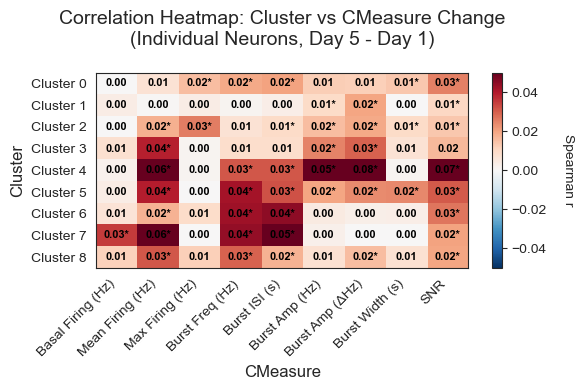


Summary:
Total correlations calculated: 81
Significant correlations (p < 0.05): 45
Strong correlations (|r| > 0.3): 0


In [543]:
### SEPARATED BY INDIVIDUAL CLUSTERS (0 THROUGH 8)
### CORRELATE PRESSES TO CHANGES IN CASCADE MEASUREMENTS - INDIVIDUAL NEURONS WITH MULTI-DAY CLUSTERING (NO Z-SCORE)
### SAVE R-VALUES AND CREATE HEATMAP

reference_days = ['5 CueRein', '6 DrugRein', '7 TMTRein']

# Reference day indices for clustering (adjust these to match your reference_day_indices)
reference_day_indices = [5, 6, 7]  # Days to check for consistent clustering

# Color palette for clusters (you can customize these colors)
cluster_colors = ['black', 'purple', 'blue', 'cyan', 'magenta', 'green', 'orange', 'red', 'brown']

# Initialize array to store r-values
r_values = np.full((9, len(measurements)), np.nan)  # clusters x measurements
p_values = np.full((9, len(measurements)), np.nan)  # clusters x measurements

for cluster in range(9):  # Clusters 0 through 8
    cmeasures_press_array_neurons = np.nan*np.ones((1, len(measurements)+1))
    
    for basedir, day, animal, fov in iterate_dirs(basedir, sorted(reference_days)):
        num_presses = np.shape(activeall_presses_animal[day][animal])[0]
        
        # Get clustering data for reference days for this animal
        reference_clusterids = tracked_clusterids_fov[animal][reference_day_indices, :]  # reference_days x neurons
        
        # Apply cluster mask with proper logic
        if cluster == 0:
            cluster_mask = np.all(reference_clusterids == 0, axis=0)  # Must be 0 on ALL reference days
        else:
            cluster_mask = np.any(reference_clusterids == cluster, axis=0)  # Must be this cluster on ANY reference day
        
        if not np.any(cluster_mask):  # Skip if no neurons meet cluster criteria
            continue
        
        # Get day 1 and day 5 data for all measurements and filtered neurons
        day1_data = tracked_cmeasures_fov[animal][0, cluster_mask, :]  # filtered_neurons x cmeasures
        day5_data = tracked_cmeasures_fov[animal][5, cluster_mask, :]  # filtered_neurons x cmeasures
        
        # Process each neuron individually
        valid_neurons = []
        change_cmeasures_per_neuron = []
        
        for neuron_idx in range(day1_data.shape[0]):  # Loop through filtered neurons
            neuron_changes = []
            valid_neuron = True
            
            for m in range(len(measurements)):
                # Get this neuron's day 1 and day 5 values for this measurement
                val_day1 = day1_data[neuron_idx, m]
                val_day5 = day5_data[neuron_idx, m]
                
                # Check if both values are valid (not NaN)
                if np.isnan(val_day1) or np.isnan(val_day5):
                    valid_neuron = False
                    break
                
                # Calculate change for this neuron and measurement
                change = val_day5 - val_day1
                neuron_changes.append(change)
            
            if valid_neuron:
                change_cmeasures_per_neuron.append(neuron_changes)
                valid_neurons.append(neuron_idx)
        
        # Convert to array and create FOV array
        if len(change_cmeasures_per_neuron) > 0:
            change_cmeasures_per_neuron = np.array(change_cmeasures_per_neuron)  # valid_neurons x cmeasures
            num_valid_neurons = len(valid_neurons)
            
            # Create array with one row per valid neuron
            fov_array = np.zeros((num_valid_neurons, len(measurements)+1))
            fov_array[:, :-1] = change_cmeasures_per_neuron  # cmeasures for each neuron
            fov_array[:, -1] = num_presses  # same number of presses for all neurons in this FOV
            
            # Add to the main array
            cmeasures_press_array_neurons = np.vstack((cmeasures_press_array_neurons, fov_array))
    
    # Remove the initial NaN row
    cmeasures_press_array_neurons = cmeasures_press_array_neurons[1:, :]
    
    # Calculate correlations for each measurement and save r-values
    for m, measurement in enumerate(measurements):
        nan_mask = np.any(np.isnan(cmeasures_press_array_neurons), axis = 1)
        
        if np.sum(~nan_mask) > 2:  # Need at least 3 points for correlation
            r, p = stats.spearmanr(cmeasures_press_array_neurons[:, m][~nan_mask], 
                                 cmeasures_press_array_neurons[:, -1][~nan_mask])
            r_values[cluster, m] = r*r
            p_values[cluster, m] = p
#             print(f'Correlation, Cluster {cluster}, {measurement}: r={r:.3f}, p={p:.3f}')
        else:
            print(f'Correlation, Cluster {cluster}, {measurement}: insufficient data')

# Create heatmap
fig, ax = plt.subplots(figsize=(6, 4))

# Create heatmap with r-values
im = ax.imshow(r_values, cmap='RdBu_r', aspect='auto', vmin=-.05, vmax=.05)

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label('Spearman r', rotation=270, labelpad=20)

# Set ticks and labels
ax.set_xticks(range(len(measurements)))
ax.set_xticklabels(measurements, rotation=45, ha='right')
ax.set_yticks(range(9))
ax.set_yticklabels([f'Cluster {i}' for i in range(9)])

# Add text annotations with r-values
for cluster in range(9):
    for m in range(len(measurements)):
        if not np.isnan(r_values[cluster, m]):
            # Color text based on significance (you can adjust p-value threshold)
            text_color = 'white' if abs(r_values[cluster, m]) > 0.3 else 'black'
            if p_values[cluster, m] < 0.05:
                text = f'{r_values[cluster, m]:.2f}*'  # Add asterisk for significant correlations
            else:
                text = f'{r_values[cluster, m]:.2f}'
            ax.text(m, cluster, text, ha='center', va='center', 
                   color=text_color, fontsize=8, fontweight='bold')

ax.set_title('Correlation Heatmap: Cluster vs CMeasure Change\n(Individual Neurons, Day 5 - Day 1)', 
             fontsize=14, pad=20)
ax.set_xlabel('CMeasure', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary:")
print(f"Total correlations calculated: {np.sum(~np.isnan(r_values))}")
print(f"Significant correlations (p < 0.05): {np.sum(p_values < 0.05)}")
print(f"Strong correlations (|r| > 0.3): {np.sum(np.abs(r_values) > 0.3)}")